In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
supermarket_data = pd.read_csv('./supermarket_sales.csv')

In [4]:
supermarket_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   object 
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

# Xử lý dữ liệu

## Xử lý dữ liệu Tax  bị sai kiểu dữ liệu

In [5]:
supermarket_data_coppy = supermarket_data.copy()
supermarket_data_coppy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   object 
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

\- Công thức

* Total = (Unit Price * Quantity) + Tax

\=> Tax = Total - (Unit Price * Quantity)

In [6]:
supermarket_data_coppy['Tax'] = supermarket_data_coppy['Total'] - (supermarket_data_coppy['Quantity'] * supermarket_data_coppy['Unit price'])
supermarket_data_coppy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   object 
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

## Xử lý dữ liệu bị sai kiểu dữ liệu thời gian

In [7]:
supermarket_data_coppy['Date'] = pd.to_datetime(supermarket_data_coppy['Date'], dayfirst=True)
supermarket_data_coppy['Time'] = pd.to_datetime(supermarket_data['Time'], format='mixed')
supermarket_data_coppy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   object        
 9   Total                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   datetime64[ns]
 12  Payment                  1000 non-n

# Dataset này có bao nhiêu:

* Thành phố (City)?

* Chi nhánh (Branch)?

* Loại khách hàng (Customer type)?

* Dòng sản phẩm (Product line)?

* Hình thức thanh toán là gì ?

## Có bao nhiêu chi nhánh

In [8]:
branch_uinque = supermarket_data_coppy['Branch'].unique()
print(f"Có {len(branch_uinque)} Chi nhánh bao gồm {branch_uinque}")

Có 3 Chi nhánh bao gồm ['A' 'C' 'B']


## Có bao nhiêu thành phố

In [9]:
city_unique = supermarket_data_coppy['City'].unique()
print(f"Có {len(city_unique)} thành phố bao gồm {city_unique}")

Có 3 thành phố bao gồm ['Yangon' 'Naypyitaw' 'Mandalay']


In [10]:
print(supermarket_data_coppy.groupby('City')['Branch'].unique())

City
Mandalay     [B]
Naypyitaw    [C]
Yangon       [A]
Name: Branch, dtype: object


## Có bao nhiêu loại khách hàng

In [11]:
customer_type_unique = supermarket_data_coppy['Customer type'].unique()
print(f"Có {len(customer_type_unique)} loại khách hàng bao gồm {customer_type_unique}")

Có 2 loại khách hàng bao gồm ['Member' 'Normal']


## Có bao nhiêu dòng sản phẩm

In [12]:
product_line_unique = supermarket_data_coppy['Product line'].unique()
print(f"Có {len(product_line_unique)} dòng sản phẩm bao gồm {product_line_unique}")

Có 6 dòng sản phẩm bao gồm ['Health and beauty' 'Electronic accessories' 'Home and lifestyle'
 'Sports and travel' 'Food and beverages' 'Fashion accessories']


## Có bao nhiêu hình thức thanh toán

In [13]:
payment_unique = supermarket_data_coppy['Payment'].unique()
print(f"Có {len(payment_unique)} phương thức thanh toán bao gồm {payment_unique}")

Có 3 phương thức thanh toán bao gồm ['Ewallet' 'Cash' 'Credit card']


# Đếm các số lượng của các đặc dữ liệu

    ## Đếm số lượng các giao dịch của các chi nhánh có trong giao dịch

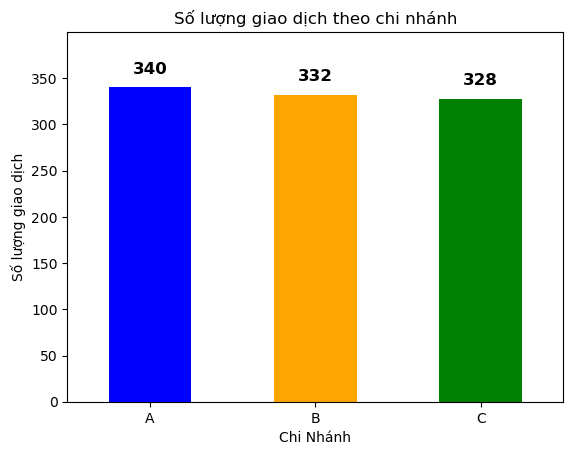

In [ ]:
    branch_counts = supermarket_data_coppy['Branch'].value_counts()

    ax = branch_counts.plot(kind='bar', color=['blue', 'orange', 'green'])
    ax.bar_label(ax.containers[0],
                labels=[f'{int(v)}' for v in branch_counts.values],
                padding=8, fontsize=12, fontweight='bold')
    plt.xlabel('Chi Nhánh')
    plt.ylabel('Số lượng giao dịch')
    plt.title('Số lượng giao dịch theo chi nhánh')
    plt.ylim(0, ax.get_ylim()[1] * 1.12) 
    plt.xticks(ticks=range(len(branch_counts)), labels=branch_counts.index, rotation=0)
    plt.show()

In [15]:
percentage_branch = (branch_counts / branch_counts.sum()) * 100
for branch, percentage in percentage_branch.items():
    print(f'Tỷ lệ giao dịch của chi nhánh {branch}: {percentage:.2f}%')

Tỷ lệ giao dịch của chi nhánh A: 34.00%
Tỷ lệ giao dịch của chi nhánh B: 33.20%
Tỷ lệ giao dịch của chi nhánh C: 32.80%


-	Chi Nhánh A: Có 340 giao dịch
-	Chi Nhánh B: Có 332 giao dịch
-	Chi Nhánh C: Có 328 giao dịch 

=> Không có sự chênh lệch quá lớn về các giao dịch của các hãng

## Đếm số lượng giao dịch của các thành phố có trong dữ liệu

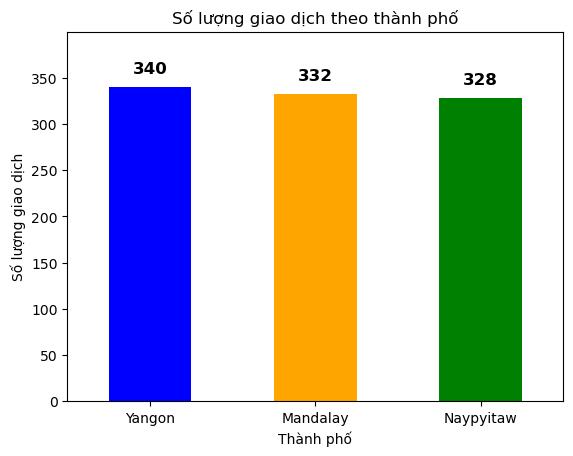

In [16]:
city_count = supermarket_data_coppy['City'].value_counts()
ax = city_count.plot(kind='bar', color=['blue', 'orange', 'green'])
ax.bar_label(ax.containers[0],
                labels=[f'{int(v)}' for v in city_count.values],
                padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Thành phố')
plt.ylabel('Số lượng giao dịch')    
plt.title('Số lượng giao dịch theo thành phố')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(ticks=range(len(city_count)), labels=city_count.index, rotation=0)
plt.show()

In [17]:
# Tỷ lệ bán hàng giữa các thành phố
percentage_city = (city_count / city_count.sum()) * 100
for city, percentage in percentage_city.items():
    print(f'Tỷ lệ giao dịch của thành phố {city}: {percentage:.2f}%')

Tỷ lệ giao dịch của thành phố Yangon: 34.00%
Tỷ lệ giao dịch của thành phố Mandalay: 33.20%
Tỷ lệ giao dịch của thành phố Naypyitaw: 32.80%


\- Kết luận:

-	Thành phố Yangon có 340 giao dịch bằng với Chi Nhánh A
-	Thành phố Mandalay có 332 giao dịch bằng với Chi Nhánh B
-	Thành phố Napyitaw có 328 giao dịch bằng với Chi Nhánh C

=> không có sự chênh lệch quá lớn giữa các thành phố với giao dịch

=> Số lượng giao dịch giữa các thành phố và các Chi Nhánh bằng nhau 

Tại sao số lượng giao dịch của các Chi Nhánh lại bằng nhau với các thành phố?

In [18]:
# Xem mối quan hệ giữa Branch và City
print(pd.crosstab(supermarket_data_coppy['Branch'], supermarket_data_coppy['City']))

City    Mandalay  Naypyitaw  Yangon
Branch                             
A              0          0     340
B            332          0       0
C              0        328       0


\- Kết luận:
* Số lượng giao dịch giữa các thành phố và các Chi Nhánh giống nhau tại vì mỗi một Chi Nhánh chỉ bán ở một thành phố duy nhất

## Đếm số lượng giao dịch theo giới tính

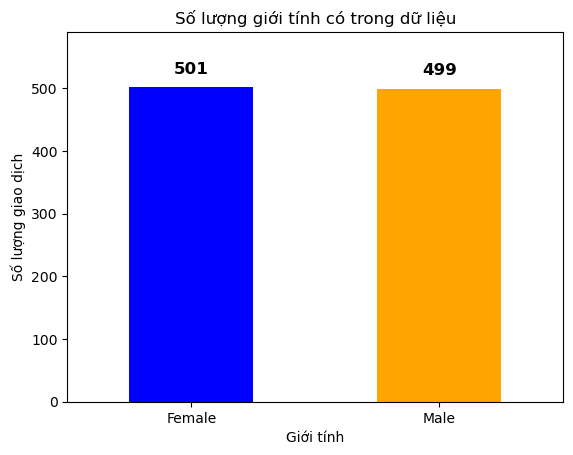

In [19]:
gender_count = supermarket_data_coppy['Gender'].value_counts()
ax = gender_count.plot(kind='bar', color=['blue', 'orange'])    
ax.bar_label(ax.containers[0],
                labels=[f'{int(v)}' for v in gender_count.values],
                padding=8, fontsize=12, fontweight='bold')  
plt.xlabel('Giới tính')
plt.ylabel('Số lượng giao dịch')        
plt.title('Số lượng giới tính có trong dữ liệu')
plt.ylim(0, ax.get_ylim()[1] * 1.12)        
plt.xticks(ticks=range(len(gender_count)), labels=gender_count.index, rotation=0)
plt.show()

\- Kết luận:

* Số lượng giao dịch giữa hai giới tính phân bố đều nhau không có sự chênh lệch đáng kể

## Đếm số lượng sản phẩm có trong dữ liệu

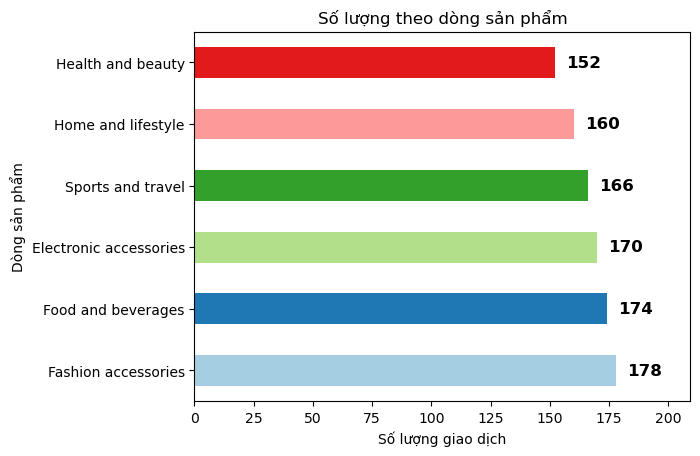

In [20]:
product_line_count = supermarket_data_coppy['Product line'].value_counts()
ax = product_line_count.plot(kind='barh', color=plt.cm.Paired.colors)
ax.bar_label(ax.containers[0],
                labels=[f'{int(v)}' for v in product_line_count.values],
                padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Số lượng giao dịch')
plt.ylabel('Dòng sản phẩm') 
plt.title('Số lượng theo dòng sản phẩm')
plt.xlim(0, ax.get_xlim()[1] * 1.12)
plt.yticks(ticks=range(len(product_line_count)), labels=product_line_count.index)
plt.show()

In [21]:
# Tính số lượng giao dịch theo từng dòng sản phẩm
product_line_count = supermarket_data_coppy['Product line'].value_counts()

# Tính tỷ lệ phần trăm
product_line_percentage = (product_line_count / product_line_count.sum()) * 100

# In kết quả chi tiết
print("Số lượng và tỷ lệ giao dịch theo dòng sản phẩm:")
for line, count in product_line_count.items():
    perc = product_line_percentage[line]
    print(f"{line}: {count} giao dịch → {perc:.2f}%")

Số lượng và tỷ lệ giao dịch theo dòng sản phẩm:
Fashion accessories: 178 giao dịch → 17.80%
Food and beverages: 174 giao dịch → 17.40%
Electronic accessories: 170 giao dịch → 17.00%
Sports and travel: 166 giao dịch → 16.60%
Home and lifestyle: 160 giao dịch → 16.00%
Health and beauty: 152 giao dịch → 15.20%


In [22]:
# Sự chênh lệch giữa các sản phẩm được bán ra
# Tổng số lượng sản phẩm được bán ra theo từng dòng sản phẩm
product_line_count = supermarket_data_coppy['Product line'].value_counts()
ten_sp = product_line_count.index.to_list()
sl = product_line_count.values.tolist()
print(sl)

# Sự chênh lệch giữa sản phẩm được bán nhiều nhất và ít nhất
chenh_lech = ((sl[0] - sl[-1])/sl[0]) * 100
print(f"Sự chênh lệch giữa sản phẩm được bán nhiều nhất và ít nhất là: {chenh_lech} sản phẩm")

[178, 174, 170, 166, 160, 152]
Sự chênh lệch giữa sản phẩm được bán nhiều nhất và ít nhất là: 14.606741573033707 sản phẩm


\- Kết luận:

* Không có sự chênh lệch quá lớn giữa các sản phẩm

* Các sản phẩm dẫn đầu là: Fashion accessories, Food and beverages, Electric accessories

* Sự chênh lệch giữa sản phẩm bán cao nhất và thấp nhất không đáng kể chỉ từ: 14.6067%

## Đếm số lượng theo hình thức thanh toán trong dữ liệu

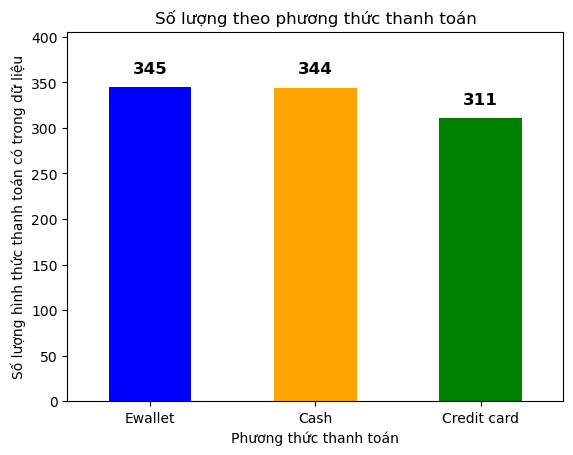

In [23]:
payment_count = supermarket_data_coppy['Payment'].value_counts()
ax = payment_count.plot(kind='bar', color=['blue', 'orange', 'green'])
ax.bar_label(ax.containers[0],
                labels=[f'{int(v)}' for v in payment_count.values],
                padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Phương thức thanh toán')
plt.ylabel('Số lượng hình thức thanh toán có trong dữ liệu')
plt.title('Số lượng theo phương thức thanh toán')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(ticks=range(len(payment_count)), labels=payment_count.index, rotation=0)
plt.show()

\- Kết luận:

* Siêu thị này các hình thức thanh toán phân bổ đồng đều không có sự chênh lệch đáng kể 

## Số lượng giao dịch theo thời gian

### Số lượng giao dịch theo giờ trong ngày

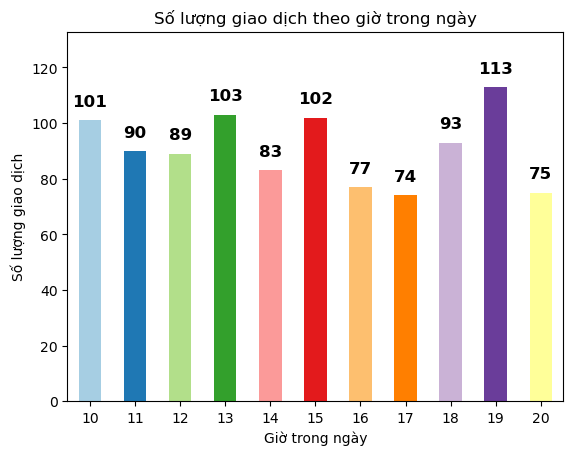

In [24]:
# Vẽ biểu đồ mua hàng theo thời gian trong ngày
supermarket_data_coppy['Hour'] = supermarket_data_coppy['Time'].dt.hour
hourly_counts = supermarket_data_coppy['Hour'].value_counts().sort_index()
ax = hourly_counts.plot(kind='bar', color=plt.cm.Paired.colors)
ax.bar_label(ax.containers[0],
                labels=[f'{int(v)}' for v in hourly_counts.values],
                padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Số lượng giao dịch')
plt.title('Số lượng giao dịch theo giờ trong ngày')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(ticks=range(len(hourly_counts)), labels=hourly_counts.index, rotation=0)
plt.show()

\- Phân tích:

* 19h là khoảng thời gian có nhiều khách hàng mua hàng nhất trong ngày, nguyên nhân đây là khoảng thời gian khách hàng rảnh nhất trong ngày nên họ dành thời gian để đi mua sắm

* 17h là khoảng thời gian khách hàng mua hàng ít nhất, nguyên nhân có thể khoảng thời gian này là thời gian khách hàng đang làm việc

### Số lượng giao dịch theo các buổi trong ngày

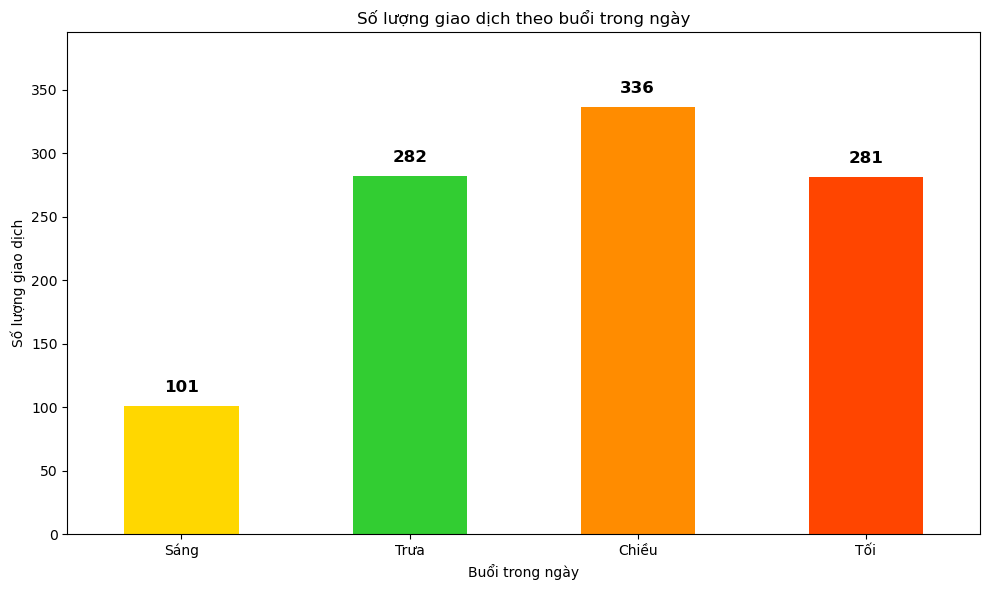

In [25]:
def get_time_of_day(hour):
    if pd.isna(hour):
        return 'Không xác định'  # hoặc drop những hàng này nếu không muốn hiển thị
    hour = int(hour)  # đảm bảo là số nguyên
    if 6 <= hour < 11:
        return 'Sáng'      # Buổi sáng: 6h - 10h59
    elif 11 <= hour < 14:
        return 'Trưa'      # Buổi trưa: 11h - 13h59
    elif 14 <= hour < 18:
        return 'Chiều'     # Buổi chiều: 14h - 17h59
    elif 18 <= hour < 24:
        return 'Tối'       # Buổi tối: 18h - 23h59

# Tạo cột Time of Day (chạy sau khi làm sạch Hour)
supermarket_data_coppy['Time of Day'] = supermarket_data_coppy['Hour'].apply(get_time_of_day)

# Đếm và sắp xếp thứ tự mong muốn
order = ['Sáng', 'Trưa', 'Chiều', 'Tối']
time_of_day_counts = supermarket_data_coppy['Time of Day'].value_counts().reindex(order, fill_value=0)
# Vẽ biểu đồ
colors = ['#FFD700', '#32CD32', '#FF8C00', '#FF4500']  # Màu cho từng buổi + Không xác định

ax = time_of_day_counts.plot(
    kind='bar',
    color=colors,
    figsize=(10, 6)  # Tăng kích thước để hiển thị 4-6 cột rõ hơn
)

# Thêm nhãn số lên đầu cột (an toàn với NaN)
ax.bar_label(
    ax.containers[0],
    labels=[f'{int(v)}' if not pd.isna(v) else '0' for v in time_of_day_counts.values],
    padding=8,
    fontsize=12,
    fontweight='bold'
)

plt.xlabel('Buổi trong ngày')
plt.ylabel('Số lượng giao dịch')
plt.title('Số lượng giao dịch theo buổi trong ngày')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

\- Phân tích:

* Mặc dù 19h là khoảng thời gian khách hàng mua nhiều nhất nhưng buổi chiều thời gian khoảng 14h -18h lại là buổi có số lượng khách hàng mua sắm nhiều nhất vì đây là khoảng thời gian khách hàng tan làm có nhiều nhu cầu mua hàng hơn

* Thời gian này có nhiều lý do để họ mua hàng có thể là chuẩn bị bữa tối, giải trí sau giờ làm,....


## Đếm số lượng giao dịch theo từng tháng

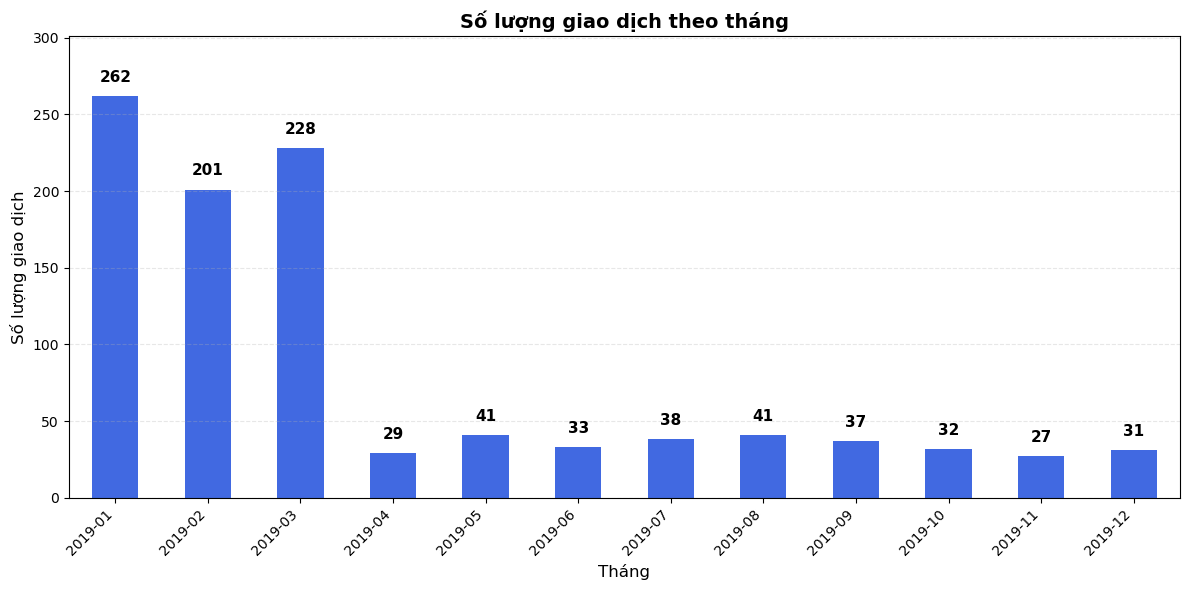

In [26]:
# Giả sử supermarket_data đã có cột 'Date' dạng datetime
supermarket_data_coppy['YearMonth'] = supermarket_data_coppy['Date'].dt.to_period('M')

# Đếm số giao dịch theo tháng
monthly_counts = supermarket_data_coppy.groupby('YearMonth').size()

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
ax = monthly_counts.plot(kind='bar', color='royalblue')

# Thêm số lên đầu cột
ax.bar_label(ax.containers[0], 
             labels=[f'{int(v)}' for v in monthly_counts.values],
             padding=8, fontsize=11, fontweight='bold')

plt.title('Số lượng giao dịch theo tháng', fontsize=14, fontweight='bold')
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Số lượng giao dịch', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, monthly_counts.max() * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# Sự chên lệch giữa tháng 1 và tháng 12
jan_count = monthly_counts.get('2019-01', 0)
dec_count = monthly_counts.get('2019-12', 0)
chenh_lech_jan_dec = ((dec_count - jan_count) / jan_count) * 100 if jan_count != 0 else 0
print(f"Sự chênh lệch giữa tháng 1 và tháng 12 là: {chenh_lech_jan_dec} %")

Sự chênh lệch giữa tháng 1 và tháng 12 là: -88.16793893129771 %


\- Kết luận:

* Các tháng đầu năm khách hàng có xu hướng mua hàng nhiều năm hơn 

* Sau đó giảm mạnh vào quý II, III và IV

* Trong tháng 1 khách hàng có xu hướng mua sắm nhiều hơn sau đó giảm nhẹ vào tháng 2 và tăng mạnh vào tháng 3 nhưng các tháng tiếp theo thì giảm mạnh

* Sự chênh lệch giữa tháng 1 và tháng 12 là 88.12% cho thấy có sự chênh lệch lớn giữa tháng đầu năm và cuối năm 

## Đếm số lượng giao dịch theo quý

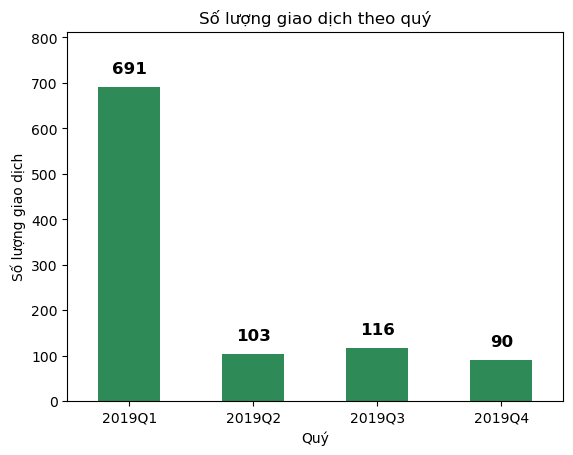

In [28]:
# đếm số lượng giao dịch theo quý
supermarket_data_coppy['Quarter'] = supermarket_data_coppy['Date'].dt.to_period('Q')
quarterly_counts = supermarket_data_coppy.groupby('Quarter').size()
ax = quarterly_counts.plot(kind='bar', color='seagreen')
ax.bar_label(ax.containers[0],
                labels=[f'{int(v)}' for v in quarterly_counts.values],
                padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Quý')
plt.ylabel('Số lượng giao dịch')
plt.title('Số lượng giao dịch theo quý')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(ticks=range(len(quarterly_counts)), labels=quarterly_counts.index, rotation=0)
plt.show()

In [29]:
# Sự chênh lệch giữa quý 1 và quý 2
q1_count = quarterly_counts.get('2019Q1', 0)
q2_count = quarterly_counts.get('2019Q2', 0)
q3_count = quarterly_counts.get('2019Q3', 0)
q4_count = quarterly_counts.get('2019Q4', 0)
chenh_lech_q1_q2 = ((q2_count - q1_count) / q1_count) * 100 if q1_count != 0 else 0
chenh_lech_q2_q3 = ((q3_count - q2_count) / q2_count) * 100 if q2_count != 0 else 0
chenh_lech_q3_q4 = ((q4_count - q3_count) / q3_count) * 100 if q3_count != 0 else 0
print(f"Sự chênh lệch giữa quý 1 và quý 2 là: {chenh_lech_q1_q2} %")
print(f"Sự chênh lệch giữa quý 2 và quý 3 là: {chenh_lech_q2_q3} %")
print(f"Sự chênh lệch giữa quý 3 và quý 4 là: {chenh_lech_q3_q4} %")



Sự chênh lệch giữa quý 1 và quý 2 là: -85.09406657018813 %
Sự chênh lệch giữa quý 2 và quý 3 là: 12.62135922330097 %
Sự chênh lệch giữa quý 3 và quý 4 là: -22.413793103448278 %


\- Phân tích

* Từ quý 1 sang quý 2: cho thấy sự chênh lệch lớn. Nguyên nhân có thể do quý 2 là các tháng sau tết nên sức mua của khách hàng giảm 

* Từ quý 2 sang quý 3: Có thể thấy từ quý 2 sang quý sức mua tăng lên nhưng không đáng kể chỉ 12.6%. Cho thấy siêu thị, các hàng và các sản phẩm đã áp dụng các chính sách để kích cầu mua hàng 

* Từ quý 3 và quý 4: Sức mua lại giảm so với quý 2 và quý 3. Cho thấy rằng các chính sách chưa thật sự hiệu quả, các chính sách chỉ hiệu quả lúc ra mắt tức là quý 2 sang quý 3 nhưng sau quý 3 các chính sách này lại không thu hút được khách hàng



## Đếm số lượng đánh giá theo giao dịch

In [30]:
# Điểm được đánh giá cao nhất và thấp nhất trong các đánh giá
max_rating = supermarket_data_coppy['Rating'].max()
min_rating = supermarket_data_coppy['Rating'].min()
print(f"Điểm đánh giá cao nhất là: {max_rating}")
print(f"Điểm đánh giá thấp nhất là: {min_rating}")
# ===== CHIA BIN THEO MỨC KINH DOANH =====
bins = [4.0, 5.0, 6.5, 7.5, 8.5, 10.0]
labels = ['Rất kém', 'Kém', 'Trung bình', 'Khá', 'Tốt']

supermarket_data_coppy['Rating Category'] = pd.cut(
    supermarket_data_coppy['Rating'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

Điểm đánh giá cao nhất là: 10.0
Điểm đánh giá thấp nhất là: 4.0


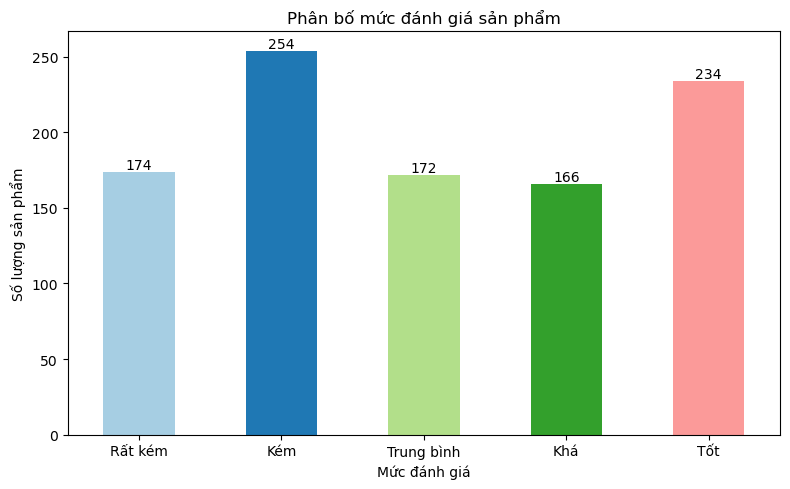

In [31]:
# ===== VẼ BIỂU ĐỒ =====
rating_counts = supermarket_data_coppy['Rating Category'].value_counts().sort_index()
ax = rating_counts.plot(
    kind='bar',
    figsize=(8, 5),
    color=plt.cm.Paired.colors
)

plt.xlabel('Mức đánh giá')
plt.ylabel('Số lượng sản phẩm')
plt.title('Phân bố mức đánh giá sản phẩm')
plt.xticks(rotation=0)

# ===== HIỂN THỊ SỐ LƯỢNG TRÊN ĐẦU CỘT =====
for i, value in enumerate(rating_counts):
    ax.text(
        i,
        value,
        str(value),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

\- Phân tích:

* Dựa vào biểu đồ đánh giá cho thấy siêu thị có nhiều sản phẩm bị đánh giá kém nhiều nhất với 254 lượt đánh 

* Nên cải thiện chất lượng sản phẩm 

* Chưa có nhiều sản phẩm được đánh giá ở trên mức trung bình, các sản phẩm đa số được đánh giá từ mức trung bình trở xuống

* Mỗi một thành phố sẽ có 1 hãng khác nhau bán hàng

# Phân tích tổng quan kinh doanh

## Doanh thu theo thành phố và chi nhánh

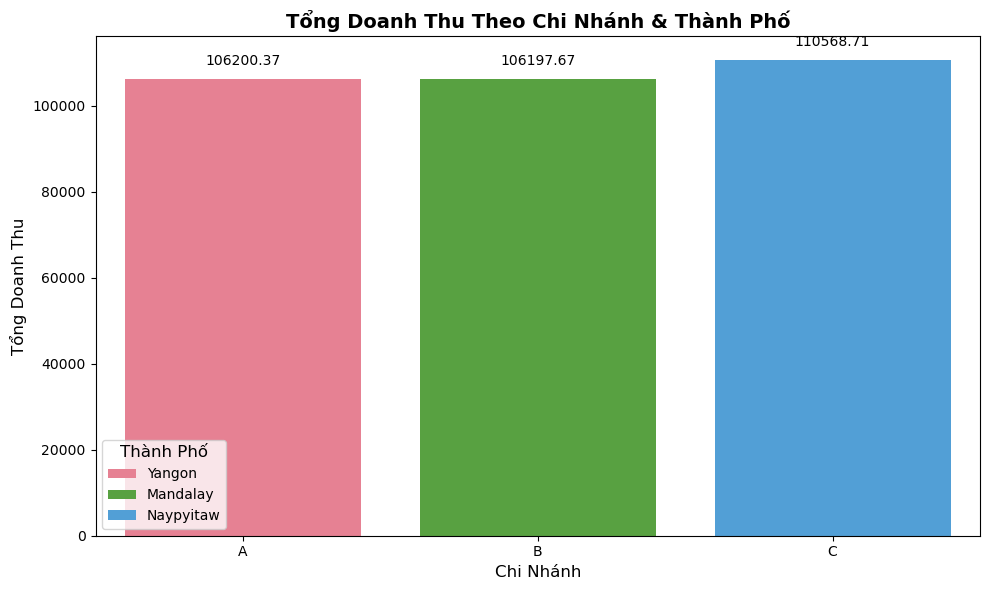

In [32]:
branch_sales = supermarket_data_coppy.groupby(['Branch', 'City'])['Total'].sum().reset_index()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data = branch_sales,
    x = 'Branch',
    y = 'Total',
    hue='City',
    palette='husl'
)

plt.title('Tổng Doanh Thu Theo Chi Nhánh & Thành Phố', fontsize=14, fontweight='bold')
plt.xlabel('Chi Nhánh', fontsize=12)
plt.ylabel('Tổng Doanh Thu', fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=8, fontsize=10)

plt.legend(title='Thành Phố', title_fontsize=12, fontsize=10)
plt.tight_layout()
plt.show()

In [33]:
# Tổng doanh thu cho cả ba chi nhánh
total_sales = branch_sales['Total'].sum()
print(f"Tổng doanh thu cho cả ba chi nhánh là: {total_sales:.2f}")


Tổng doanh thu cho cả ba chi nhánh là: 322966.75


**\- Phân tích:**

* Chi nhánh C đang có doanh thu cao nhất

* Chi nhánh A và B có doanh thu ngang nhau không có sự chênh lệch quá lớn 

* Chi nhánh B đang có doanh thu thấp nhất 


* Mỗi một chi nhánh nằm trong 1 thành phố duy nhất 

* Tại sao chi nhánh C lại có doanh thu co nhất trong cả ba chi nhánh trong khi đó chi nhánh A và B có doanh thu tương đương nhau?

\- Nhìn chung doanh thu của cả ba chi nhánh khá đồng đều không có sự chênh lệch quá lớn giữa 3 chi nhánh


## Gross income theo chi nhánh

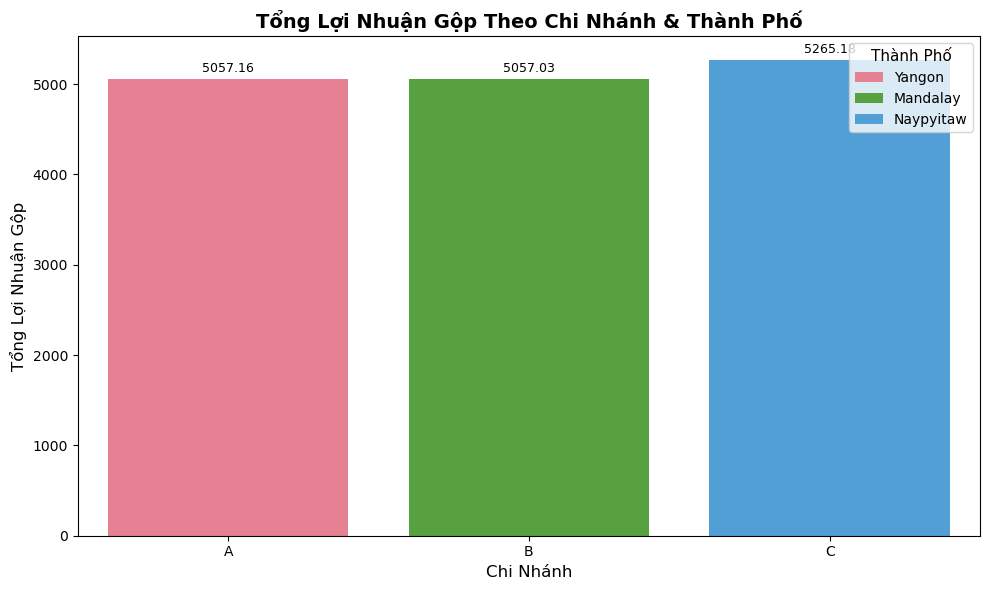

In [34]:
gross_branch_city = supermarket_data_coppy.groupby(['Branch', 'City'])['gross income'].sum().reset_index()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=gross_branch_city,
    x='Branch',
    y='gross income',
    hue='City',
    palette='husl',
    errorbar=None   # nếu không cần error bar
)

plt.title('Tổng Lợi Nhuận Gộp Theo Chi Nhánh & Thành Phố', fontsize=14, fontweight='bold')
plt.xlabel('Chi Nhánh', fontsize=12)
plt.ylabel('Tổng Lợi Nhuận Gộp', fontsize=12)

# Hiển thị nhãn số trên mỗi thanh
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.legend(title='Thành Phố', title_fontsize=11, fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

**\- Phân tích:**

* Chi nhánh C đang có lợi nhuận gộp cao nhất

* Chi nhánh A và B lợi nhuận gộp ngang nhau do doanh thu của hai chi nhánh này ngang nhau

* Chi nhánh B đang có lợi nhuận thấp nhất 

* Tại sao chi nhánh C lại có lợi nhuận cao nhất trong cả ba chi nhánh trong khi đó chi nhánh A và B có doanh thu tương đương nhau?

\- Nhìn chung lợi nhuận gộp của cả ba chi nhánh khá đồng đều không có sự chênh lệch quá lớn giữa 3 chi nhánh

## Phân bổ doanh thu theo thành phố

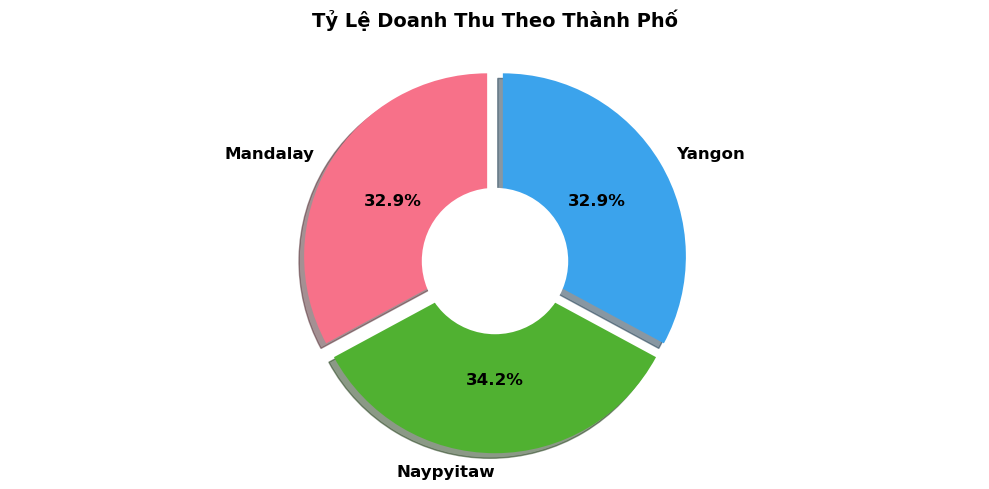

In [35]:
city_sales = supermarket_data_coppy.groupby('City')['Total'].sum().reset_index()
plt.figure(figsize=(10, 5))

# Vẽ pie
plt.pie(
    city_sales['Total'],
    labels=city_sales['City'],
    autopct='%1.1f%%',          # hiển thị phần trăm + 1 chữ số thập phân
    startangle=90,
    colors=sns.color_palette('husl', len(city_sales)),  # màu đẹp
    shadow=True,
    explode=[0.05] * len(city_sales),  # tách nhẹ các miếng
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# Thêm tiêu đề và vòng tròn giữa (donut style giống px)
centre_circle = plt.Circle((0,0), 0.4, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Tỷ Lệ Doanh Thu Theo Thành Phố', fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')  # giữ hình tròn
plt.tight_layout()
plt.show()

**\- Phân tích:**

* Tỷ lệ doanh thu giữa ba chi nhánh không có sự chênh lệch quá lớn

* Thành phố Mandalay và Yangon có tỷ lệ bằng nhau 

* Thành phố Naypytitaw đóng góp doanh thu cao nhất trong cả ba thành phố

# Phân tích sản phẩm 

## Số lượng sản phẩm bán ra

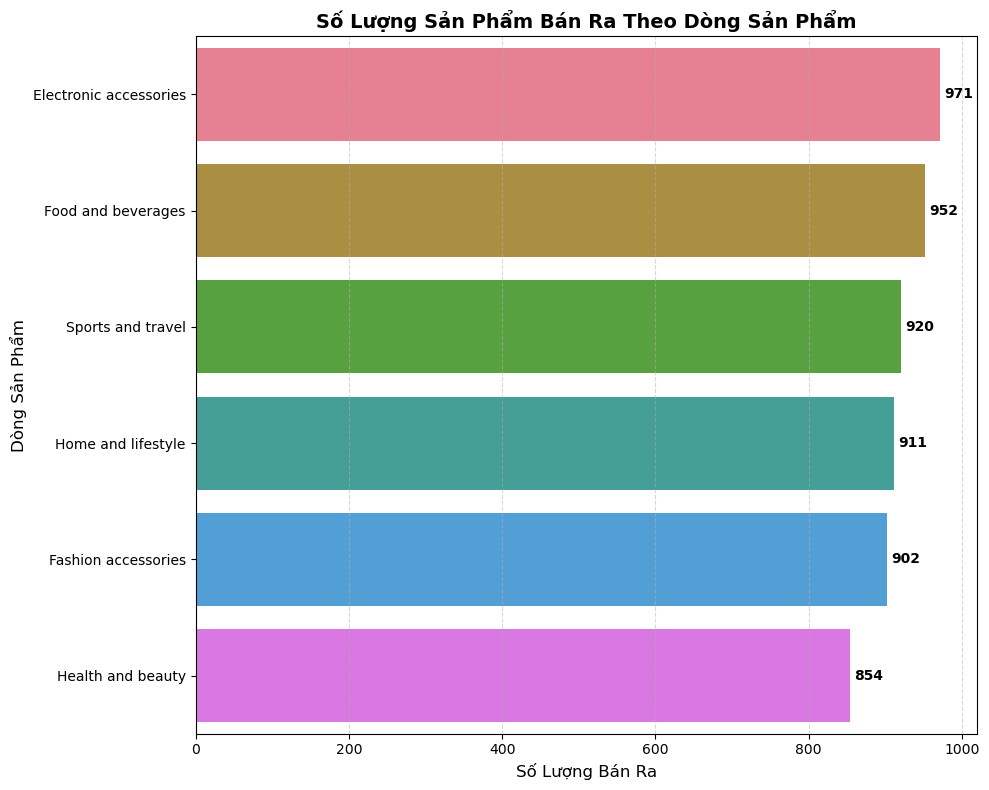

In [36]:
product_line_sales = supermarket_data_coppy.groupby('Product line')['Quantity'].sum().reset_index()

product_line_sales = product_line_sales.sort_values('Quantity', ascending=False)

plt.figure(figsize=(10, 8))  # Kích thước phù hợp cho ngang (cao hơn để chứa nhiều dòng)

ax = sns.barplot(
    data=product_line_sales,
    x='Quantity',               # Hoán đổi: x là Quantity để thanh ngang
    y='Product line',           # y là Product line
    palette='husl',
    hue='Product line',         # Để màu khác nhau theo dòng sản phẩm
    legend=False                # Không cần legend
)

plt.title('Số Lượng Sản Phẩm Bán Ra Theo Dòng Sản Phẩm', fontsize=14, fontweight='bold')
plt.xlabel('Số Lượng Bán Ra', fontsize=12)
plt.ylabel('Dòng Sản Phẩm', fontsize=12)

# Hiển thị số trên mỗi thanh (định dạng số nguyên, đặt vị trí phù hợp cho ngang)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10, fontweight='bold')

plt.yticks(fontsize=10)  # Font cho label y (không cần xoay vì ngang)
plt.grid(axis='x', linestyle='--', alpha=0.5)  # Grid theo x vì ngang
plt.tight_layout()
plt.show()

In [37]:
# tổng số lượng bán ra của tất cả các dòng sản phẩm
total_quantity = product_line_sales['Quantity'].sum()
print(f"Tổng số lượng bán ra của tất cả các dòng sản phẩm là: {total_quantity}")

Tổng số lượng bán ra của tất cả các dòng sản phẩm là: 5510


## Số lượng sản phẩm bán ra theo chi nhánh/thành phố

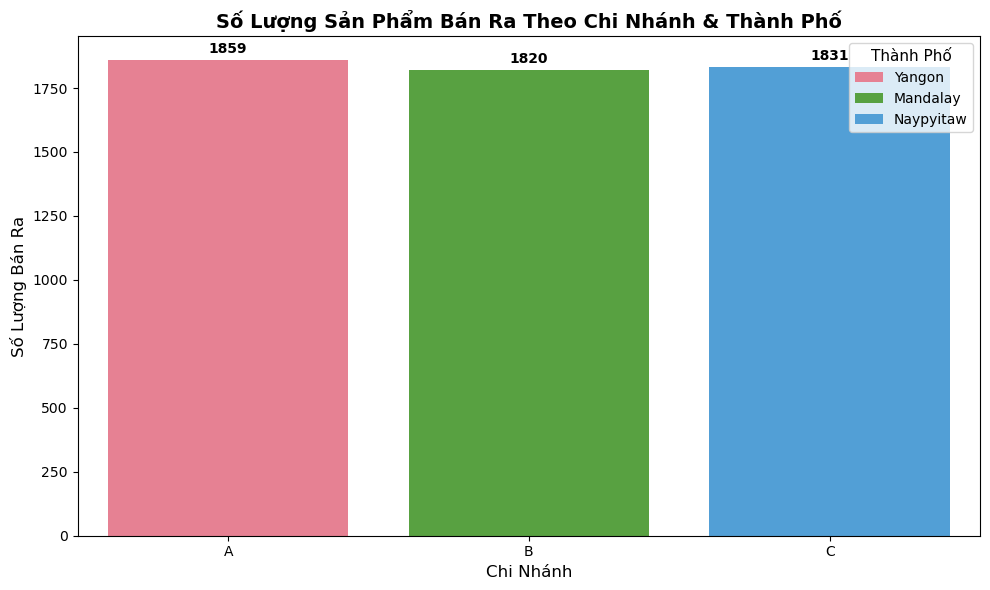

In [38]:
# số lượng sản bán ra theo chi nhánh/thành phố
branch_city_quantity = supermarket_data_coppy.groupby(['Branch', 'City'])['Quantity'].sum().reset_index()
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=branch_city_quantity,
    x='Branch',
    y='Quantity',
    hue='City',
    palette='husl',
    errorbar=None
)
plt.title('Số Lượng Sản Phẩm Bán Ra Theo Chi Nhánh & Thành Phố', fontsize=14, fontweight='bold')
plt.xlabel('Chi Nhánh', fontsize=12)
plt.ylabel('Số Lượng Bán Ra', fontsize=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10, fontweight='bold')
plt.legend(title='Thành Phố', title_fontsize=11, fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

## Số lượng dòng sản phẩm bán ra theo chi nhánh A

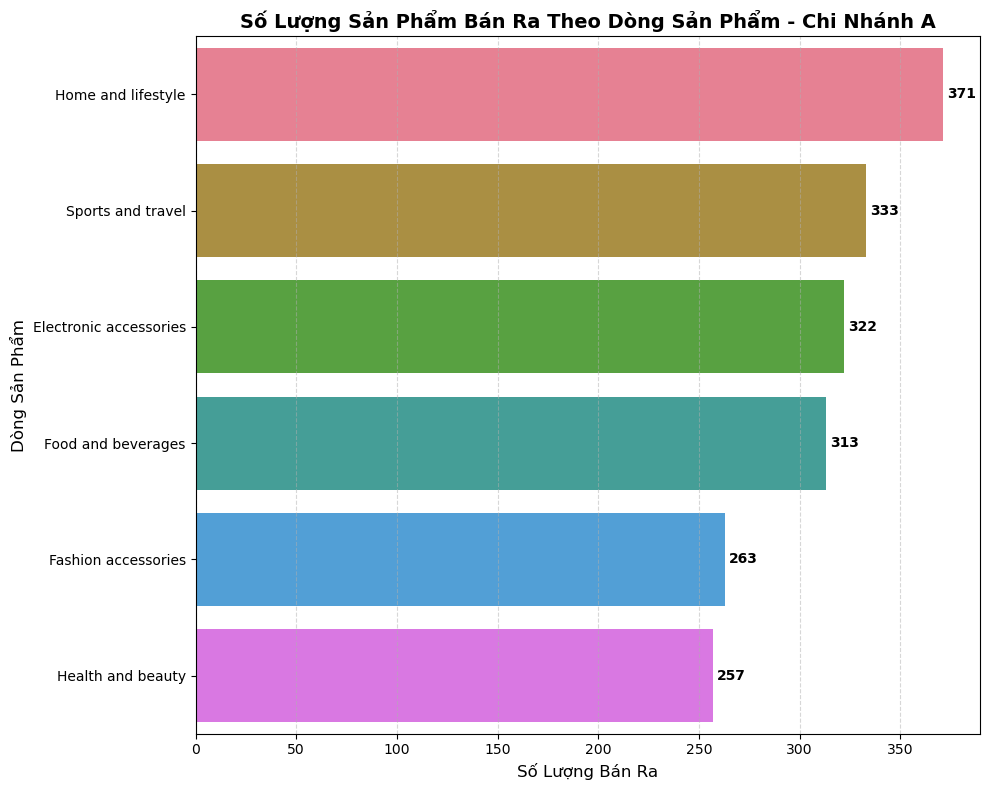

In [39]:
# Lọc và groupby như trên
branch_a_data = supermarket_data_coppy[supermarket_data_coppy['Branch'] == 'A']
product_line_a = branch_a_data.groupby('Product line')['Quantity'].sum().reset_index()
product_line_a = product_line_a.sort_values('Quantity', ascending=False)

# Vẽ ngang
plt.figure(figsize=(10, 8))  # Cao hơn để chứa tên sản phẩm

ax = sns.barplot(
    data=product_line_a,
    x='Quantity',
    y='Product line',
    palette='husl',
    hue='Product line',
    legend=False
)

plt.title('Số Lượng Sản Phẩm Bán Ra Theo Dòng Sản Phẩm - Chi Nhánh A', 
          fontsize=14, fontweight='bold')
plt.xlabel('Số Lượng Bán Ra', fontsize=12)
plt.ylabel('Dòng Sản Phẩm', fontsize=12)

# Thêm nhãn số bên phải thanh
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10, fontweight='bold')

plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Số lượng dòng sản phẩm bán ra theo chi nhánh B

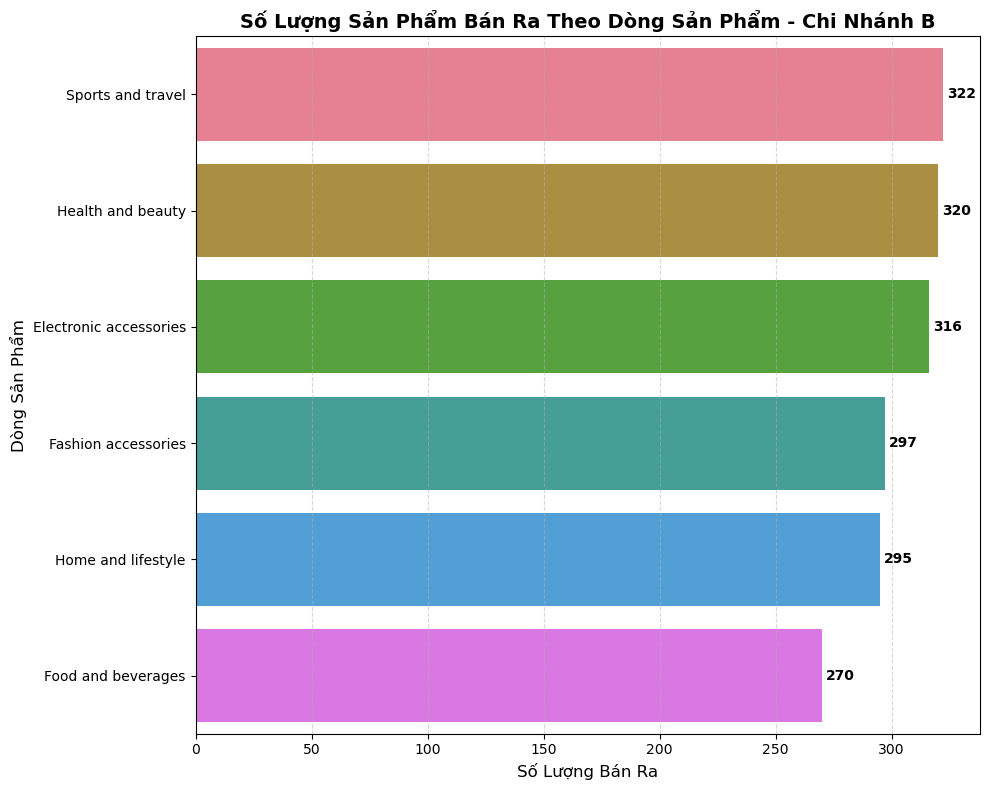

In [40]:
# Lọc và groupby như trên
branch_b_data = supermarket_data_coppy[supermarket_data_coppy['Branch'] == 'B']
product_line_b = branch_b_data.groupby('Product line')['Quantity'].sum().reset_index()
product_line_b = product_line_b.sort_values('Quantity', ascending=False)

# Vẽ ngang
plt.figure(figsize=(10, 8))  # Cao hơn để chứa tên sản phẩm

ax = sns.barplot(
    data=product_line_b,
    x='Quantity',
    y='Product line',
    palette='husl',
    hue='Product line',
    legend=False
)

plt.title('Số Lượng Sản Phẩm Bán Ra Theo Dòng Sản Phẩm - Chi Nhánh B', 
          fontsize=14, fontweight='bold')
plt.xlabel('Số Lượng Bán Ra', fontsize=12)
plt.ylabel('Dòng Sản Phẩm', fontsize=12)

# Thêm nhãn số bên phải thanh
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10, fontweight='bold')

plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Số lượng dòng sản phẩm bán ra theo chi nhánh C

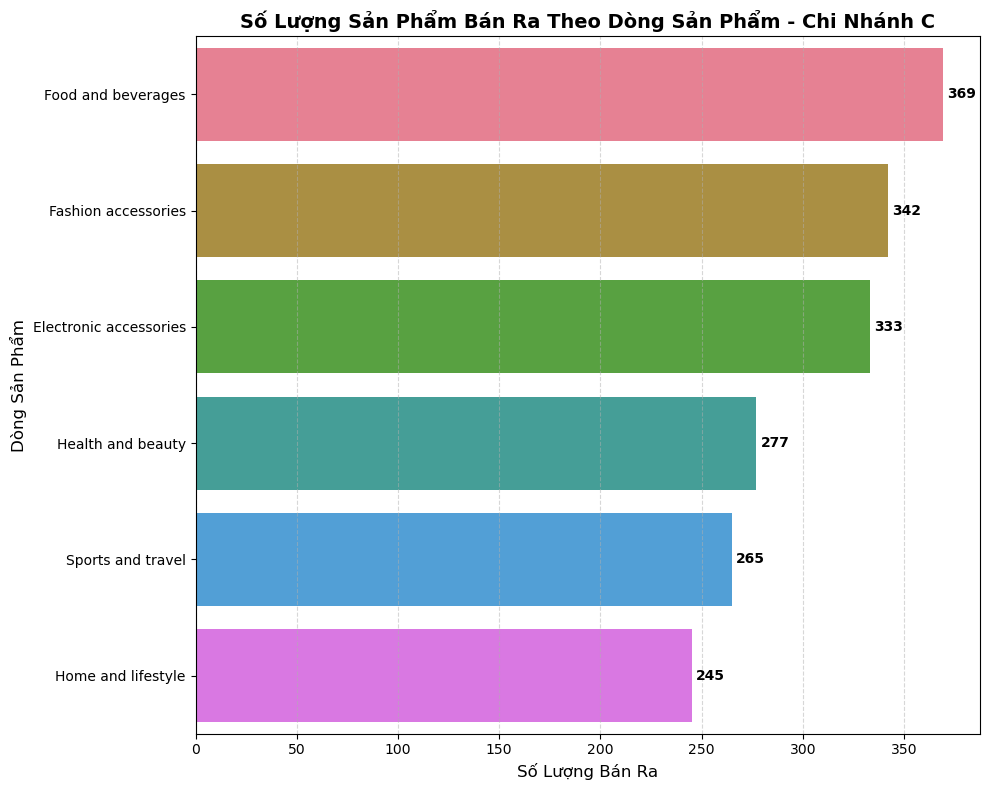

In [41]:
# Lọc và groupby như trên
branch_c_data = supermarket_data_coppy[supermarket_data_coppy['Branch'] == 'C']
product_line_c = branch_c_data.groupby('Product line')['Quantity'].sum().reset_index()
product_line_c = product_line_c.sort_values('Quantity', ascending=False)

# Vẽ ngang
plt.figure(figsize=(10, 8))  # Cao hơn để chứa tên sản phẩm

ax = sns.barplot(
    data=product_line_c,
    x='Quantity',
    y='Product line',
    palette='husl',
    hue='Product line',
    legend=False
)

plt.title('Số Lượng Sản Phẩm Bán Ra Theo Dòng Sản Phẩm - Chi Nhánh C', 
          fontsize=14, fontweight='bold')
plt.xlabel('Số Lượng Bán Ra', fontsize=12)
plt.ylabel('Dòng Sản Phẩm', fontsize=12)

# Thêm nhãn số bên phải thanh
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10, fontweight='bold')

plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##  Doanh thu theo từng sản phẩm

Sản phẩm có doanh thu CAO NHẤT: Food and beverages
Doanh thu: 56,144.84
Sản phẩm có doanh thu THẤP NHẤT: Health and beauty
Doanh thu: 49,193.74


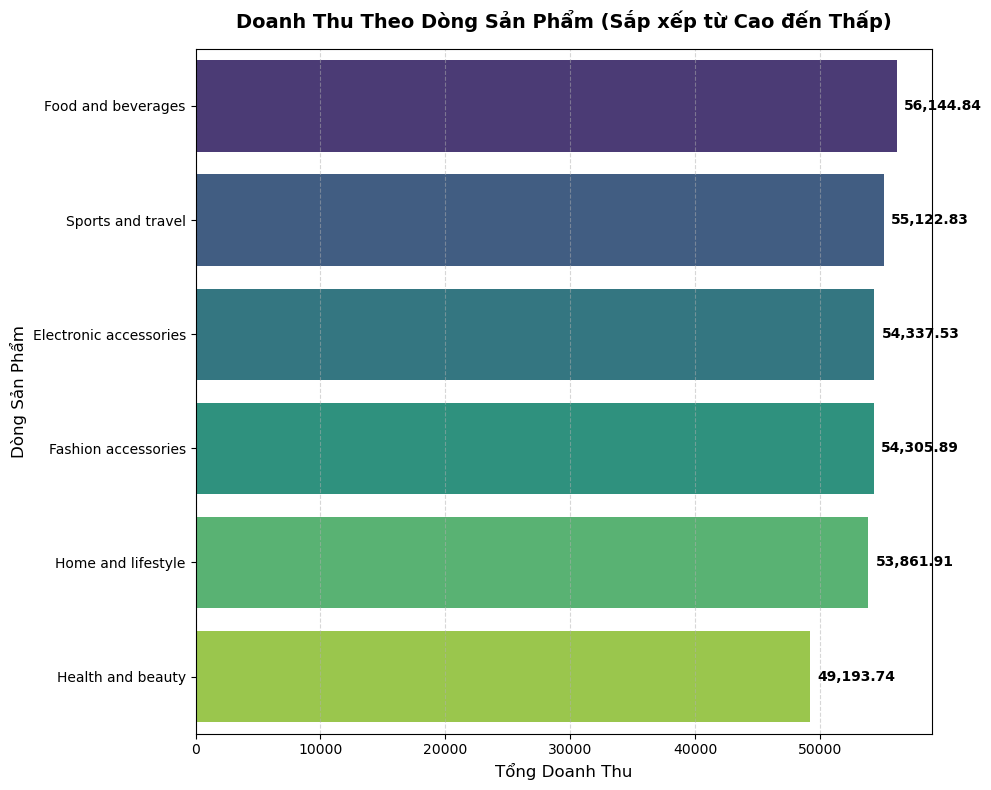

In [42]:
# 1. Tính tổng doanh thu (Total) theo từng dòng sản phẩm
product_sales = supermarket_data_coppy.groupby('Product line')['Total'].sum().reset_index()

# 2. Sắp xếp từ cao đến thấp để cột ngang có thứ tự rõ ràng
product_sales = product_sales.sort_values('Total', ascending=False)

# 3. Xác định sản phẩm cao nhất và thấp nhất
highest_product = product_sales.iloc[0]
lowest_product  = product_sales.iloc[-1]

print(f"Sản phẩm có doanh thu CAO NHẤT: {highest_product['Product line']}")
print(f"Doanh thu: {highest_product['Total']:,.2f}")
print(f"Sản phẩm có doanh thu THẤP NHẤT: {lowest_product['Product line']}")
print(f"Doanh thu: {lowest_product['Total']:,.2f}")

# 4. Vẽ biểu đồ cột NGANG
plt.figure(figsize=(10, 8))  # Kích thước phù hợp cho tên sản phẩm dài

ax = sns.barplot(
    data=product_sales,
    x='Total',
    y='Product line',
    palette='viridis',          # palette đẹp, thay 'husl' nếu muốn
    hue='Product line',
    legend=False
)

# Thêm nhãn số trên thanh (định dạng có dấu phẩy, 2 chữ số thập phân)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}', padding=5, fontsize=10, fontweight='bold')

plt.title('Doanh Thu Theo Dòng Sản Phẩm (Sắp xếp từ Cao đến Thấp)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tổng Doanh Thu', fontsize=12)
plt.ylabel('Dòng Sản Phẩm', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Doanh thu theo từng dòng sản phẩm của chi nhánh A

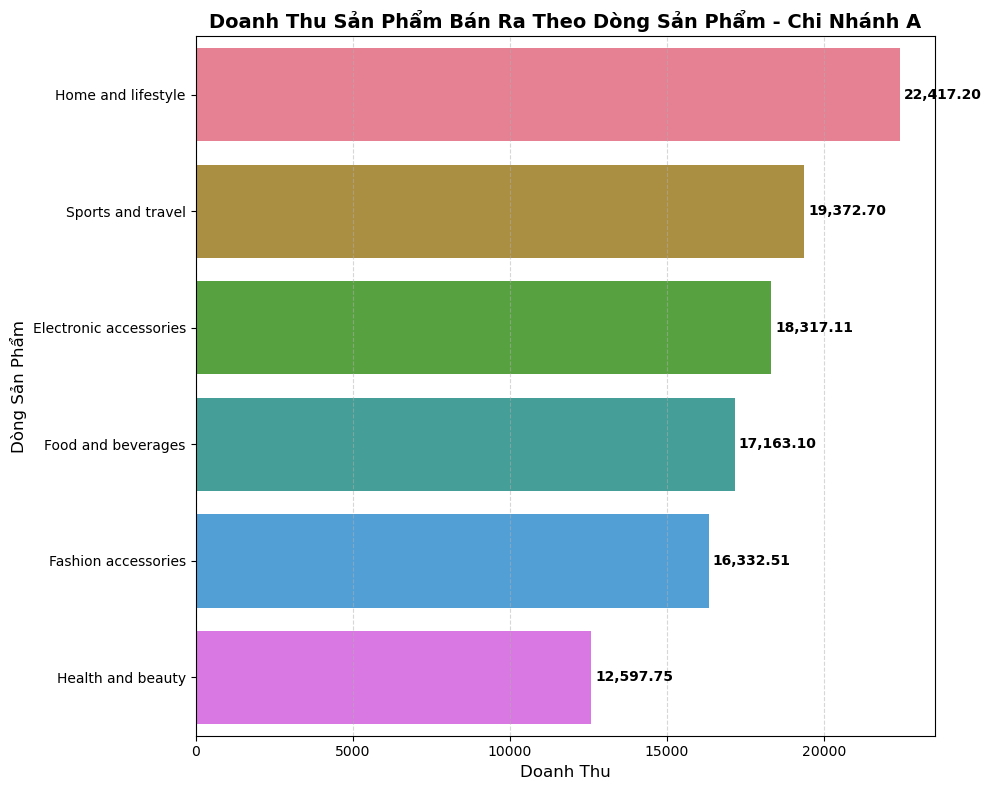

In [43]:
# Lọc và groupby như trên
branch_a_data = supermarket_data_coppy[supermarket_data_coppy['Branch'] == 'A']
product_line_a = branch_a_data.groupby('Product line')['Total'].sum().reset_index()
product_line_a = product_line_a.sort_values('Total', ascending=False)

# Vẽ ngang
plt.figure(figsize=(10, 8))  # Cao hơn để chứa tên sản phẩm

ax = sns.barplot(
    data=product_line_a,
    x='Total',
    y='Product line',
    palette='husl',
    hue='Product line',
    legend=False
)

plt.title('Doanh Thu Sản Phẩm Bán Ra Theo Dòng Sản Phẩm - Chi Nhánh A', 
          fontsize=14, fontweight='bold')
plt.xlabel('Doanh Thu', fontsize=12)
plt.ylabel('Dòng Sản Phẩm', fontsize=12)

# Thêm nhãn số bên phải thanh
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}', padding=3, fontsize=10, fontweight='bold')

plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Doanh thu theo từng dòng sản phẩm của chi nhánh B

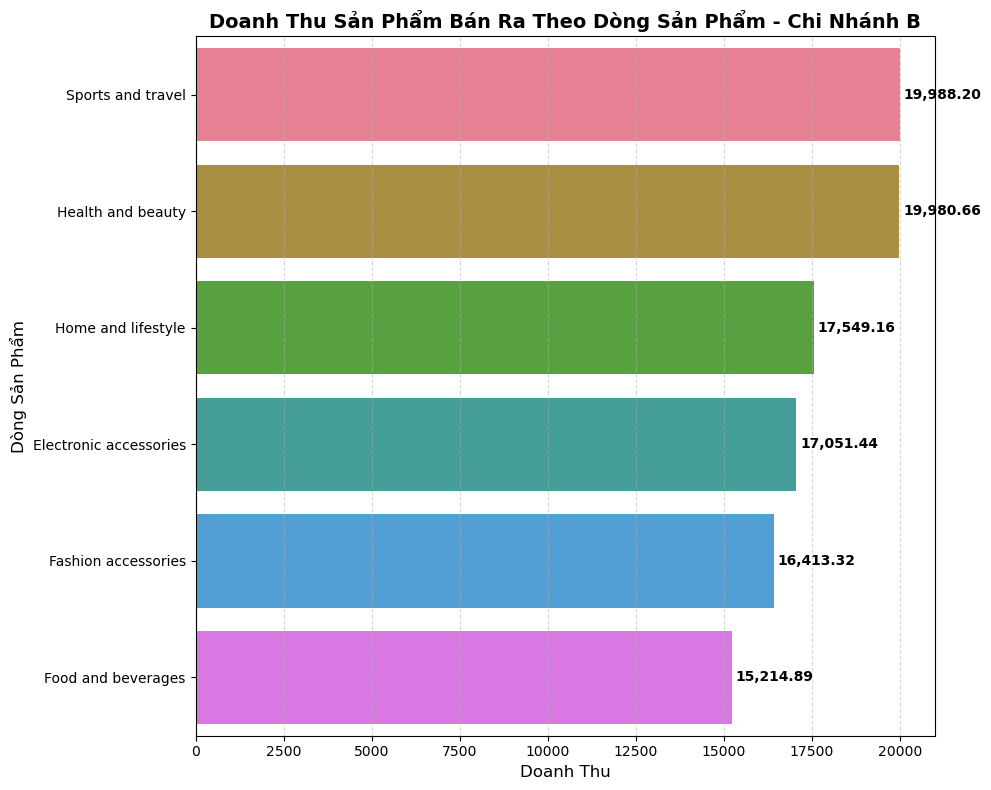

In [44]:
# Lọc và groupby như trên
branch_b_data = supermarket_data_coppy[supermarket_data_coppy['Branch'] == 'B']
product_line_b = branch_b_data.groupby('Product line')['Total'].sum().reset_index()
product_line_b = product_line_b.sort_values('Total', ascending=False)

# Vẽ ngang
plt.figure(figsize=(10, 8))  # Cao hơn để chứa tên sản phẩm

ax = sns.barplot(
    data=product_line_b,
    x='Total',
    y='Product line',
    palette='husl',
    hue='Product line',
    legend=False
)

plt.title('Doanh Thu Sản Phẩm Bán Ra Theo Dòng Sản Phẩm - Chi Nhánh B', 
          fontsize=14, fontweight='bold')
plt.xlabel('Doanh Thu', fontsize=12)
plt.ylabel('Dòng Sản Phẩm', fontsize=12)

# Thêm nhãn số bên phải thanh
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}', padding=3, fontsize=10, fontweight='bold')

plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Doanh thu theo từng dòng sản phẩm của chi nhánh C

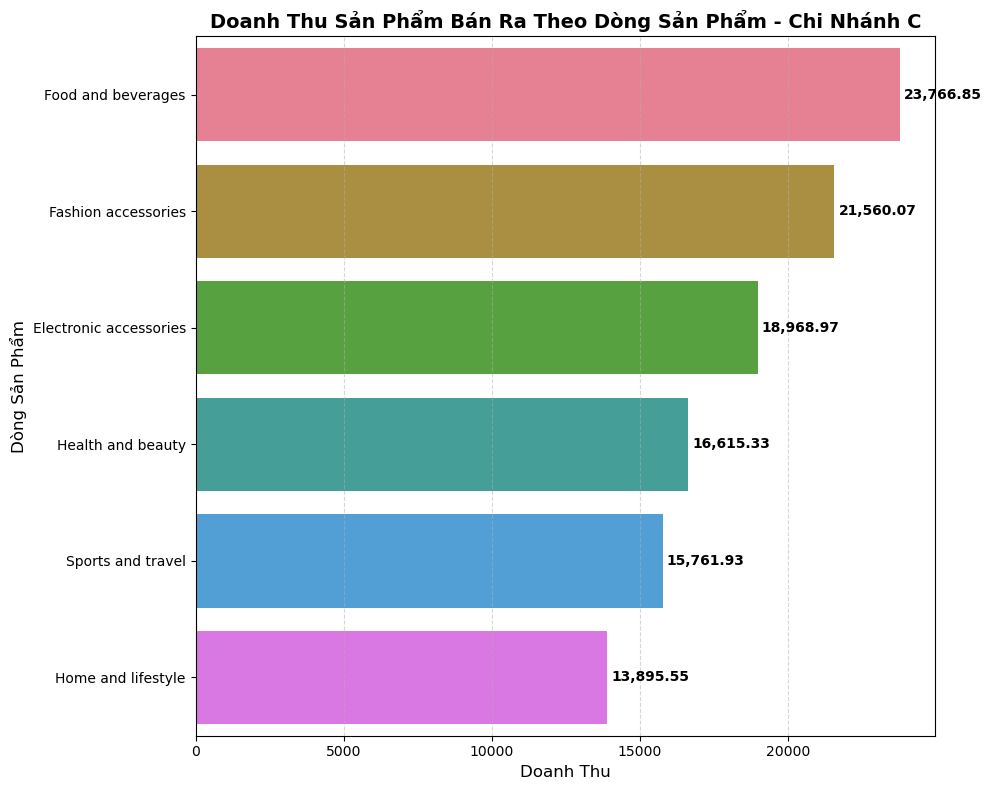

In [45]:
# Lọc và groupby như trên
branch_c_data = supermarket_data_coppy[supermarket_data_coppy['Branch'] == 'C']
product_line_c = branch_c_data.groupby('Product line')['Total'].sum().reset_index()
product_line_c = product_line_c.sort_values('Total', ascending=False)

# Vẽ ngang
plt.figure(figsize=(10, 8))  # Cao hơn để chứa tên sản phẩm

ax = sns.barplot(
    data=product_line_c,
    x='Total',
    y='Product line',
    palette='husl',
    hue='Product line',
    legend=False
)

plt.title('Doanh Thu Sản Phẩm Bán Ra Theo Dòng Sản Phẩm - Chi Nhánh C', 
          fontsize=14, fontweight='bold')
plt.xlabel('Doanh Thu', fontsize=12)
plt.ylabel('Dòng Sản Phẩm', fontsize=12)

# Thêm nhãn số bên phải thanh
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}', padding=3, fontsize=10, fontweight='bold')

plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Phân Tích Theo Thời Gian

## Xu hướng doanh thu theo ngày

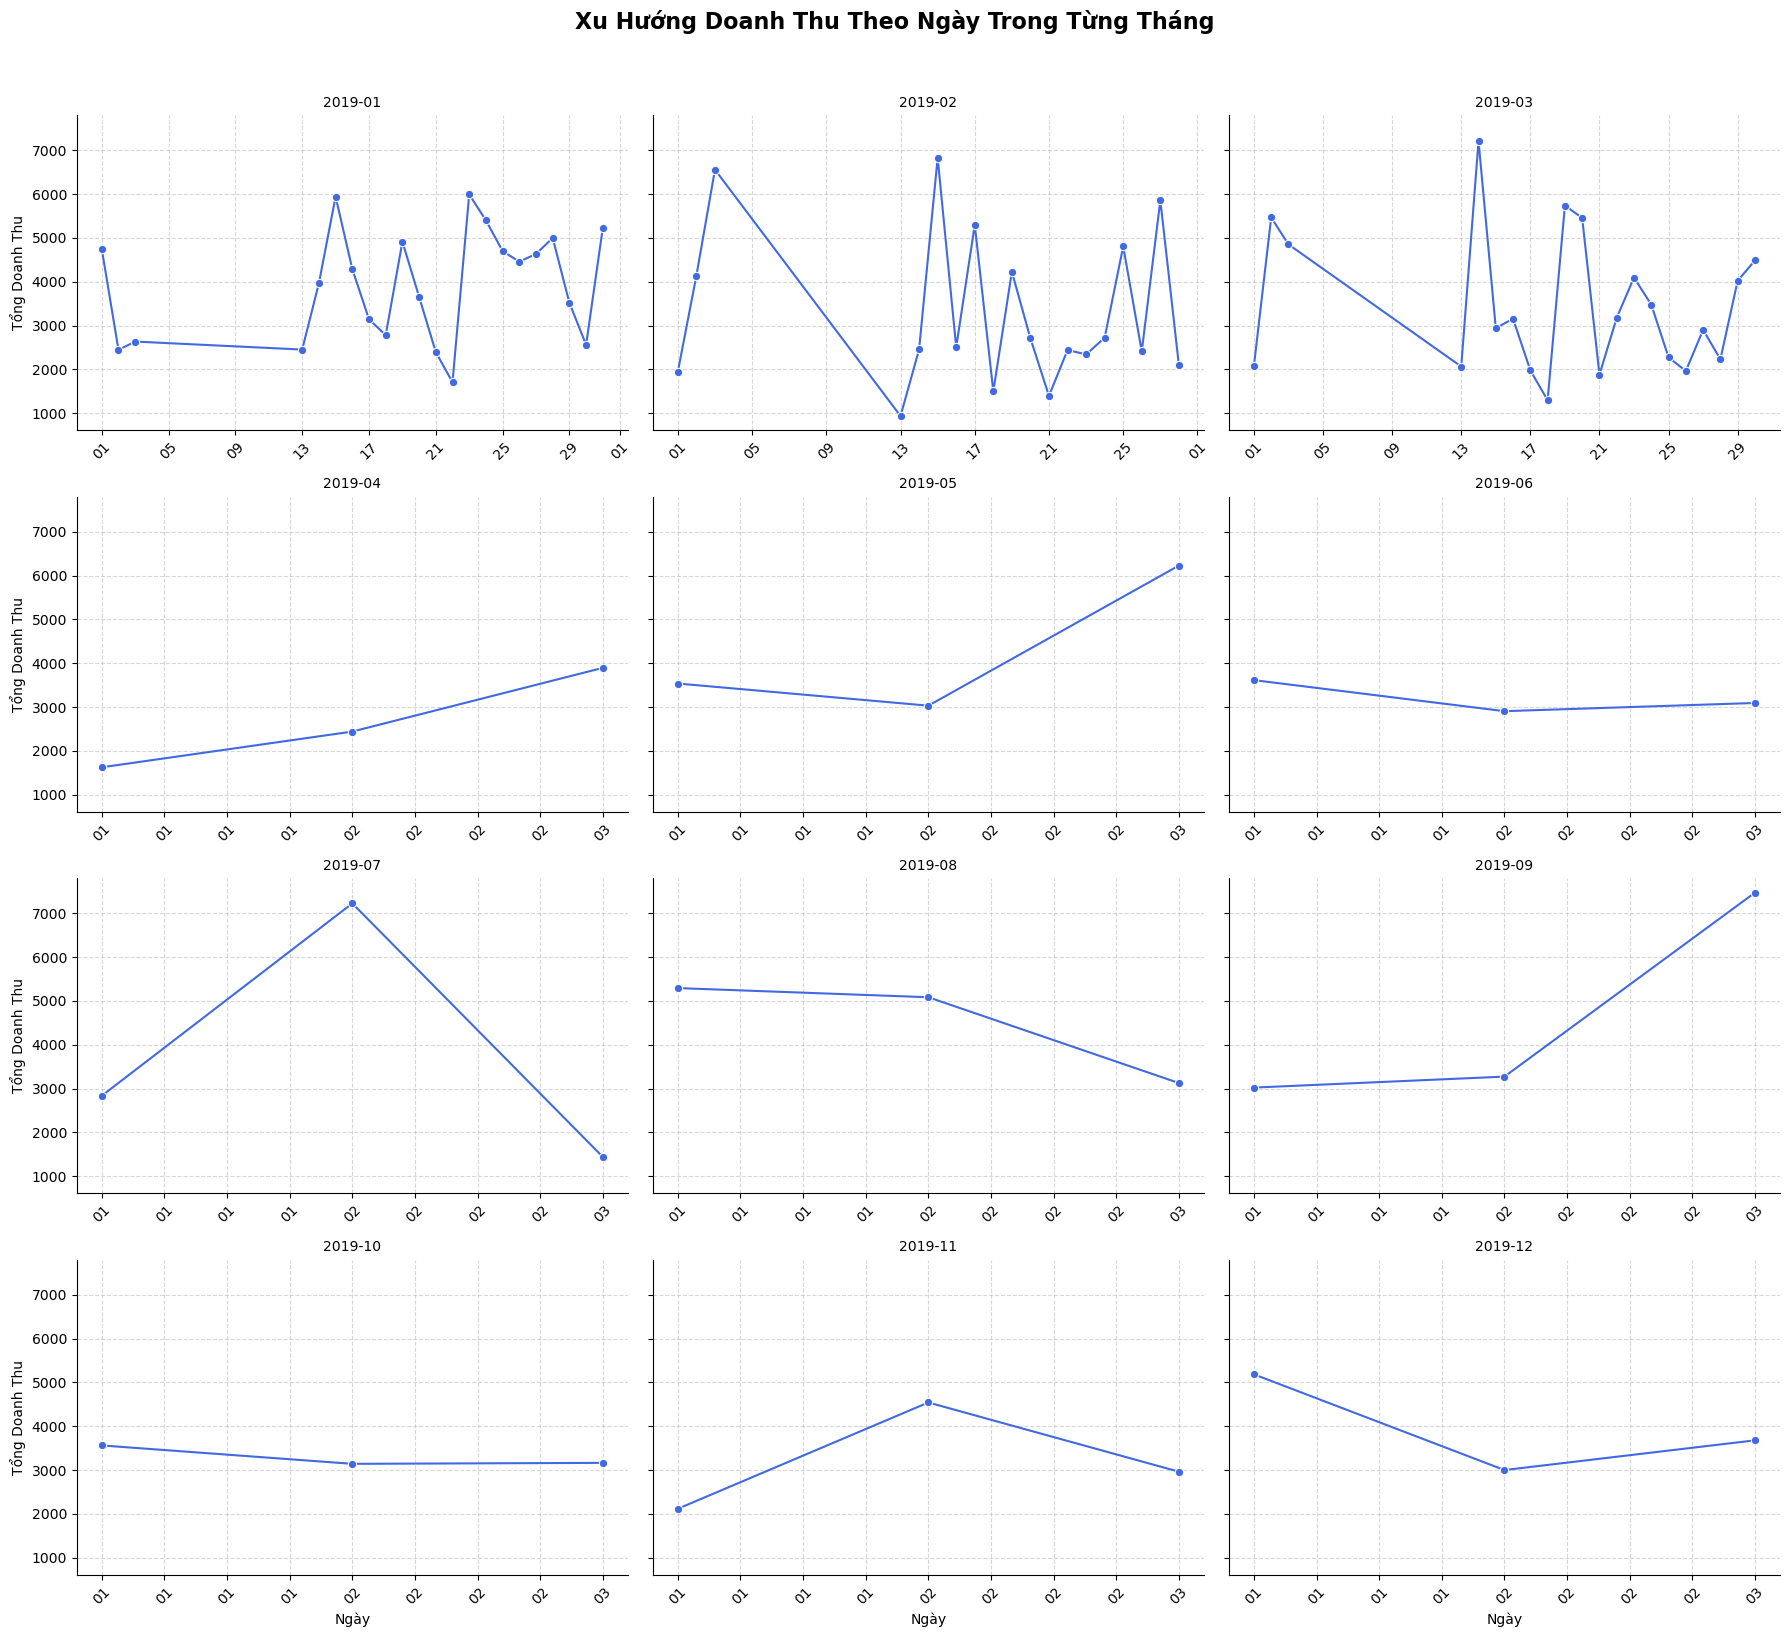

In [46]:
supermarket_data_coppy['Date'] = pd.to_datetime(supermarket_data_coppy['Date'])
supermarket_data_coppy['Month'] = supermarket_data_coppy['Date'].dt.to_period('M').astype(str)  # '2019-01', '2019-02',...

daily_sales = supermarket_data_coppy.groupby(['Date', 'Month'])['Total'].sum().reset_index()

# Sắp xếp theo ngày để đường line mượt
daily_sales = daily_sales.sort_values('Date')

# Vẽ facetgrid
g = sns.FacetGrid(
    data=daily_sales,
    col='Month',                  # Mỗi tháng một subplot
    col_wrap=3,                   # Nếu nhiều tháng thì wrap xuống dòng
    height=4,
    aspect=1.5,
    sharey=True,                  # Chia sẻ trục y để so sánh dễ
    sharex=False                  # Không chia sẻ trục x vì mỗi tháng ngày khác
)

g.map(sns.lineplot, 'Date', 'Total', marker='o', color='royalblue')

# Thêm tiêu đề cho từng facet
g.set_titles(col_template="{col_name}")

# Format chung
g.set_axis_labels('Ngày', 'Tổng Doanh Thu')
g.set(xticklabels=[] )  # Ẩn label ngày nếu muốn gọn, hoặc format riêng bên dưới

# Format ngày cho từng subplot (tùy chọn)
for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d'))
    ax.tick_params(axis='x', rotation=45)
    ax.grid(linestyle='--', alpha=0.5)

g.fig.suptitle('Xu Hướng Doanh Thu Theo Ngày Trong Từng Tháng', fontsize=16, fontweight='bold', y=1.02)
g.tight_layout()
plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


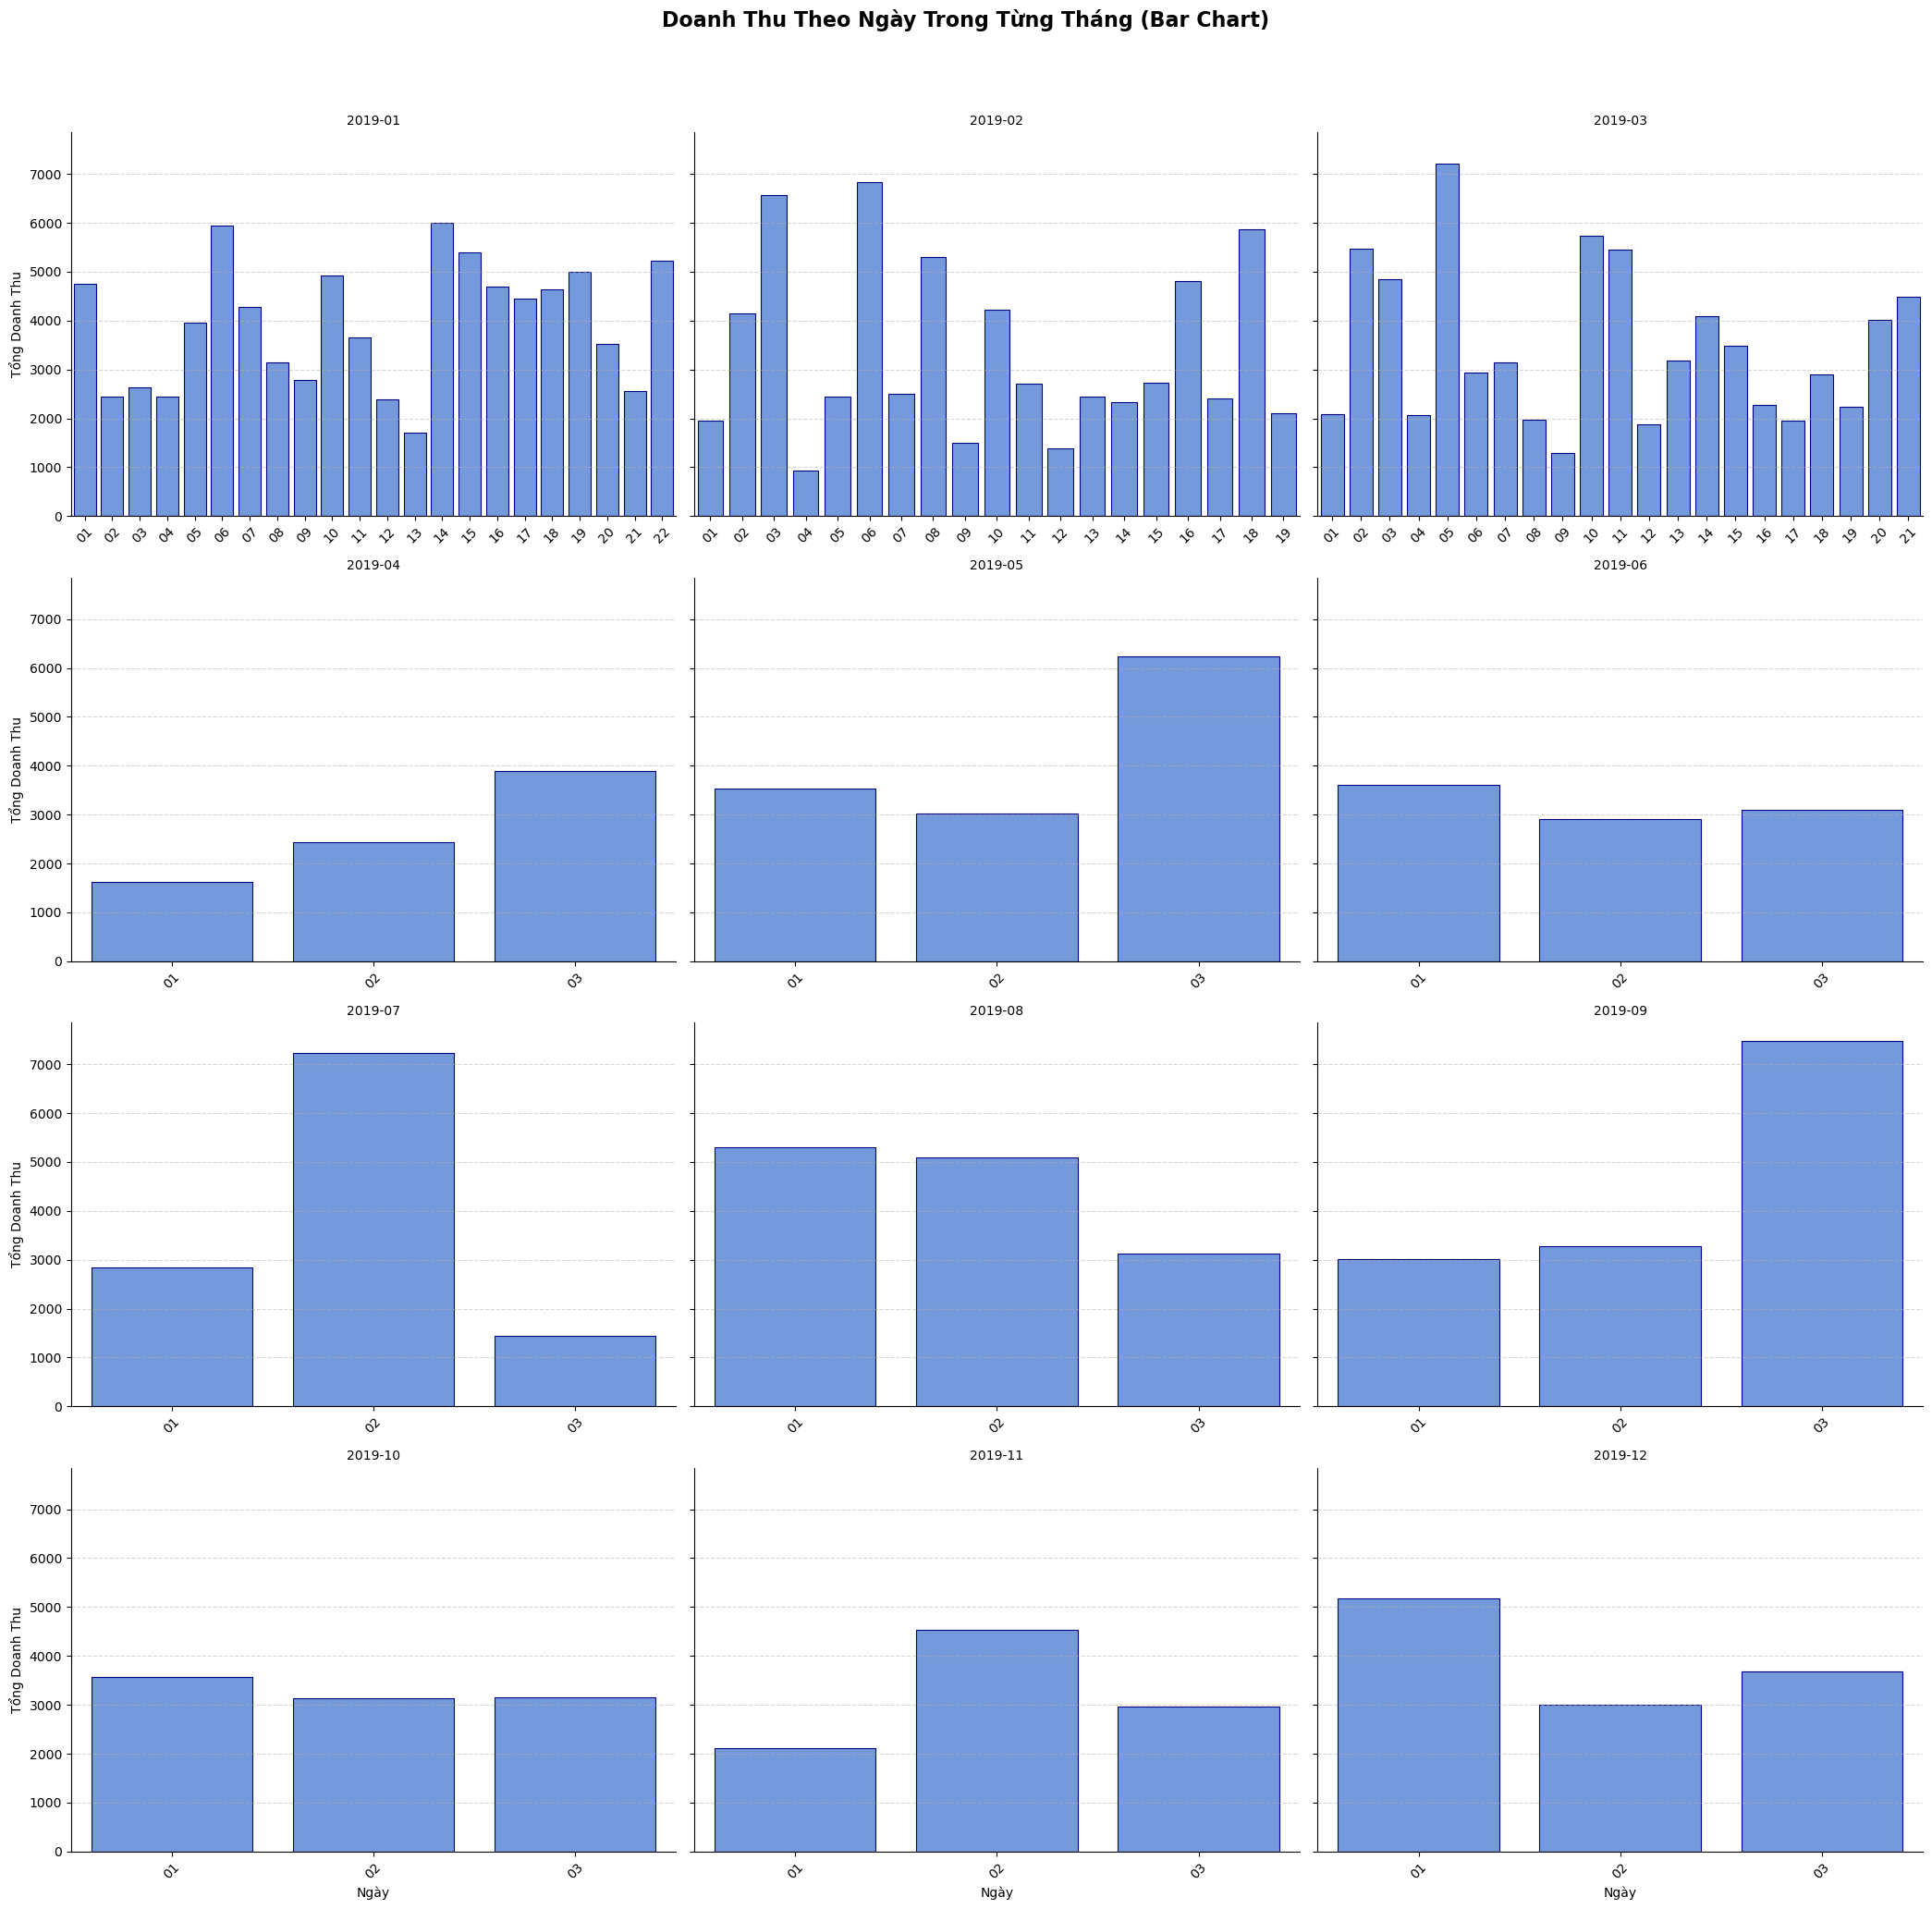

In [47]:
g = sns.FacetGrid(
    data=daily_sales,
    col='Month',
    col_wrap=3,
    height=5,
    aspect=1.4,
    sharey=True,
    sharex=False
)

# Vẽ BAR CHART theo ngày
g.map(sns.barplot, 'Date', 'Total', color='cornflowerblue', edgecolor='navy', linewidth=0.8)

# Format ngày
for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d'))
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

g.set_titles(col_template="{col_name}")
g.set_axis_labels('Ngày', 'Tổng Doanh Thu')

g.fig.suptitle('Doanh Thu Theo Ngày Trong Từng Tháng (Bar Chart)', 
               fontsize=16, fontweight='bold', y=1.03)

g.tight_layout()
plt.show()

## Các ngày có doanh thu cao nhất theo tháng

In [48]:
supermarket_data_coppy['Date'] = pd.to_datetime(supermarket_data_coppy['Date'])

supermarket_data_coppy['Month'] = supermarket_data_coppy['Date'].dt.to_period('M').astype(str)
supermarket_data_coppy['Day'] = supermarket_data_coppy['Date'].dt.day

daily_total = supermarket_data_coppy.groupby(['Month', 'Day'])['Total'].sum().reset_index()


daily_total_sorted = daily_total.sort_values(['Month', 'Total'], ascending=[True, False])
highest_day_per_month = daily_total_sorted.groupby('Month').head(1).reset_index(drop=True)

# Hiển thị kết quả
print("Ngày có doanh thu CAO NHẤT trong từng tháng:")
print(highest_day_per_month[['Month', 'Day', 'Total']])

Ngày có doanh thu CAO NHẤT trong từng tháng:
      Month  Day      Total
0   2019-01   23  5994.1875
1   2019-02   15  6830.7855
2   2019-03   14  7214.6340
3   2019-04    3  3894.4395
4   2019-05    3  6230.8785
5   2019-06    1  3614.2050
6   2019-07    2  7228.2105
7   2019-08    1  5293.7325
8   2019-09    3  7474.0470
9   2019-10    1  3560.9490
10  2019-11    2  4542.1530
11  2019-12    1  5184.7635


## Xu hướng doanh thu theo tháng

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\2582131375.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=monthly_total, x='Month', y='Total', palette='viridis')


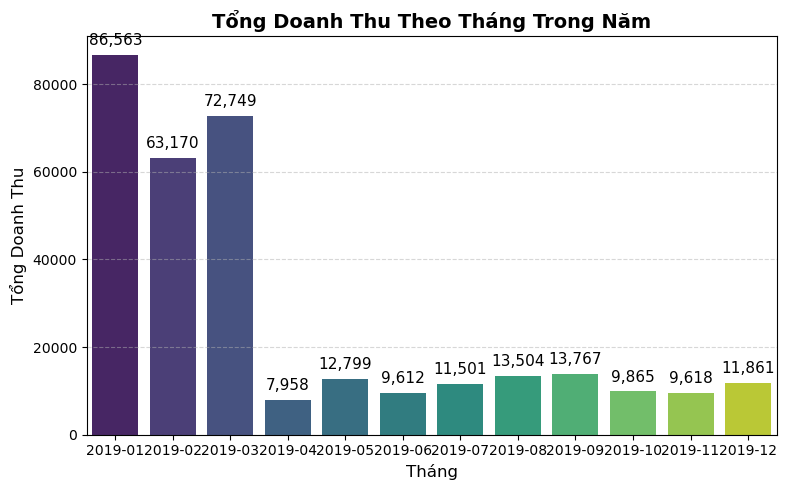

In [49]:
monthly_total = supermarket_data_coppy.groupby('Month')['Total'].sum().reset_index()
monthly_total = monthly_total.sort_values('Month')

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=monthly_total, x='Month', y='Total', palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=5, fontsize=11)

plt.title('Tổng Doanh Thu Theo Tháng Trong Năm', fontsize=14, fontweight='bold')
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Tổng Doanh Thu', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Mối quan hệ giữa doanh thu theo giờ trong ngày và ngày trong tuần

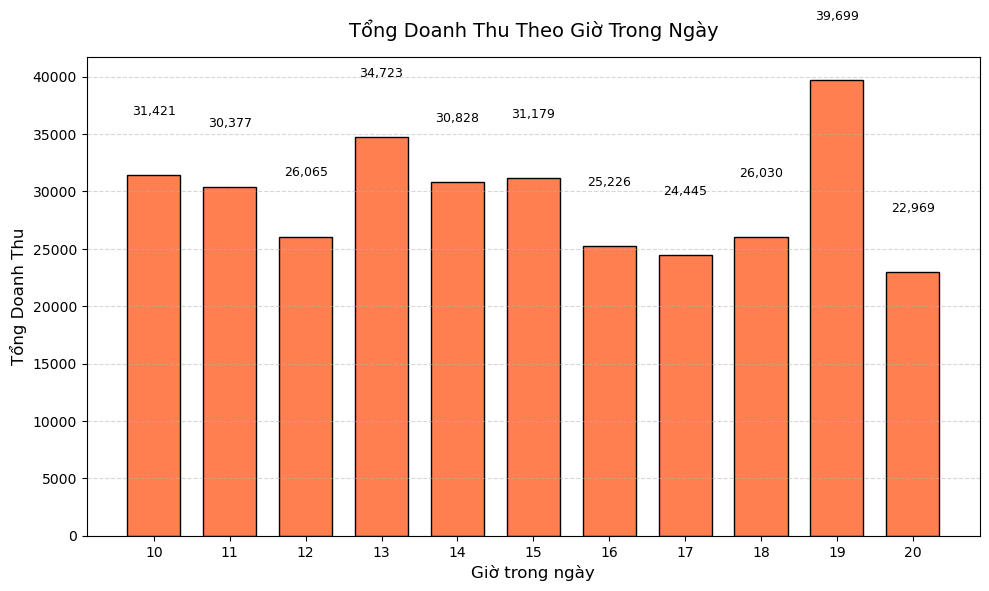

In [50]:
# Tính tổng doanh thu theo giờ (đã có sẵn)
hour_sales = supermarket_data_coppy.groupby('Hour')['Total'].sum().reset_index()

# (Tùy chọn) Lọc bỏ giờ không có dữ liệu nếu muốn rõ ràng hơn
hour_sales = hour_sales[hour_sales['Total'] > 0]

# Sắp xếp lại theo giờ (để chắc chắn)
hour_sales = hour_sales.sort_values('Hour')

# Vẽ bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(hour_sales['Hour'], hour_sales['Total'], 
               color='coral', edgecolor='black', width=0.7)

plt.title('Tổng Doanh Thu Theo Giờ Trong Ngày', fontsize=14, pad=15)
plt.xlabel('Giờ trong ngày', fontsize=12)
plt.ylabel('Tổng Doanh Thu', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Thêm giá trị lên đầu mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5000,   # điều chỉnh +5000 nếu giá trị quá cao/thấp
             f'{int(yval):,}', ha='center', va='bottom', fontsize=9)

# Chỉ hiển thị ticks cho các giờ CÓ dữ liệu (không hiển thị 0-23 đầy đủ)
plt.xticks(hour_sales['Hour'])  # <-- đây là thay đổi chính

plt.tight_layout()
plt.show()

In [51]:
supermarket_data_coppy['Day_of_week'] = supermarket_data_coppy['Date'].dt.day_name()
supermarket_data_coppy

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,...,Rating,Tax,Hour,Time of Day,YearMonth,Quarter,Rating Category,Month,Day,Day_of_week
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,...,9.1,26.1415,13,Trưa,2019-05,2019Q2,Tốt,2019-05,1,Wednesday
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.82,80.2200,...,9.6,3.8200,10,Sáng,2019-08,2019Q3,Tốt,2019-08,3,Saturday
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,...,7.4,16.2155,13,Trưa,2019-03,2019Q1,Trung bình,2019-03,3,Sunday
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.288,489.0480,...,8.4,23.2880,20,Tối,2019-01,2019Q1,Khá,2019-01,27,Sunday
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,...,5.3,30.2085,10,Sáng,2019-08,2019Q3,Kém,2019-08,2,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,1/1/1900,42.3675,...,6.2,2.0175,13,Trưa,2019-01,2019Q1,Kém,2019-01,29,Tuesday
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,2/16/1900,1022.4900,...,4.4,48.6900,17,Chiều,2019-02,2019Q1,Rất kém,2019-02,3,Sunday
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,12/31/1899,33.4320,...,7.7,1.5920,13,Trưa,2019-09,2019Q3,Khá,2019-09,2,Monday
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,1/2/1900,69.1110,...,4.1,3.2910,15,Chiều,2019-02,2019Q1,Rất kém,2019-02,22,Friday


In [52]:
supermarket_data_coppy['Is_weekend'] = supermarket_data_coppy['Date'].dt.weekday >= 5
# True = Saturday/Sunday, False = Monday–Friday

In [53]:
# ==================== Tạo cột thời gian (chạy 1 lần) ====================

supermarket_data_coppy['Date'] = pd.to_datetime(supermarket_data_coppy['Date'])

# Tạo Hour (nếu chưa có)
if 'Hour' not in supermarket_data_coppy.columns:
    supermarket_data_coppy['Time'] = pd.to_datetime(supermarket_data_coppy['Time'], format='%H:%M')
    supermarket_data_coppy['Hour'] = supermarket_data_coppy['Time'].dt.hour

# Tạo Day_of_week (cách tốt nhất)
supermarket_data_coppy['Day_of_week'] = supermarket_data_coppy['Date'].dt.day_name()

# (Tùy chọn) Tạo thêm Is_weekend
supermarket_data_coppy['Is_weekend'] = supermarket_data_coppy['Date'].dt.weekday >= 5

# Kiểm tra nhanh
print(supermarket_data_coppy[['Date', 'Hour', 'Day_of_week', 'Is_weekend']].head(8))

        Date  Hour Day_of_week  Is_weekend
0 2019-05-01    13   Wednesday       False
1 2019-08-03    10    Saturday        True
2 2019-03-03    13      Sunday        True
3 2019-01-27    20      Sunday        True
4 2019-08-02    10      Friday       False
5 2019-03-25    18      Monday       False
6 2019-02-25    14      Monday       False
7 2019-02-24    11      Sunday        True


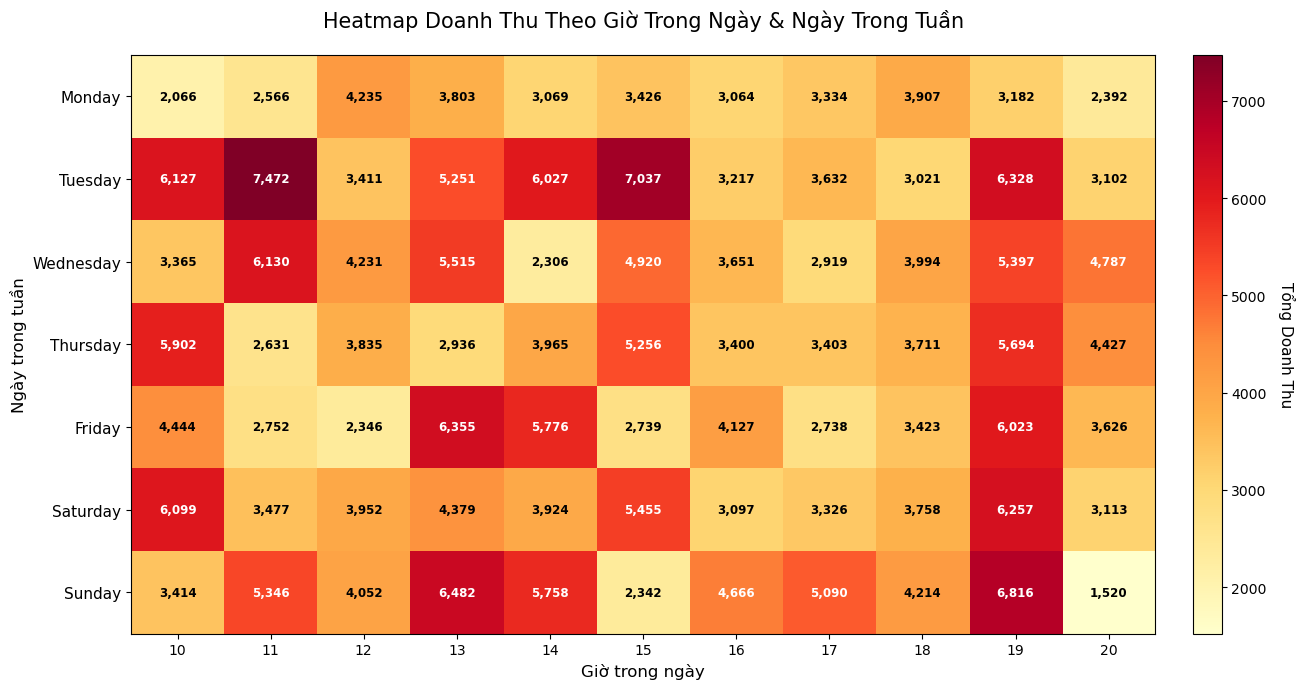

In [54]:
heatmap_data = supermarket_data_coppy.pivot_table(
    values='Total',
    index='Day_of_week',
    columns='Hour',
    aggfunc='sum',
    fill_value=0
)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(day_order)

# Vẽ heatmap bằng matplotlib
fig, ax = plt.subplots(figsize=(14, 7))         
# Vẽ ma trận màu
im = ax.imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto')

# Thêm colorbar (thanh màu bên phải)
cbar = fig.colorbar(im, ax=ax, pad=0.03)
cbar.set_label('Tổng Doanh Thu', rotation=270, labelpad=20, fontsize=11)

# Thiết lập nhãn trục x (giờ)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, fontsize=10)

# Thiết lập nhãn trục y (ngày trong tuần)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=11)

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        if value > 0:
            text_color = 'white' if value > heatmap_data.values.max() * 0.6 else 'black'
            ax.text(j, i, f'{int(value):,}',
                    ha='center', va='center', color=text_color, fontsize=8.5, fontweight='bold')

ax.set_title('Heatmap Doanh Thu Theo Giờ Trong Ngày & Ngày Trong Tuần', fontsize=15, pad=20)
ax.set_xlabel('Giờ trong ngày', fontsize=12)
ax.set_ylabel('Ngày trong tuần', fontsize=12)

plt.tight_layout()
plt.show()

In [55]:
# 2. Tạo DataFrame chỉ có doanh thu theo thứ
df_doanhthu_theo_thu = supermarket_data_coppy.groupby('Day_of_week')['Total'].sum() \
                            .reset_index(name='Tổng Doanh Thu')

# 3. Sắp xếp đúng thứ tự: Thứ 2 → Chủ Nhật
thu_tu = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_doanhthu_theo_thu = df_doanhthu_theo_thu.set_index('Day_of_week').reindex(thu_tu).reset_index()

# 4. Đổi tên cột tiếng Việt cho dễ đọc
df_doanhthu_theo_thu.columns = ['Thứ trong tuần', 'Tổng Doanh Thu']

# 5. Format số đẹp (thêm dấu phẩy, không thập phân)
df_doanhthu_theo_thu['Tổng Doanh Thu'] = df_doanhthu_theo_thu['Tổng Doanh Thu'].apply(lambda x: f"{x:,.0f}")

# Hiển thị kết quả
print("=== DOANH THU THEO THỨ TRONG TUẦN ===")
print(df_doanhthu_theo_thu.to_string(index=False))

=== DOANH THU THEO THỨ TRONG TUẦN ===
Thứ trong tuần Tổng Doanh Thu
        Monday         35,049
       Tuesday         54,630
     Wednesday         47,221
      Thursday         45,166
        Friday         44,353
      Saturday         46,843
        Sunday         49,705


# Phân tích hành vi khách hàng

## Đếm số lượng khách hàng member và normal trong toàn bộ dataset

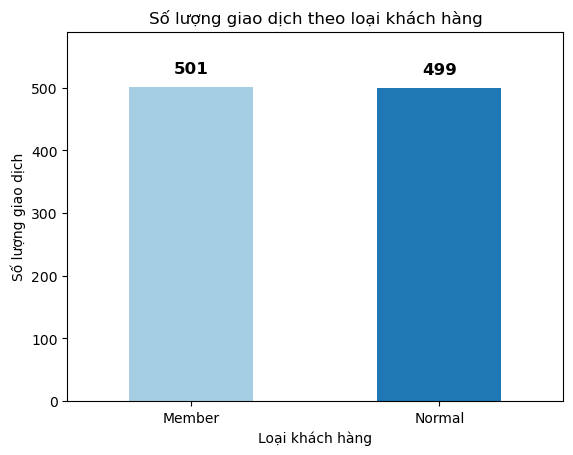

In [56]:
# số lượng khách hàng member và non-member
customer_type_counts = supermarket_data_coppy['Customer type'].value_counts()
ax = customer_type_counts.plot(kind='bar', color=plt.cm.Paired.colors)
ax.bar_label(ax.containers[0],
                labels=[f'{int(v)}' for v in customer_type_counts.values],
                padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Loại khách hàng')
plt.ylabel('Số lượng giao dịch')
plt.title('Số lượng giao dịch theo loại khách hàng')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(ticks=range(len(customer_type_counts)), labels=customer_type_counts.index, rotation=0)
plt.show()

## Đếm số lượng khách hàng theo giới tính

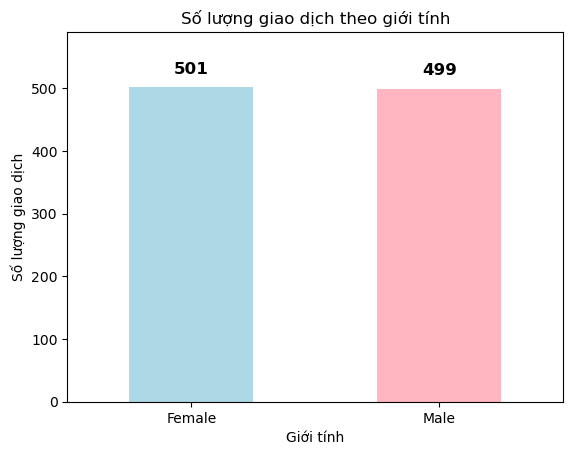

In [57]:
#số lượng khách hàng theo giới tính
gender_counts = supermarket_data_coppy['Gender'].value_counts()
ax = gender_counts.plot(kind='bar', color=['lightblue', 'lightpink'])
ax.bar_label(ax.containers[0],  
             labels=[f'{int(v)}' for v in gender_counts.values],
             padding=8, fontsize=12, fontweight='bold') 
plt.xlabel('Giới tính')
plt.ylabel('Số lượng giao dịch')
plt.title('Số lượng giao dịch theo giới tính')
plt.ylim(0, ax.get_ylim()[1] * 1.12)        
plt.xticks(ticks=range(len(gender_counts)), labels=gender_counts.index, rotation=0)
plt.show()

## Số lượng khách hàng member và normal theo từng chi nhánh/ Thành phố

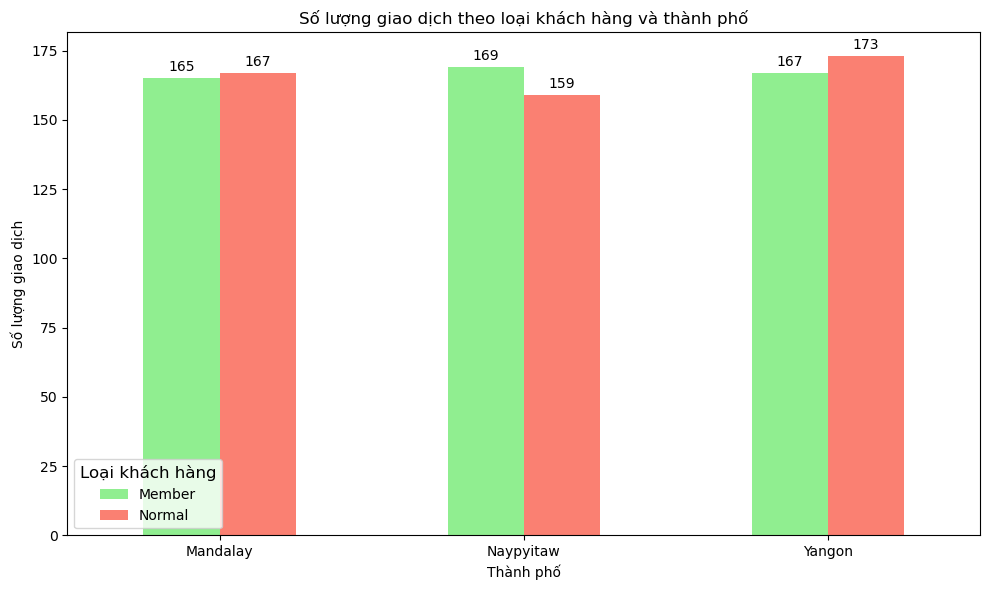

In [58]:
customer_city_counts = supermarket_data_coppy.groupby(
    ['City', 'Customer type']
).size().unstack(fill_value=0)

# Vẽ biểu đồ
ax = customer_city_counts.plot(
    kind='bar',
    stacked=False,
    color=['lightgreen', 'salmon'],
    figsize=(10, 6)
)

plt.xlabel('Thành phố')
plt.ylabel('Số lượng giao dịch')
plt.title('Số lượng giao dịch theo loại khách hàng và thành phố')
plt.xticks(rotation=0)
plt.legend(title='Loại khách hàng', title_fontsize=12, fontsize=10)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

## Số lượng khách hàng Gender theo từng thành phố

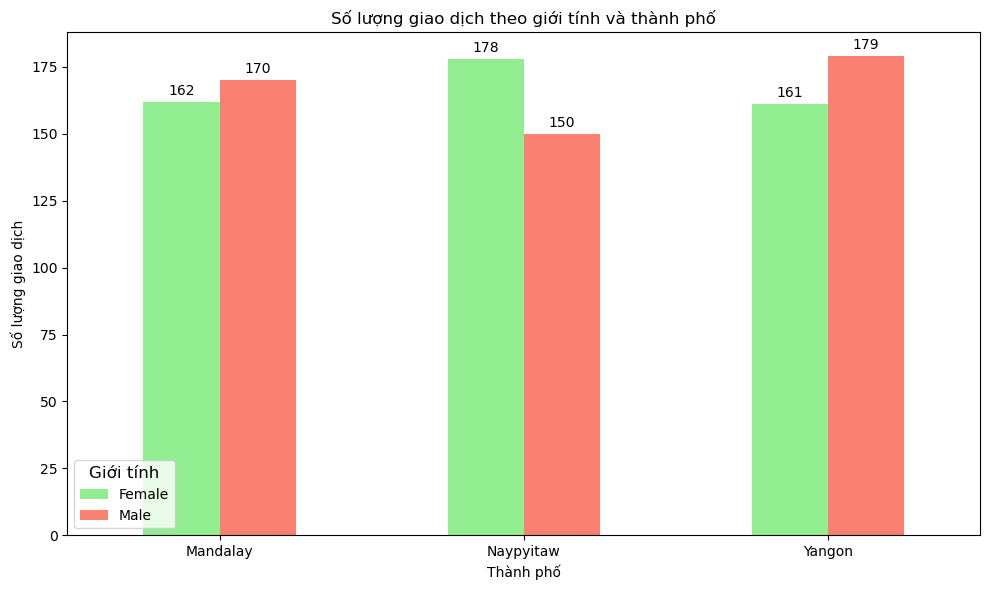

In [59]:
customer_city_counts = supermarket_data_coppy.groupby(
    ['City', 'Gender']
).size().unstack(fill_value=0)

# Vẽ biểu đồ
ax = customer_city_counts.plot(
    kind='bar',
    stacked=False,
    color=['lightgreen', 'salmon'],
    figsize=(10, 6)
)

plt.xlabel('Thành phố')
plt.ylabel('Số lượng giao dịch')
plt.title('Số lượng giao dịch theo giới tính và thành phố')
plt.xticks(rotation=0)
plt.legend(title='Giới tính', title_fontsize=12, fontsize=10)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

## Tỷ lệ khách hàng

In [60]:
# Tỷ lệ khách hàng thành viên và không thành viên trong dữ liệu
customer_type_counts = supermarket_data_coppy['Customer type'].value_counts()
customer_type_percentages = (customer_type_counts / customer_type_counts.sum()) * 100
print("Tỷ lệ khách hàng theo loại:")
for customer_type, percentage in customer_type_percentages.items():
    print(f"- {customer_type}: {percentage:.2f}%")
# Tỷ lệ khách hàng nam và nữ trong dữ liệu
gender_counts = supermarket_data_coppy['Gender'].value_counts() 
gender_percentages = (gender_counts / gender_counts.sum()) * 100
print("\nTỷ lệ khách hàng theo giới tính:")
for gender, percentage  in gender_percentages.items():
    print(f"- {gender}: {percentage:.2f}%")


Tỷ lệ khách hàng theo loại:
- Member: 50.10%
- Normal: 49.90%

Tỷ lệ khách hàng theo giới tính:
- Female: 50.10%
- Male: 49.90%


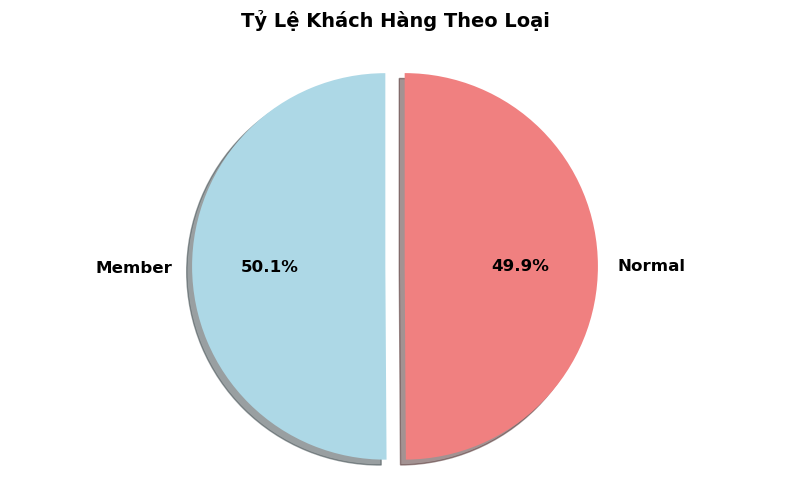

In [61]:
# Biểu đồ tròn cho tỷ lệ khách hàng theo member vs non-member trong dữ liệu
customer_type_counts = supermarket_data_coppy['Customer type'].value_counts()
plt.figure(figsize=(8, 5))
plt.pie(
    customer_type_counts,
    labels=customer_type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightblue', 'lightcoral'],
    shadow=True,
    explode=[0.05, 0.05],
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
plt.title('Tỷ Lệ Khách Hàng Theo Loại', fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

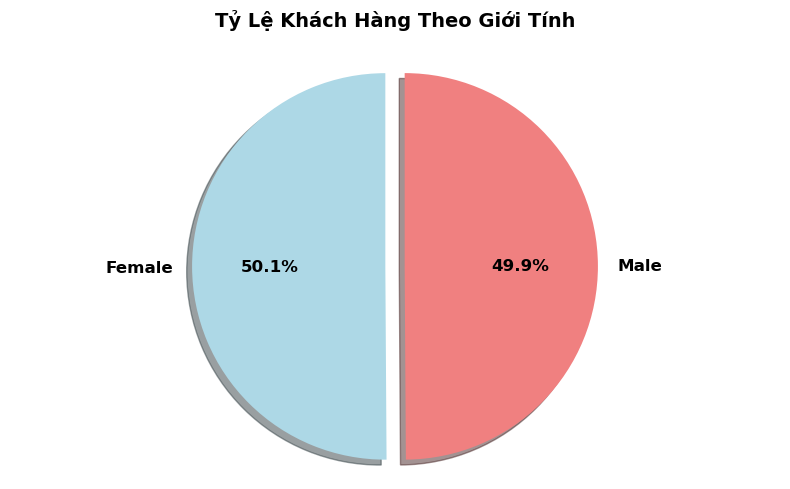

In [62]:
# biểu đồ tròn tỷ lệ khách hàng theo giới tính trong dữ liệu
gender_counts = supermarket_data_coppy['Gender'].value_counts()
plt.figure(figsize=(8, 5))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightblue', 'lightcoral'],
    shadow=True,
    explode=[0.05, 0.05],
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
plt.title('Tỷ Lệ Khách Hàng Theo Giới Tính', fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [63]:
# Tỷ lệ khách hàng thành viên và không thành viên theo thành phố
customer_city_counts = supermarket_data_coppy.groupby(
    ['City', 'Customer type']
).size().unstack(fill_value=0)
customer_city_percentages = customer_city_counts.div(customer_city_counts.sum(axis=1), axis=0) * 100
print("\nTỷ lệ khách hàng theo loại và thành phố:")
for city in customer_city_percentages.index:
    print(f"- Thành phố {city}:")
    for customer_type in customer_city_percentages.columns:
        percentage = customer_city_percentages.loc[city, customer_type]
        print(f"  - {customer_type}: {percentage:.2f}%")


Tỷ lệ khách hàng theo loại và thành phố:
- Thành phố Mandalay:
  - Member: 49.70%
  - Normal: 50.30%
- Thành phố Naypyitaw:
  - Member: 51.52%
  - Normal: 48.48%
- Thành phố Yangon:
  - Member: 49.12%
  - Normal: 50.88%


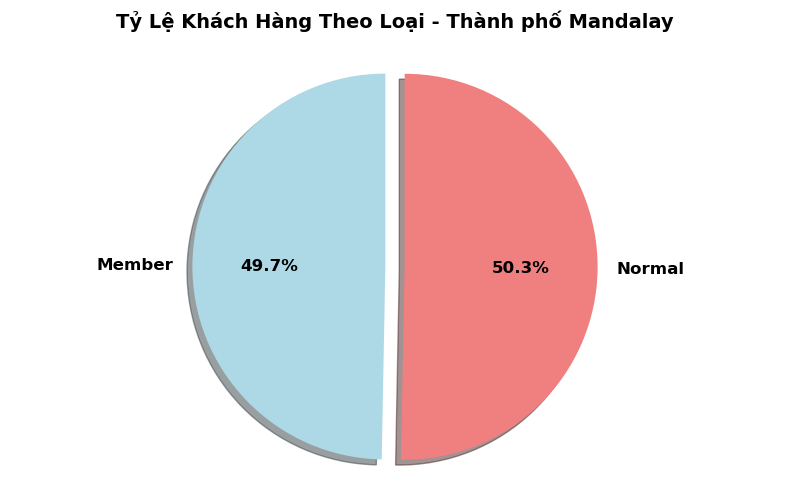

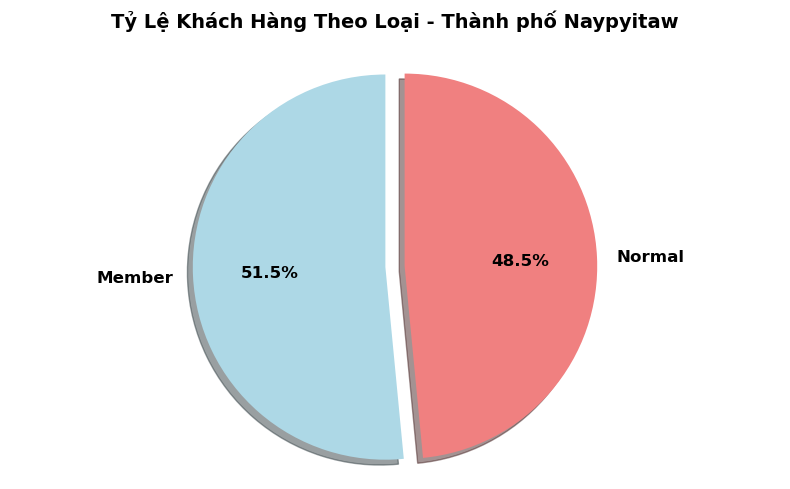

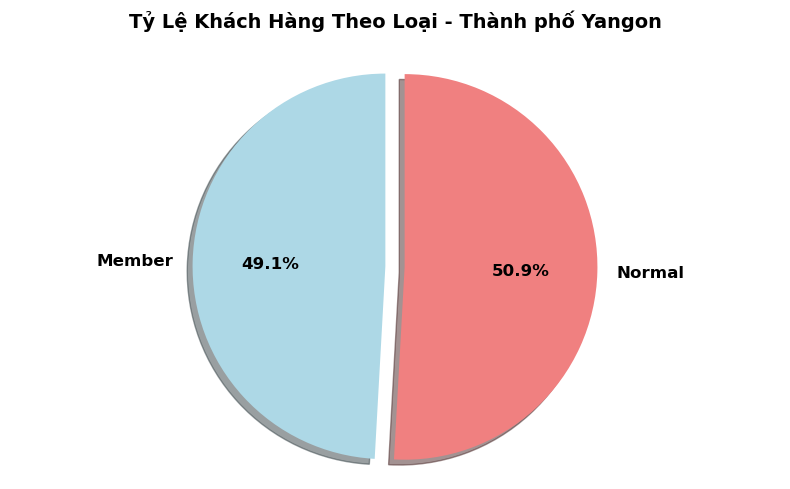

In [64]:
# Biểu đồ tròn cho tỷ lệ khách hàng theo loại và thành phố
customer_city_counts = supermarket_data_coppy.groupby(
    ['City', 'Customer type']
).size().unstack(fill_value=0)
customer_city_percentages = customer_city_counts.div(customer_city_counts.sum(axis=1), axis=0) * 100
for city in customer_city_percentages.index:
    plt.figure(figsize=(8, 5))
    plt.pie(
        customer_city_counts.loc[city],
        labels=customer_city_counts.columns,
        autopct='%1.1f%%',
        startangle=90,
        colors=['lightblue', 'lightcoral'],
        shadow=True,
        explode=[0.05, 0.05],
        textprops={'fontsize': 12, 'fontweight': 'bold'}
    )
    plt.title(f'Tỷ Lệ Khách Hàng Theo Loại - Thành phố {city}', fontsize=14, fontweight='bold', pad=20)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

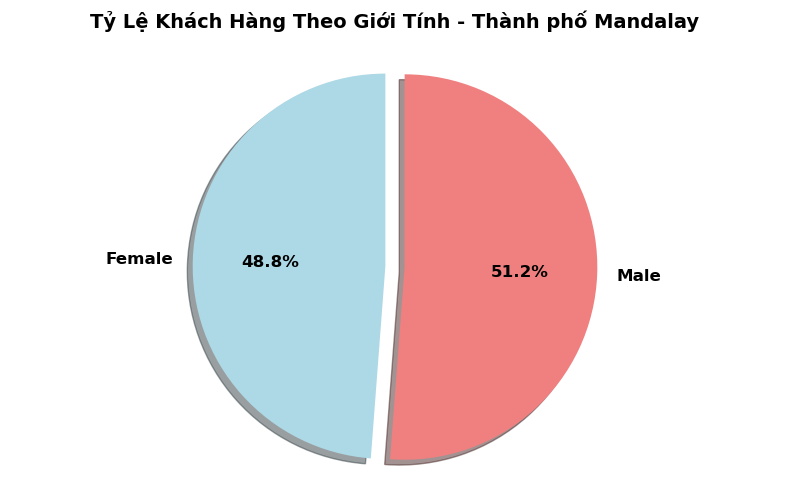

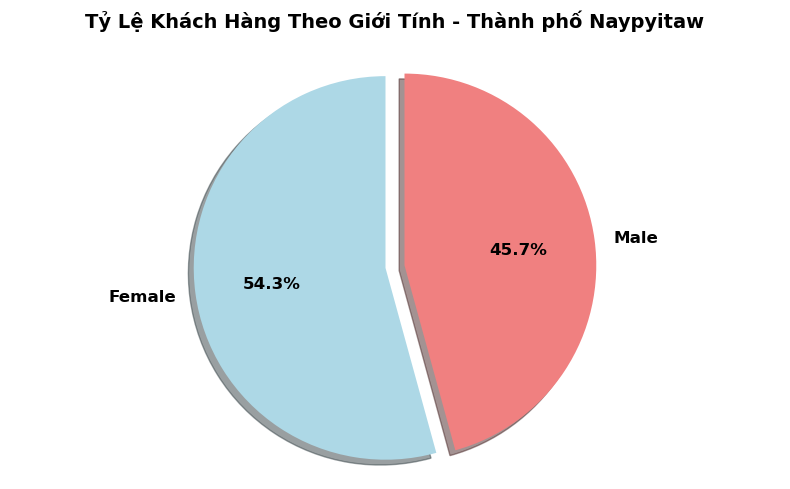

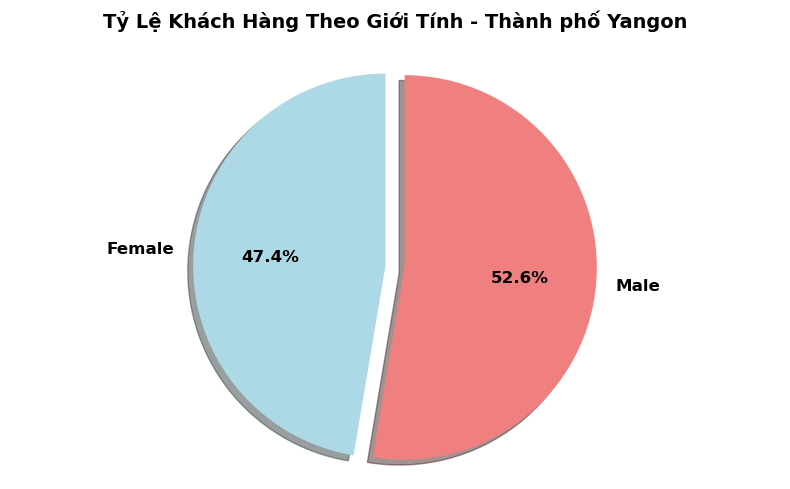

In [65]:
# Biểu đồ tròn thể hiện tỷ lệ khách hàng theo giới tính và thành phố
customer_city_counts = supermarket_data_coppy.groupby(
    ['City', 'Gender']
).size().unstack(fill_value=0)
customer_city_percentages = customer_city_counts.div(customer_city_counts.sum(axis=1), axis=0) * 100
for city in customer_city_percentages.index:
    plt.figure(figsize=(8, 5))
    plt.pie(
        customer_city_counts.loc[city],
        labels=customer_city_counts.columns,
        autopct='%1.1f%%',
        startangle=90,
        colors=['lightblue', 'lightcoral'],
        shadow=True,
        explode=[0.05, 0.05],
        textprops={'fontsize': 12, 'fontweight': 'bold'}
    )
    plt.title(f'Tỷ Lệ Khách Hàng Theo Giới Tính - Thành phố {city}', fontsize=14, fontweight='bold', pad=20)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

## Khách hàng theo giới tính

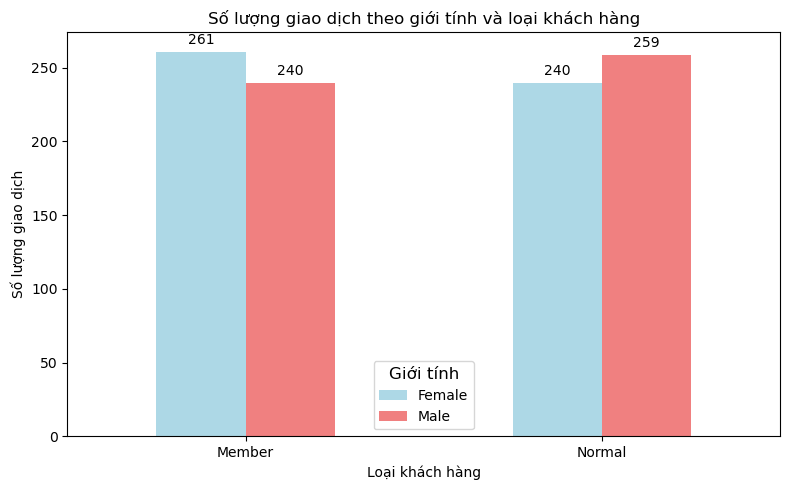

In [66]:
# Biểu đồ cột thể hiện gender theo loại khách hàng
customer_gender_counts = supermarket_data_coppy.groupby(
    ['Customer type', 'Gender']
).size().unstack(fill_value=0)
ax = customer_gender_counts.plot(
    kind='bar',
    stacked=False,
    color=['lightblue', 'lightcoral'],
    figsize=(8, 5)
)
plt.xlabel('Loại khách hàng')
plt.ylabel('Số lượng giao dịch')
plt.title('Số lượng giao dịch theo giới tính và loại khách hàng')
plt.xticks(rotation=0)
plt.legend(title='Giới tính', title_fontsize=12, fontsize=10)
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
plt.show()

## Trong dataset này giới tính chi tiêu như thế nào

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3349021604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=gender_avg_total, x='Gender', y='Total', palette=['lightblue', 'lightcoral'])


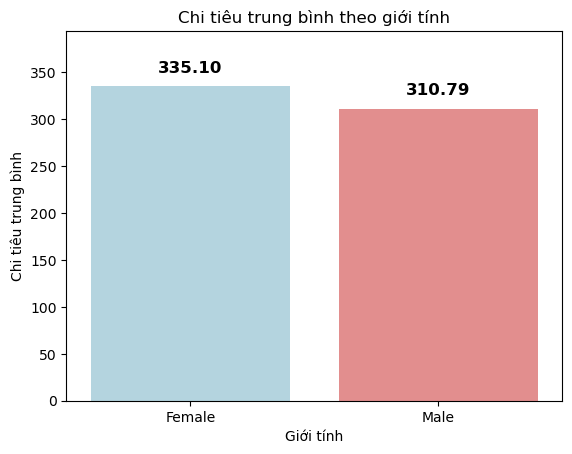

In [67]:
# Giới tính chi tiêu trung bình như thế nào?
gender_avg_total = supermarket_data_coppy.groupby('Gender')['Total'].mean().reset_index()
ax = sns.barplot(data=gender_avg_total, x='Gender', y='Total', palette=['lightblue', 'lightcoral'])
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}', padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Giới tính')
plt.ylabel('Chi tiêu trung bình')
plt.title('Chi tiêu trung bình theo giới tính')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(ticks=range(len(gender_avg_total)), labels= gender_avg_total['Gender'], rotation=0)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3341529155.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=male_product_counts, x='Số lượng', y='Product line', palette='Blues_d')


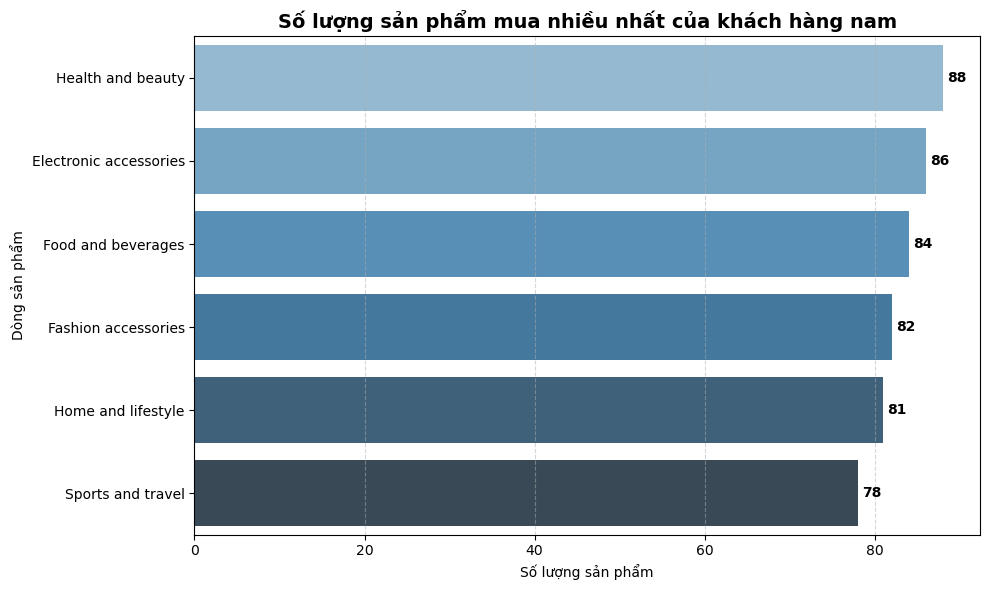

In [68]:
# Biểu đồ cột ngang thể hiện số lượng sản phẩm mà male mua nhiều nhất
male_data = supermarket_data_coppy[supermarket_data_coppy['Gender'] == 'Male']
male_product_counts =   male_data['Product line'].value_counts().reset_index()
male_product_counts.columns = ['Product line', 'Số lượng']
male_product_counts = male_product_counts.sort_values('Số lượng', ascending=False)
plt.figure(figsize=(10, 6)) 
ax = sns.barplot(data=male_product_counts, x='Số lượng', y='Product line', palette='Blues_d')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10, fontweight='bold')    
plt.xlabel('Số lượng sản phẩm')
plt.ylabel('Dòng sản phẩm')
plt.title('Số lượng sản phẩm mua nhiều nhất của khách hàng nam', fontsize=14, fontweight='bold')
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\2922716510.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=female_product_counts, x='Số lượng', y='Product line', palette='Reds_d')


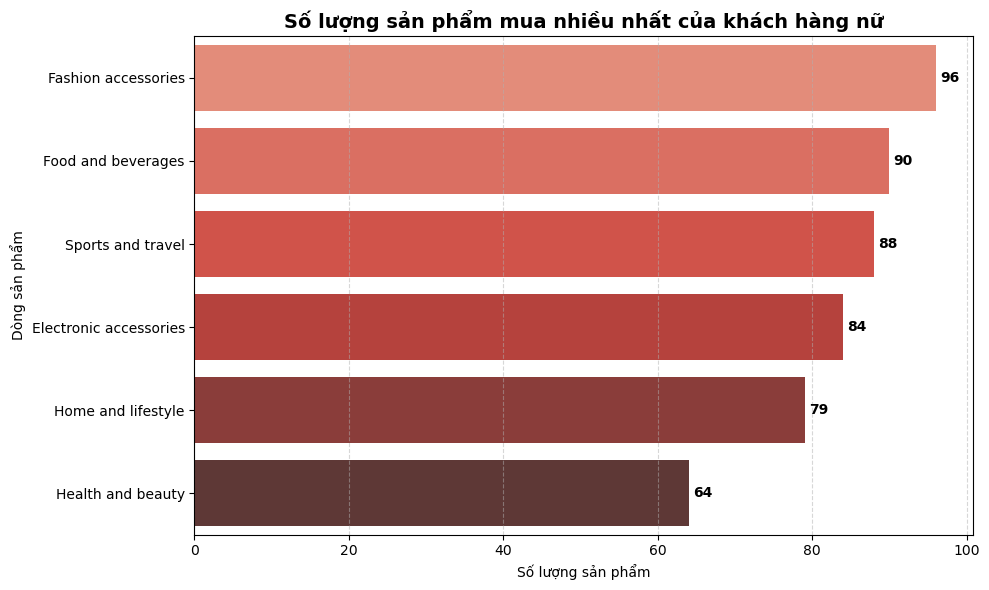

In [69]:
# Biểu đồ cột ngang thể hiện số lượng sản phẩm mà female mua nhiều nhất
female_data = supermarket_data_coppy[supermarket_data_coppy['Gender'] == 'Female']
female_product_counts = female_data['Product line'].value_counts().reset_index()
female_product_counts.columns = ['Product line', 'Số lượng']
female_product_counts = female_product_counts.sort_values('Số lượng', ascending=False)
plt.figure(figsize=(10, 6)) 
ax = sns.barplot(data=female_product_counts, x='Số lượng', y='Product line', palette='Reds_d')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10, fontweight='bold')    
plt.xlabel('Số lượng sản phẩm')
plt.ylabel('Dòng sản phẩm')
plt.title('Số lượng sản phẩm mua nhiều nhất của khách hàng nữ', fontsize=14, fontweight='bold')
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Trong dataset này khách hàng member và normal chi tiêu như thế nào 

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\1921735891.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=customer_type_avg_total, x='Customer type', y='Chi tiêu trung bình', palette=['lightblue', 'lightcoral'])


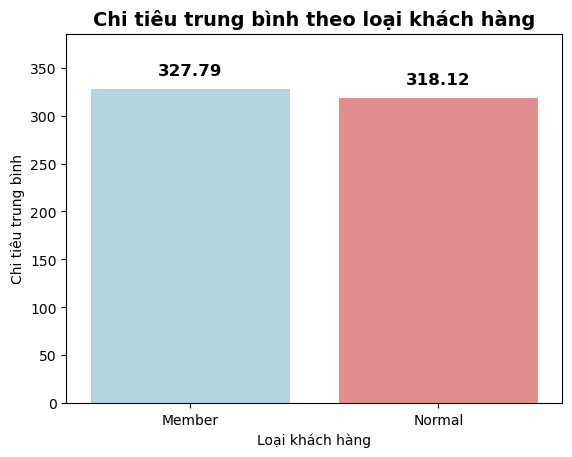

In [70]:
# Loại khách hàng nào chi tiêu nhiều hơn?
customer_type_avg_total = supermarket_data_coppy.groupby('Customer type')['Total'].mean().reset_index()
customer_type_avg_total.columns = ['Customer type', 'Chi tiêu trung bình']
ax = sns.barplot(data=customer_type_avg_total, x='Customer type', y='Chi tiêu trung bình', palette=['lightblue', 'lightcoral'])
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}', padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Loại khách hàng')
plt.ylabel('Chi tiêu trung bình')
plt.title('Chi tiêu trung bình theo loại khách hàng', fontsize=14, fontweight='bold')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(ticks=range(len(customer_type_avg_total)), labels=customer_type_avg_total['Customer type'], rotation=0)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\2669450720.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=member_product_counts, x='Số lượng', y='Product line', palette='Greens_d')


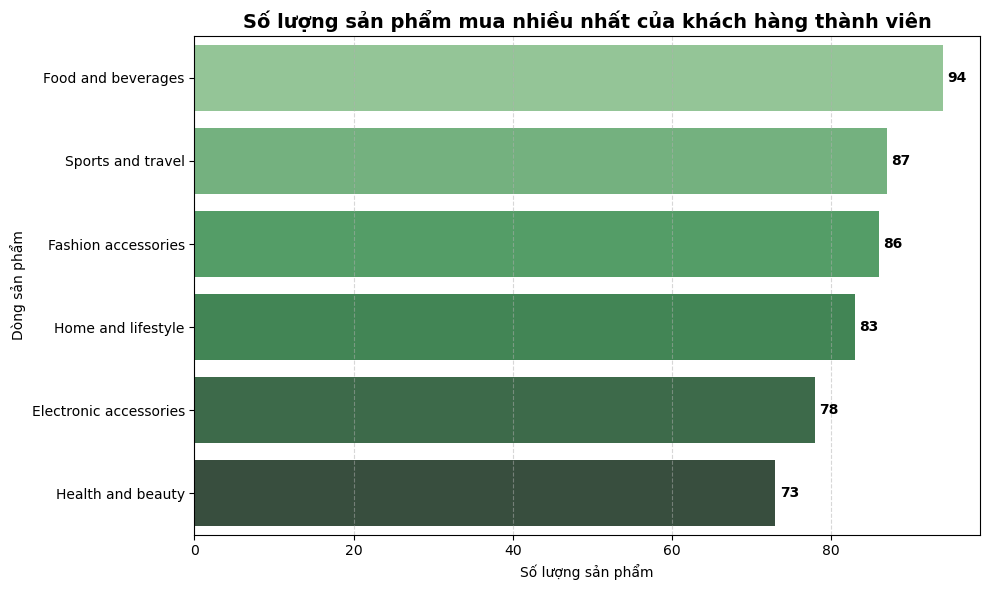

In [71]:
# Biểu đồ cột ngang thể hiện số lượng sản phẩm mà member mua nhiều nhất
member_data = supermarket_data_coppy[supermarket_data_coppy['Customer type'] == 'Member']
member_product_counts = member_data['Product line'].value_counts().reset_index()
member_product_counts.columns = ['Product line', 'Số lượng']
member_product_counts = member_product_counts.sort_values('Số lượng', ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=member_product_counts, x='Số lượng', y='Product line', palette='Greens_d')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10, fontweight='bold')
plt.xlabel('Số lượng sản phẩm')
plt.ylabel('Dòng sản phẩm')
plt.title('Số lượng sản phẩm mua nhiều nhất của khách hàng thành viên', fontsize=14, fontweight='bold')
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\4050836508.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=normal_product_counts, x='Số lượng', y='Product line', palette='Oranges_d')


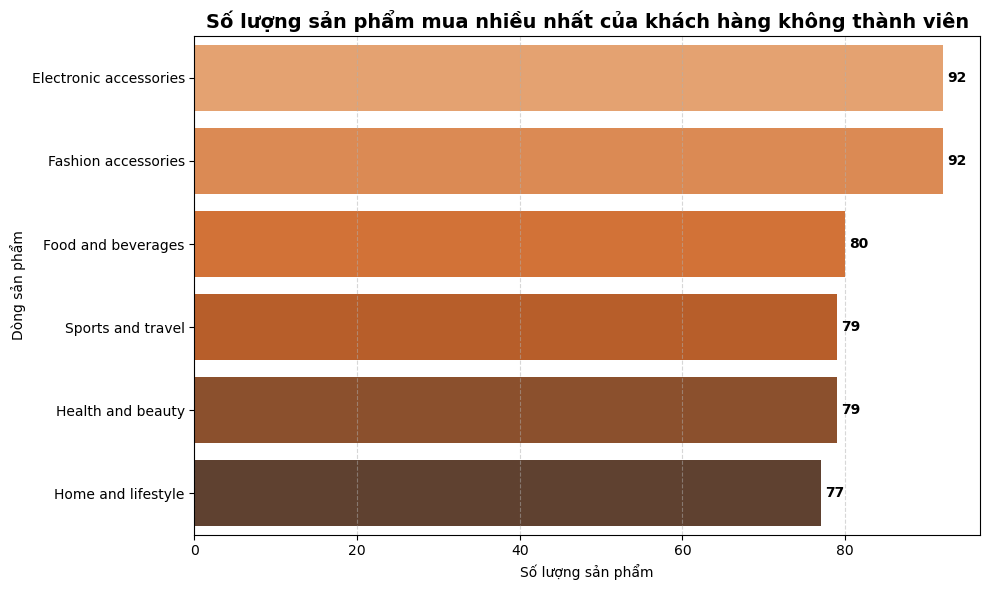

In [72]:
# Biểu đồ cột ngang thể hiện số lượng sản phẩm mà normal mua nhiều nhất
normal_data = supermarket_data_coppy[supermarket_data_coppy['Customer type'] == 'Normal']
normal_product_counts = normal_data['Product line'].value_counts().reset_index()
normal_product_counts.columns = ['Product line', 'Số lượng']
normal_product_counts = normal_product_counts.sort_values('Số lượng', ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=normal_product_counts, x='Số lượng', y='Product line', palette='Oranges_d')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10, fontweight='bold')
plt.xlabel('Số lượng sản phẩm')
plt.ylabel('Dòng sản phẩm')
plt.title('Số lượng sản phẩm mua nhiều nhất của khách hàng không thành viên', fontsize=14, fontweight='bold')
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Phân tích hành vi khách hàng theo thành phố/ Chi nhánh 

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\2305574496.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=member_city_counts, x='City', y='Số lượng thành viên', palette='Blues_d')


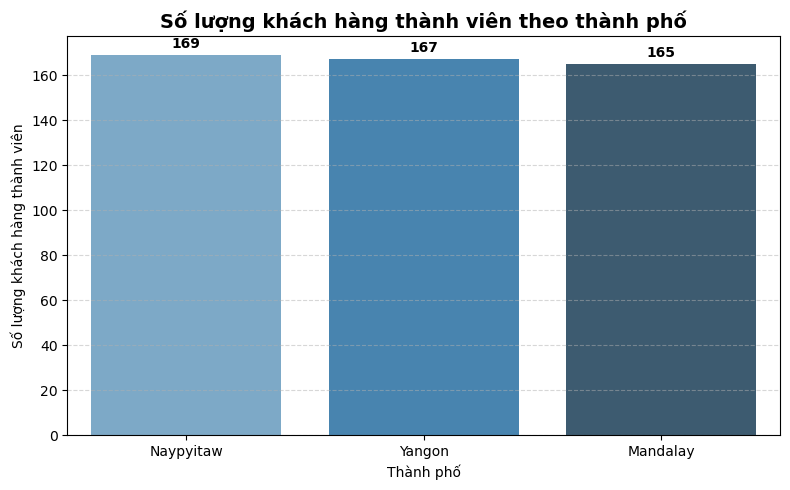

In [73]:
# Thành phố nào có nhiều khách hàng thành viên nhất?
member_city_counts = supermarket_data_coppy[supermarket_data_coppy['Customer type'] == 'Member']['City'].value_counts().reset_index()
member_city_counts.columns = ['City', 'Số lượng thành viên']
member_city_counts = member_city_counts.sort_values('Số lượng thành viên', ascending=False)
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=member_city_counts, x='City', y='Số lượng thành viên', palette='Blues_d')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10, fontweight='bold')
plt.xlabel('Thành phố')
plt.ylabel('Số lượng khách hàng thành viên')
plt.title('Số lượng khách hàng thành viên theo thành phố', fontsize=14, fontweight='bold')
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\325273229.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=normal_city_counts, x='City', y='Số lượng không thành viên', palette='Oranges_d')


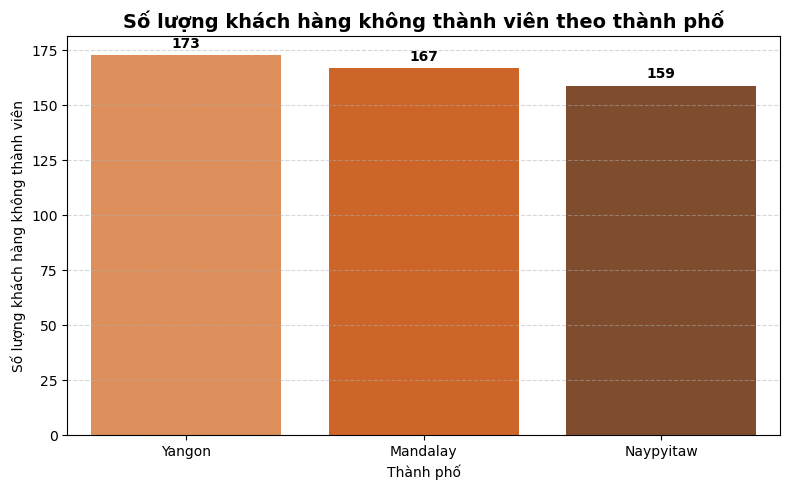

In [74]:
# Số lượng khách hàng không thành viên theo thành phố
normal_city_counts = supermarket_data_coppy[supermarket_data_coppy['Customer type'] =='Normal']['City'].value_counts().reset_index()
normal_city_counts.columns = ['City', 'Số lượng không thành viên']  
normal_city_counts = normal_city_counts.sort_values('Số lượng không thành viên', ascending=False)
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=normal_city_counts, x='City', y='Số lượng không thành viên', palette='Oranges_d')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10, fontweight='bold')
plt.xlabel('Thành phố')
plt.ylabel('Số lượng khách hàng không thành viên')
plt.title('Số lượng khách hàng không thành viên theo thành phố', fontsize=14, fontweight='bold')
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Phân tích loại khách hàng theo từng thành phố 

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\1794648781.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=yangon_customer_type_counts, x='Customer type', y='Số lượng', palette=['lightblue', 'lightcoral'])


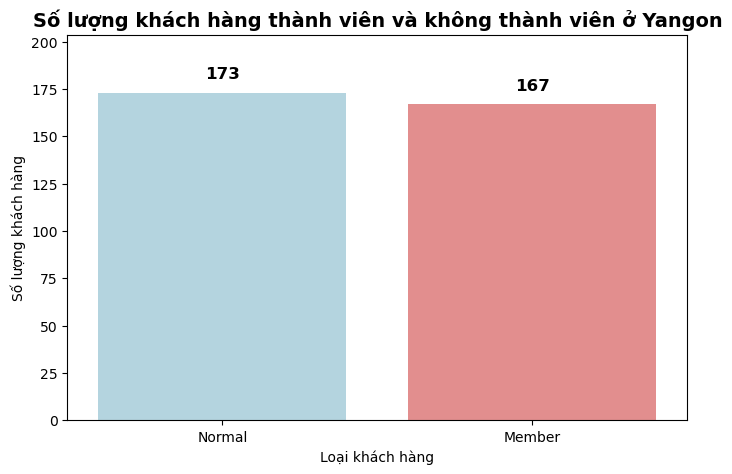

In [75]:
# Thành phố Yangon có bao nhiêu khách hàng là thành viên và không thành viên?
yangon_data = supermarket_data_coppy[supermarket_data_coppy['City'] == 'Yangon']
yangon_customer_type_counts = yangon_data['Customer type'].value_counts().reset_index()
yangon_customer_type_counts.columns = ['Customer type', 'Số lượng']
yangon_customer_type_counts = yangon_customer_type_counts.sort_values('Số lượng', ascending=False)
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=yangon_customer_type_counts, x='Customer type', y='Số lượng', palette=['lightblue', 'lightcoral'])
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Loại khách hàng')
plt.ylabel('Số lượng khách hàng')
plt.title('Số lượng khách hàng thành viên và không thành viên ở Yangon', fontsize=14, fontweight='bold')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(ticks=range(len(yangon_customer_type_counts)), labels=yangon_customer_type_counts['Customer type'], rotation=0)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\685440293.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=mandalay_customer_type_counts, x='Customer type', y='Số lượng', palette=['lightblue', 'lightcoral'])


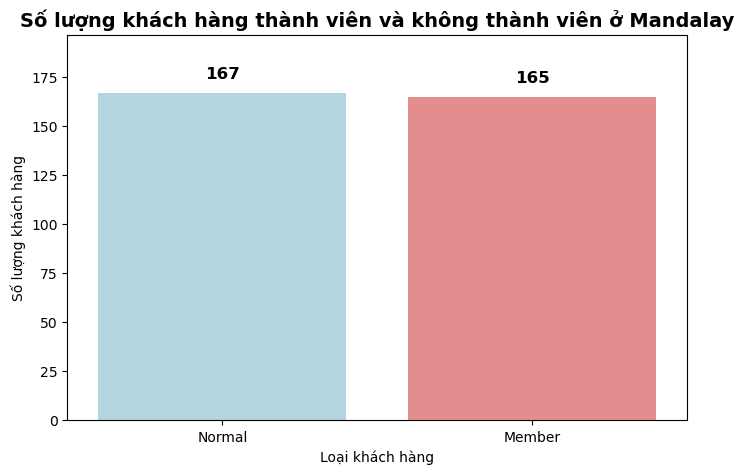

In [76]:
# Thành phố Mandalay có bao nhiêu khách hàng là thành viên và không thành viên?
mandalay_data = supermarket_data_coppy[supermarket_data_coppy['City'] == 'Mandalay']
mandalay_customer_type_counts = mandalay_data['Customer type'].value_counts().reset_index()
mandalay_customer_type_counts.columns = ['Customer type', 'Số lượng']
mandalay_customer_type_counts = mandalay_customer_type_counts.sort_values('Số lượng', ascending=False)
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=mandalay_customer_type_counts, x='Customer type', y='Số lượng', palette=['lightblue', 'lightcoral'])
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Loại khách hàng')
plt.ylabel('Số lượng khách hàng')
plt.title('Số lượng khách hàng thành viên và không thành viên ở Mandalay', fontsize=14, fontweight='bold')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(ticks=range(len(mandalay_customer_type_counts)), labels=mandalay_customer_type_counts['Customer type'], rotation=0)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\1563874611.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=naypyitaw_customer_type_counts, x='Customer type', y='Số lượng', palette=['lightblue', 'lightcoral'])


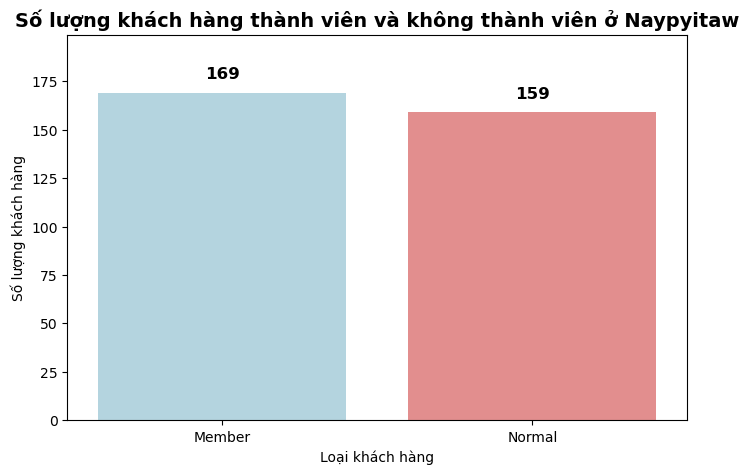

In [77]:
# thành phố Naypyitaw có bao nhiêu khách hàng là thành viên và không thành viên?
naypyitaw_data = supermarket_data_coppy[supermarket_data_coppy['City'] == 'Naypyitaw']
naypyitaw_customer_type_counts = naypyitaw_data['Customer type'].value_counts().reset_index()
naypyitaw_customer_type_counts.columns = ['Customer type', 'Số lượng']
naypyitaw_customer_type_counts = naypyitaw_customer_type_counts.sort_values('Số lượng', ascending=False)
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=naypyitaw_customer_type_counts, x='Customer type', y='Số lượng', palette=['lightblue', 'lightcoral'])
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Loại khách hàng')
plt.ylabel('Số lượng khách hàng')
plt.title('Số lượng khách hàng thành viên và không thành viên ở Naypyitaw', fontsize=14, fontweight='bold')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(ticks=range(len(naypyitaw_customer_type_counts)), labels=naypyitaw_customer_type_counts['Customer type'], rotation=0)
plt.show()

## Phân tích giới tính khách hàng theo từng thành phố 

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\2120143746.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=yangon_gender_counts, x='Gender', y='Số lượng', palette=['lightblue', 'lightcoral'])


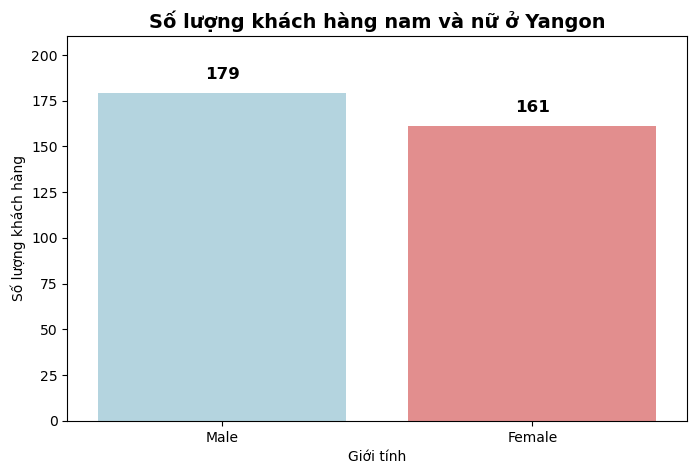

In [78]:
# Thành phố Yangon có bao nhiêu khách hàng là Male và Female?
yangon_data = supermarket_data_coppy[supermarket_data_coppy['City'] == 'Yangon']
yangon_gender_counts = yangon_data['Gender'].value_counts().reset_index()
yangon_gender_counts.columns = ['Gender', 'Số lượng']
yangon_gender_counts = yangon_gender_counts.sort_values('Số lượng', ascending=False)
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=yangon_gender_counts, x='Gender', y='Số lượng', palette=['lightblue', 'lightcoral'])
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng khách hàng')
plt.title('Số lượng khách hàng nam và nữ ở Yangon', fontsize=14, fontweight='bold')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(ticks=range(len(yangon_gender_counts)), labels=yangon_gender_counts['Gender'], rotation=0)
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\2568771107.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=mandalay_gender_counts, x='Gender', y='Số lượng', palette=['lightblue', 'lightcoral'])


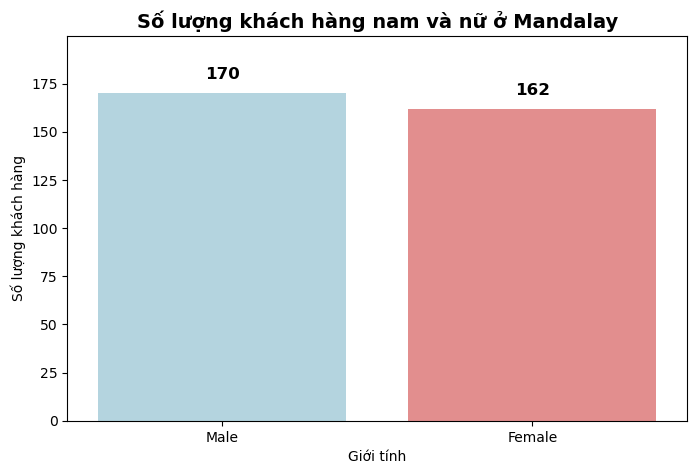

In [79]:
# Thành phố Madalay có bao nhiêu khách hàng là Male và Female?
mandalay_data = supermarket_data_coppy[supermarket_data_coppy['City'] == 'Mandalay']
mandalay_gender_counts = mandalay_data['Gender'].value_counts().reset_index()
mandalay_gender_counts.columns = ['Gender', 'Số lượng']
mandalay_gender_counts = mandalay_gender_counts.sort_values('Số lượng', ascending=False)
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=mandalay_gender_counts, x='Gender', y='Số lượng', palette=['lightblue', 'lightcoral'])
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng khách hàng')
plt.title('Số lượng khách hàng nam và nữ ở Mandalay', fontsize=14, fontweight='bold')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(ticks=range(len(mandalay_gender_counts)), labels=mandalay_gender_counts['Gender'], rotation=0)
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\396520772.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=napyitaw_gender_counts, x='Gender', y='Số lượng', palette=['lightblue', 'lightcoral'])


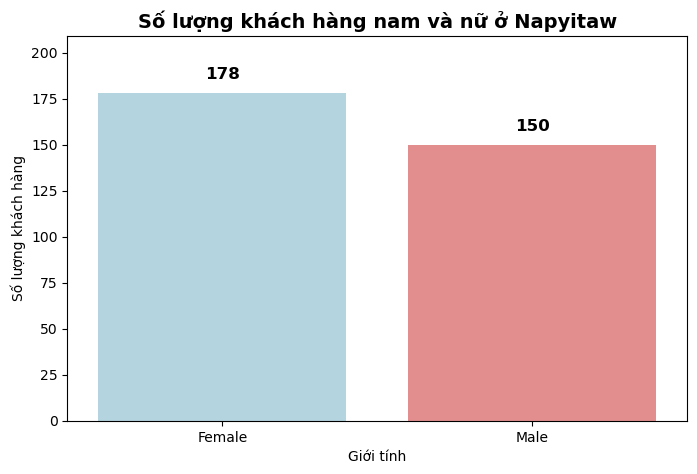

In [80]:
# Thành phố Napyitaw có bao nhiêu khách hàng là Male và Female?
napyitaw_data = supermarket_data_coppy[supermarket_data_coppy['City'] == 'Naypyitaw']
napyitaw_gender_counts = napyitaw_data['Gender'].value_counts().reset_index()
napyitaw_gender_counts.columns = ['Gender', 'Số lượng']
napyitaw_gender_counts = napyitaw_gender_counts.sort_values('Số lượng', ascending=False)
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=napyitaw_gender_counts, x='Gender', y='Số lượng', palette=['lightblue', 'lightcoral'])
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng khách hàng')
plt.title('Số lượng khách hàng nam và nữ ở Napyitaw', fontsize=14, fontweight='bold')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(ticks=range(len(napyitaw_gender_counts)), labels=napyitaw_gender_counts['Gender'], rotation=0)
plt.show()


# Chi tiêu của khách hàng theo thành phố/ chi nhánh

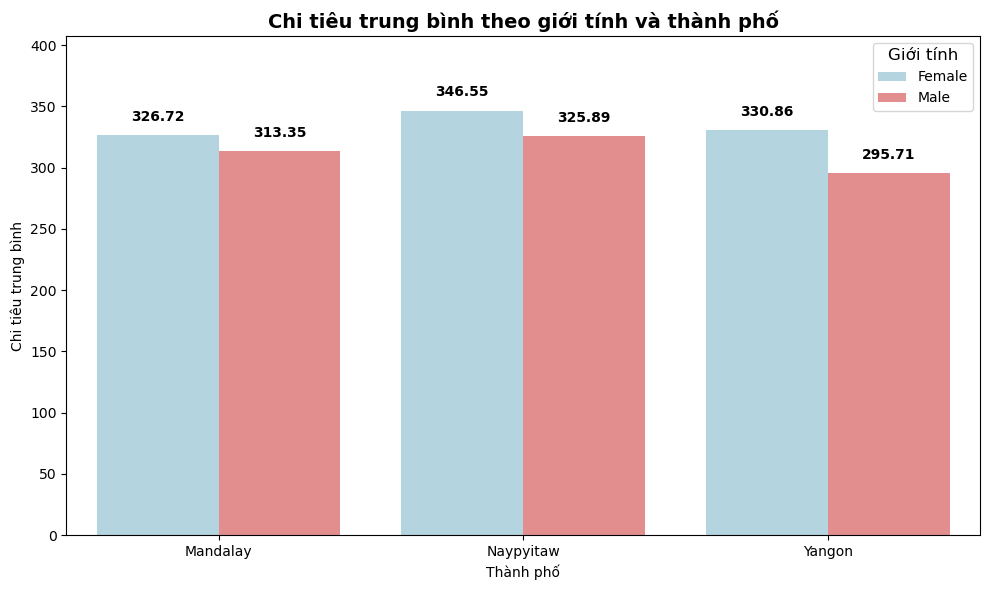

In [81]:
    # Chi tiêu trung bình của khách hàng male và female theo từng thành phố
city_gender_avg_total = supermarket_data_coppy.groupby(['City', 'Gender'])['Total'].mean().reset_index()
city_gender_avg_total.columns = ['City', 'Gender', 'Chi tiêu trung bình']
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=city_gender_avg_total, x='City', y='Chi tiêu trung bình', hue='Gender', palette=['lightblue', 'lightcoral'])
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}', padding=8, fontsize=10, fontweight='bold')
plt.xlabel('Thành phố')
plt.ylabel('Chi tiêu trung bình')
plt.title('Chi tiêu trung bình theo giới tính và thành phố', fontsize=14, fontweight='bold')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(rotation=0)
plt.legend(title='Giới tính', title_fontsize=12, fontsize=10)
plt.tight_layout()
plt.show()

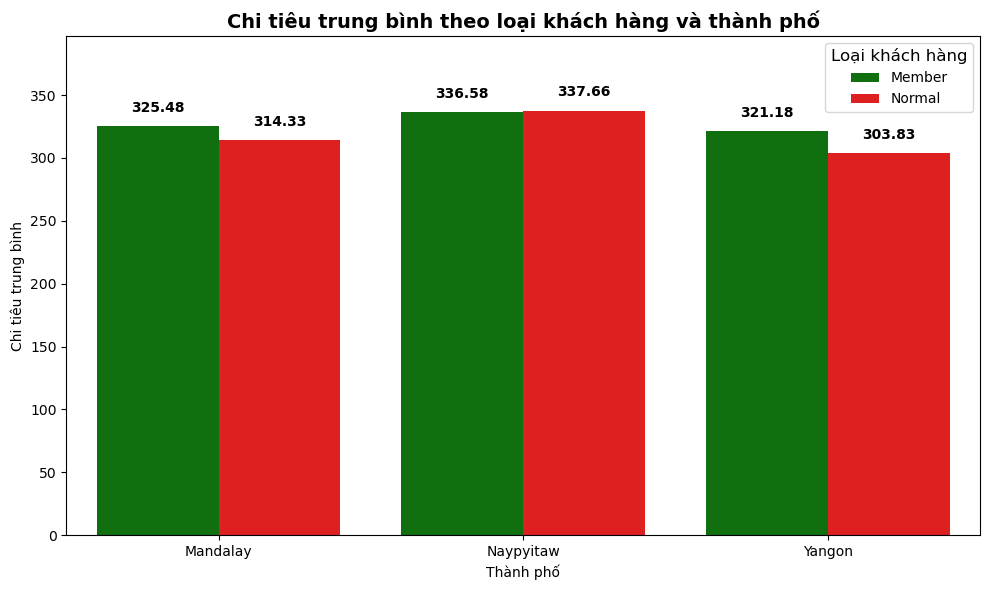

In [82]:
# Chi tiêu trung bình của khách hàng member và non-member theo từng thành phố
city_member_avg_total = supermarket_data_coppy.groupby(['City', 'Customer type'])['Total'].mean().reset_index()
city_member_avg_total.columns = ['City', 'Customer_type', 'Chi tiêu trung bình']
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=city_member_avg_total, x='City', y='Chi tiêu trung bình', hue='Customer_type', palette=['Green', 'red'])
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}', padding=8, fontsize=10, fontweight='bold')
plt.xlabel('Thành phố')
plt.ylabel('Chi tiêu trung bình')
plt.title('Chi tiêu trung bình theo loại khách hàng và thành phố', fontsize=14, fontweight='bold')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(rotation=0)
plt.legend(title='Loại khách hàng', title_fontsize=12, fontsize=10)
plt.tight_layout()
plt.show()

### Chi tiêu của khách hàng nam

In [83]:
# khách hàng nam là thành viên hay không thành viên chi tiêu nhiều hơn?
male_member_avg_total = supermarket_data_coppy[(supermarket_data_coppy['Gender'] == 'Male') & (supermarket_data_coppy['Customer type'] == 'Member')]['Total'].mean()
male_normal_avg_total = supermarket_data_coppy[(supermarket_data_coppy['Gender'] == 'Male') & (supermarket_data_coppy['Customer type'] == 'Normal')]['Total'].mean()
print(f"Chi tiêu trung bình của khách hàng nam thành viên: {male_member_avg_total:,.2f}")
print(f"Chi tiêu trung bình của khách hàng nam không thành  viên: {male_normal_avg_total:,.2f}")

Chi tiêu trung bình của khách hàng nam thành viên: 316.99
Chi tiêu trung bình của khách hàng nam không thành  viên: 305.05


C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\611145185.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=male_member_normal_avg_total, x='Customer type', y='Chi tiêu trung bình', palette=['lightblue', 'lightcoral'])


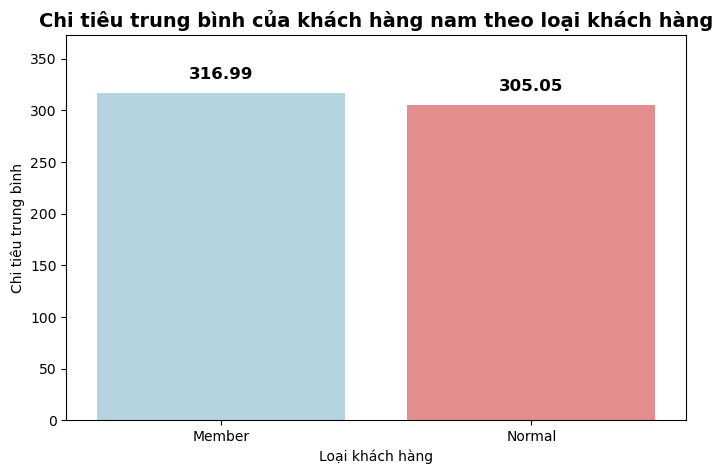

In [84]:
# Biểu đồ cột thể hiện khách hàng nam là thành viên hay không thành viên chi tiêu nhiều hơn
male_member_normal_avg_total = pd.DataFrame({
    'Customer type': ['Member', 'Normal'],
    'Chi tiêu trung bình': [male_member_avg_total, male_normal_avg_total]
})
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=male_member_normal_avg_total, x='Customer type', y='Chi tiêu trung bình', palette=['lightblue', 'lightcoral'])
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}', padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Loại khách hàng')
plt.ylabel('Chi tiêu trung bình')
plt.title('Chi tiêu trung bình của khách hàng nam theo loại khách hàng', fontsize=14, fontweight='bold')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(ticks=range(len(male_member_normal_avg_total)), labels=male_member_normal_avg_total['Customer type'], rotation=0)
plt.show()

In [85]:
# khách hàng nữ là thành viên hay không thành viên chi tiêu nhiều hơn?
female_member_avg_total = supermarket_data_coppy[(supermarket_data_coppy['Gender'] == 'Female') & (supermarket_data_coppy['Customer type'] == 'Member')]['Total'].mean()
female_normal_avg_total = supermarket_data_coppy[(supermarket_data_coppy['Gender'] == 'Female') & (supermarket_data_coppy['Customer type'] == 'Normal')]['Total'].mean()
print(f"Chi tiêu trung bình của khách hàng nữ thành viên: {female_member_avg_total:,.2f}")
print(f"Chi tiêu trung bình của khách hàng nữ không thành  viên: {female_normal_avg_total:,.2f}")

Chi tiêu trung bình của khách hàng nữ thành viên: 337.73
Chi tiêu trung bình của khách hàng nữ không thành  viên: 332.23


C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3860836974.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=female_member_normal_avg_total, x='Customer type', y='Chi tiêu trung bình', palette=['lightblue', 'lightcoral'])


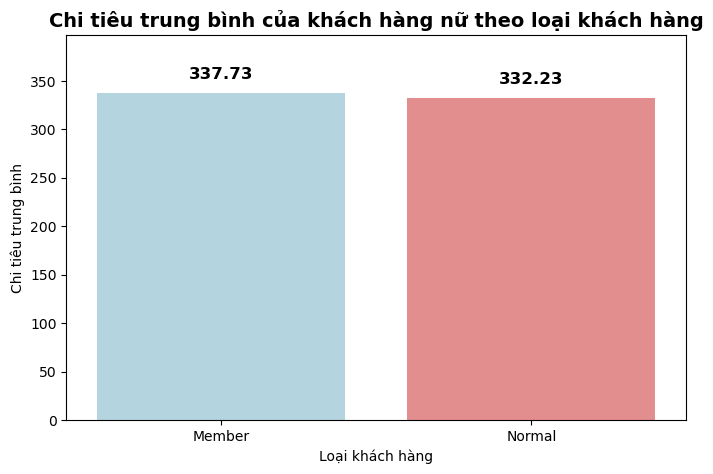

In [86]:
# Biểu đồ cột thể hiện khách hàng nữ là thành viên hay không thành viên chi tiêu nhiều hơn
female_member_normal_avg_total = pd.DataFrame({
    'Customer type': ['Member', 'Normal'],
    'Chi tiêu trung bình': [female_member_avg_total, female_normal_avg_total]
})
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=female_member_normal_avg_total, x='Customer type', y='Chi tiêu trung bình', palette=['lightblue', 'lightcoral'])
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}', padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Loại khách hàng')
plt.ylabel('Chi tiêu trung bình')
plt.title('Chi tiêu trung bình của khách hàng nữ theo loại khách hàng', fontsize=14, fontweight='bold')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(ticks=range(len(female_member_normal_avg_total)), labels=female_member_normal_avg_total['Customer type'], rotation=0)
plt.show()

### chi tiêu của khách hàng nam và nữ là member và normal như thế nào 

In [87]:
# Thành phố Yangon khách hàng nam thành viên chi tiêu nhiều hơn hay khách hàng nam không thành viên chi tiêu nhiều hơn?
yangon_male_member_avg_total = supermarket_data_coppy[(supermarket_data_coppy['City'] == 'Yangon') & (supermarket_data_coppy['Gender'] == 'Male') & (supermarket_data_coppy['Customer type'] == 'Member')]['Total'].mean()
yangon_male_normal_avg_total = supermarket_data_coppy[(supermarket_data_coppy['City'] == 'Yangon') & (supermarket_data_coppy['Gender'] == 'Male') & (supermarket_data_coppy['Customer type'] == 'Normal')]['Total'].mean()
print(f"Chi tiêu trung bình của khách hàng nam thành viên ở Yangon: {yangon_male_member_avg_total:,.2f}")
print(f"Chi tiêu trung bình của khách hàng nam không thành viên ở Yangon: {yangon_male_normal_avg_total:,.2f}")

Chi tiêu trung bình của khách hàng nam thành viên ở Yangon: 310.28
Chi tiêu trung bình của khách hàng nam không thành viên ở Yangon: 281.92


C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3275026228.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=yangon_male_member_normal_avg_total, x='Customer type', y='Chi tiêu trung bình', palette=['lightblue', 'lightcoral'])


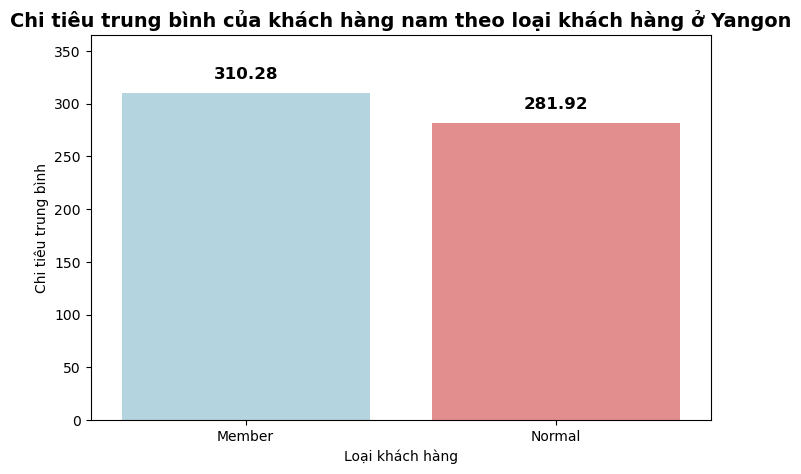

In [88]:
# biểu đồ cột thể hiện khách hàng nam thành viên và không thành viên chi tiêu nhiều hơn ở Yangon    
yangon_male_member_normal_avg_total = pd.DataFrame({
    'Customer type': ['Member', 'Normal'],
    'Chi tiêu trung bình': [yangon_male_member_avg_total, yangon_male_normal_avg_total]
})
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=yangon_male_member_normal_avg_total, x='Customer type', y='Chi tiêu trung bình', palette=['lightblue', 'lightcoral'])
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}', padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Loại khách hàng')
plt.ylabel('Chi tiêu trung bình')
plt.title('Chi tiêu trung bình của khách hàng nam theo loại khách hàng ở Yangon', fontsize=14, fontweight='bold')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(ticks=range(len(yangon_male_member_normal_avg_total)), labels=yangon_male_member_normal_avg_total['Customer type'], rotation=0)
plt.show()

In [89]:
# Thành phố mandalay khách hàng nam thành viên chi tiêu nhiều hơn hay khách hàng nam không thành viên chi tiêu nhiều hơn?
mandaly_male_member_avg_total = supermarket_data_coppy[(supermarket_data_coppy['City'] == 'Mandalay') & (supermarket_data_coppy['Gender'] == 'Male') & (supermarket_data_coppy['Customer type'] == 'Member')]['Total'].mean()
mandaly_male_normal_avg_total = supermarket_data_coppy[(supermarket_data_coppy['City'] == 'Mandalay') & (supermarket_data_coppy['Gender'] == 'Male') & (supermarket_data_coppy['Customer type'] == 'Normal')]['Total'].mean()
print(f"Chi tiêu trung bình của khách hàng nam thành viên ở Mandalay: {mandaly_male_member_avg_total:,.2f}")
print(f"Chi tiêu trung bình của khách hàng nam không thành viên ở Mandalay: {mandaly_male_normal_avg_total:,.2f}")

Chi tiêu trung bình của khách hàng nam thành viên ở Mandalay: 335.68
Chi tiêu trung bình của khách hàng nam không thành viên ở Mandalay: 293.50


C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\1735719926.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=mandalay_male_member_normal_avg_total, x='Customer type', y='Chi tiêu trung bình', palette=['lightblue', 'lightcoral'])


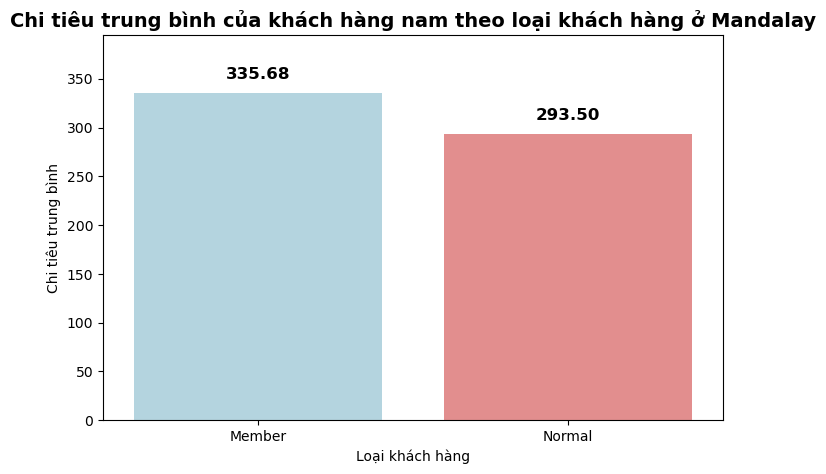

In [90]:
# biểu đồ cột thể hiện khách hàng nam thành viên và không thành viên chi tiêu nhiều hơn ở Mandalay
mandalay_male_member_normal_avg_total = pd.DataFrame({
    'Customer type': ['Member', 'Normal'],
    'Chi tiêu trung bình': [mandaly_male_member_avg_total, mandaly_male_normal_avg_total]
})
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=mandalay_male_member_normal_avg_total, x='Customer type', y='Chi tiêu trung bình', palette=['lightblue', 'lightcoral'])
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}', padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Loại khách hàng')
plt.ylabel('Chi tiêu trung bình')
plt.title('Chi tiêu trung bình của khách hàng nam theo loại khách hàng ở Mandalay', fontsize=14, fontweight='bold')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(ticks=range(len(mandalay_male_member_normal_avg_total)), labels=mandalay_male_member_normal_avg_total['Customer type'], rotation=0)
plt.show()

In [91]:
# Thành phố Naypyitaw khách hàng nam thành viên chi tiêu nhiều hơn hay khách hàng nam không thành viên chi tiêu nhiều hơn?
naypyitaw_male_member_avg_total = supermarket_data_coppy[(supermarket_data_coppy['City'] == 'Naypyitaw') & (supermarket_data_coppy['Gender'] == 'Male') & (supermarket_data_coppy['Customer type'] == 'Member')]['Total'].mean()
naypyitaw_male_normal_avg_total = supermarket_data_coppy[(supermarket_data_coppy['City'] == 'Naypyitaw') & (supermarket_data_coppy['Gender'] == 'Male') & (supermarket_data_coppy['Customer type'] == 'Normal')]['Total'].mean()
print(f"Chi tiêu trung bình của khách hàng nam thành viên ở Naypyitaw: {naypyitaw_male_member_avg_total:,.2f}")
print(f"Chi tiêu trung bình của khách hàng nam không thành viên ở Naypyitaw: {naypyitaw_male_normal_avg_total:,.2f}")

Chi tiêu trung bình của khách hàng nam thành viên ở Naypyitaw: 304.49
Chi tiêu trung bình của khách hàng nam không thành viên ở Naypyitaw: 346.17


C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\2886810013.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=naypyitaw_male_member_normal_avg_total, x='Customer type', y='Chi tiêu trung bình', palette=['lightblue', 'lightcoral'])


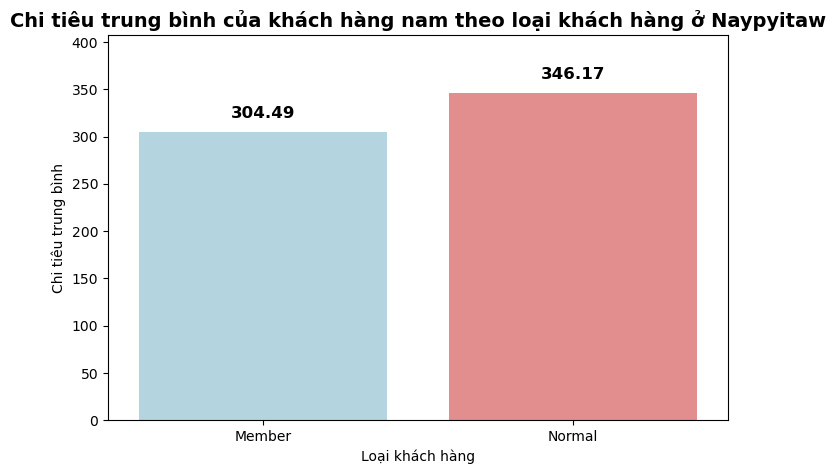

In [92]:
# biểu đồ cột thể hiện khách hàng nam thành viên và không thành viên chi tiêu nhiều hơn ở Naypyitaw
naypyitaw_male_member_normal_avg_total = pd.DataFrame({
    'Customer type': ['Member', 'Normal'],
    'Chi tiêu trung bình': [naypyitaw_male_member_avg_total, naypyitaw_male_normal_avg_total]
})
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=naypyitaw_male_member_normal_avg_total, x='Customer type', y='Chi tiêu trung bình', palette=['lightblue', 'lightcoral'])
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}', padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Loại khách hàng')
plt.ylabel('Chi tiêu trung bình')
plt.title('Chi tiêu trung bình của khách hàng nam theo loại khách hàng ở Naypyitaw', fontsize=14, fontweight='bold')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(ticks=range(len(naypyitaw_male_member_normal_avg_total)), labels=naypyitaw_male_member_normal_avg_total['Customer type'], rotation=0)
plt.show()

In [93]:
# Thành phố yangon khách hàng nữ thành viên chi tiêu nhiều hơn hay khách hàng nam không thành viên chi tiêu nhiều hơn?
yangon_female_member_avg_total = supermarket_data_coppy[(supermarket_data_coppy['City'] == 'Yangon') & (supermarket_data_coppy['Gender'] == 'Female') & (supermarket_data_coppy['Customer type'] == 'Member')]['Total'].mean()
yangon_male_normal_avg_total = supermarket_data_coppy[(supermarket_data_coppy['City'] == 'Yangon') & (supermarket_data_coppy['Gender'] == 'Male') & (supermarket_data_coppy['Customer type'] == 'Normal')]['Total'].mean()
print(f"Chi tiêu trung bình của khách hàng nữ thành viên ở Yangon: {yangon_female_member_avg_total:,.2f}")
print(f"Chi tiêu trung bình của khách hàng nam không thành viên ở Yangon: {yangon_male_normal_avg_total:,.2f}")

Chi tiêu trung bình của khách hàng nữ thành viên ở Yangon: 333.04
Chi tiêu trung bình của khách hàng nam không thành viên ở Yangon: 281.92


C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\460063035.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=yangon_female_member_normal_avg_total, x='Customer type', y='Chi tiêu trung bình', palette=['lightblue', 'lightcoral'])


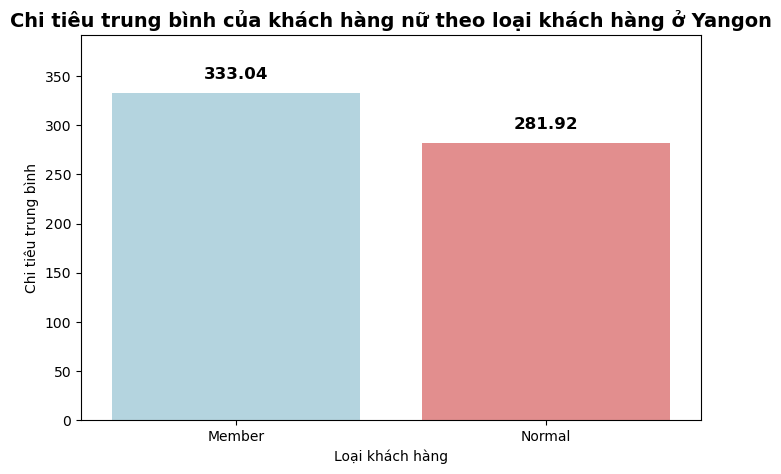

In [94]:
# biểu đồ cột thể hiện khách hàng nữ thành viên và không thành viên chi tiêu nhiều hơn ở Yangon
yangon_female_member_normal_avg_total = pd.DataFrame({
    'Customer type': ['Member', 'Normal'],
    'Chi tiêu trung bình': [yangon_female_member_avg_total, yangon_male_normal_avg_total]
})
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=yangon_female_member_normal_avg_total, x='Customer type', y='Chi tiêu trung bình', palette=['lightblue', 'lightcoral'])
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}', padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Loại khách hàng')
plt.ylabel('Chi tiêu trung bình')
plt.title('Chi tiêu trung bình của khách hàng nữ theo loại khách hàng ở Yangon', fontsize=14, fontweight='bold')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(ticks=range(len(yangon_female_member_normal_avg_total)), labels=yangon_female_member_normal_avg_total['Customer type'], rotation=0)
plt.show()

In [95]:
# Thành phố manday khách hàng nữ thành viên chi tiêu nhiều hơn hay khách hàng nam không thành viên chi tiêu nhiều hơn?
mandalay_female_member_avg_total = supermarket_data_coppy[(supermarket_data_coppy['City'] == 'Mandalay') & (supermarket_data_coppy['Gender'] == 'Female') & (supermarket_data_coppy['Customer type'] == 'Member')]['Total'].mean()
mandalay_male_normal_avg_total = supermarket_data_coppy[(supermarket_data_coppy['City'] == 'Mandalay') & (supermarket_data_coppy['Gender'] == 'Male') & (supermarket_data_coppy['Customer type'] == 'Normal')]['Total'].mean()
print(f"Chi tiêu trung bình của khách hàng nữ thành viên ở Mandalay: {mandalay_female_member_avg_total:,.2f}")
print(f"Chi tiêu trung bình của khách hàng nam không thành viên ở Mandalay: {mandalay_male_normal_avg_total:,.2f}")

Chi tiêu trung bình của khách hàng nữ thành viên ở Mandalay: 315.89
Chi tiêu trung bình của khách hàng nam không thành viên ở Mandalay: 293.50


C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\927183626.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=mandalay_female_member_normal_avg_total, x='Customer type', y='Chi tiêu trung bình', palette=['lightblue', 'lightcoral'])


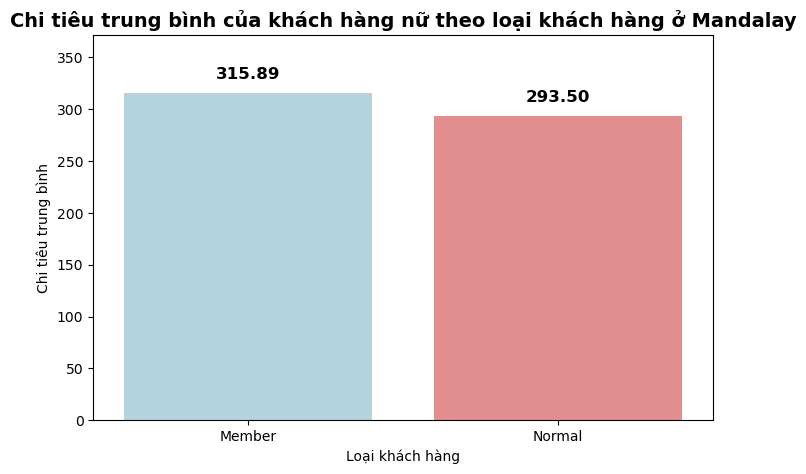

In [96]:
# biểu đồ cột thể hiện khách hàng nữ thành viên và không thành viên chi tiêu nhiều hơn ở Mandalay
mandalay_female_member_normal_avg_total = pd.DataFrame({
    'Customer type': ['Member', 'Normal'],
    'Chi tiêu trung bình': [mandalay_female_member_avg_total, mandalay_male_normal_avg_total]
})
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=mandalay_female_member_normal_avg_total, x='Customer type', y='Chi tiêu trung bình', palette=['lightblue', 'lightcoral'])
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}', padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Loại khách hàng')
plt.ylabel('Chi tiêu trung bình')
plt.title('Chi tiêu trung bình của khách hàng nữ theo loại khách hàng ở Mandalay', fontsize=14, fontweight='bold')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(ticks=range(len(yangon_female_member_normal_avg_total)), labels=yangon_female_member_normal_avg_total['Customer type'], rotation=0)
plt.show()

In [97]:
# Thành phố Naypyitaw  khách hàng nữ thành viên chi tiêu nhiều hơn hay khách hàng nam không thành viên chi tiêu nhiều hơn?
napyitaw_female_member_avg_total = supermarket_data_coppy[(supermarket_data_coppy['City'] == 'Naypyitaw') & (supermarket_data_coppy['Gender'] == 'Female') & (supermarket_data_coppy['Customer type'] == 'Member')]['Total'].mean()
napyitaw_male_normal_avg_total = supermarket_data_coppy[(supermarket_data_coppy['City'] == 'Naypyitaw') & (supermarket_data_coppy['Gender'] == 'Male') & (supermarket_data_coppy['Customer type'] == 'Normal')]['Total'].mean()
print(f"Chi tiêu trung bình của khách hàng nữ thành viên ở Naypyitaw: {napyitaw_female_member_avg_total:,.2f}")
print(f"Chi tiêu trung bình của khách hàng nam không thành viên ở Naypyitaw: {napyitaw_male_normal_avg_total:,.2f}")

Chi tiêu trung bình của khách hàng nữ thành viên ở Naypyitaw: 360.97
Chi tiêu trung bình của khách hàng nam không thành viên ở Naypyitaw: 346.17


C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\277030546.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=napyitaw_female_member_normal_avg_total, x='Customer type', y='Chi tiêu trung bình', palette=['lightblue', 'lightcoral'])


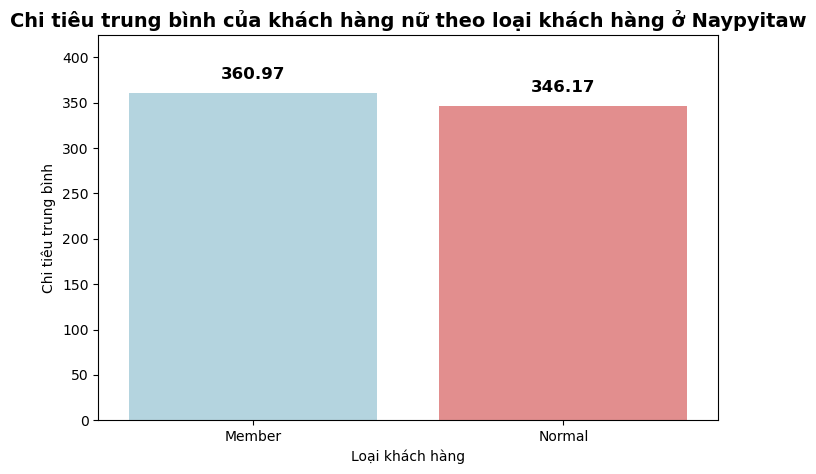

In [98]:
# biểu đồ cột thể hiện khách hàng nữ thành viên và không thành viên chi tiêu nhiều hơn ở Naypyitaw
napyitaw_female_member_normal_avg_total = pd.DataFrame({
    'Customer type': ['Member', 'Normal'],
    'Chi tiêu trung bình': [napyitaw_female_member_avg_total, napyitaw_male_normal_avg_total]
})
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=napyitaw_female_member_normal_avg_total, x='Customer type', y='Chi tiêu trung bình', palette=['lightblue', 'lightcoral'])
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}', padding=8, fontsize=12, fontweight='bold')
plt.xlabel('Loại khách hàng')
plt.ylabel('Chi tiêu trung bình')
plt.title('Chi tiêu trung bình của khách hàng nữ theo loại khách hàng ở Naypyitaw', fontsize=14, fontweight='bold')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(ticks=range(len(napyitaw_female_member_normal_avg_total)), labels=napyitaw_female_member_normal_avg_total['Customer type'], rotation=0)
plt.show()

# Phương thức thanh toán theo nhóm khách hàng

## Toàn cục

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\629658022.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=payment_method_counts, x='Payment', y='Số lượng', palette='Set2')


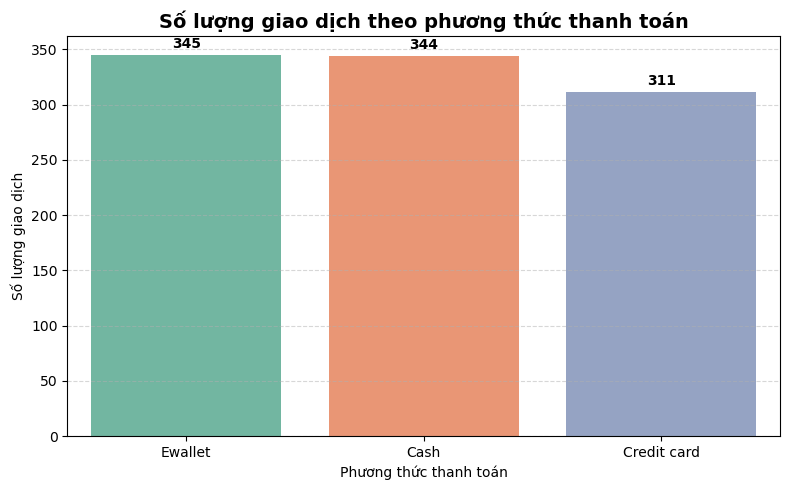

In [99]:
# Tỷ lệ phương thức thanh toán trong dữ liệu
payment_method_counts = supermarket_data_coppy['Payment'].value_counts().reset_index()
payment_method_counts.columns = ['Payment', 'Số lượng']
payment_method_counts = payment_method_counts.sort_values('Số lượng', ascending=False)
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=payment_method_counts, x='Payment', y='Số lượng', palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10, fontweight='bold')
plt.xlabel('Phương thức thanh toán')
plt.ylabel('Số lượng giao dịch')
plt.title('Số lượng giao dịch theo phương thức thanh toán', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

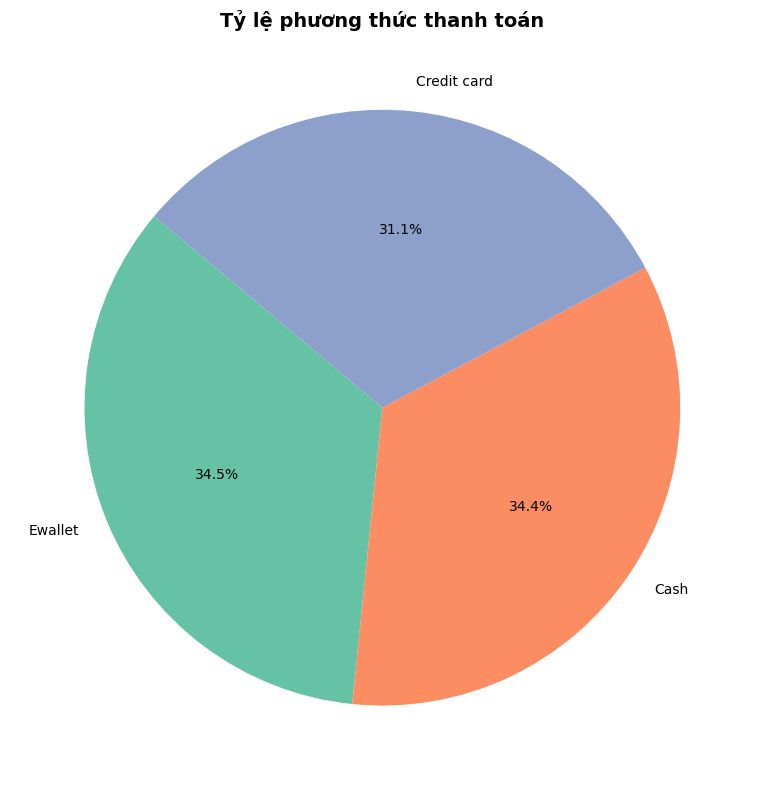

In [100]:
# Biểu đồ tròn thể hiện tỷ lệ phương thức thanh toán trong dữ liệu
plt.figure(figsize=(8, 8))
ax = plt.subplot(111)
ax.pie(payment_method_counts['Số lượng'], labels=payment_method_counts['Payment'],
         autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
ax.set_title('Tỷ lệ phương thức thanh toán', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Khách hàng member và normal thanh toán theo phương thức nào nhiều nhất

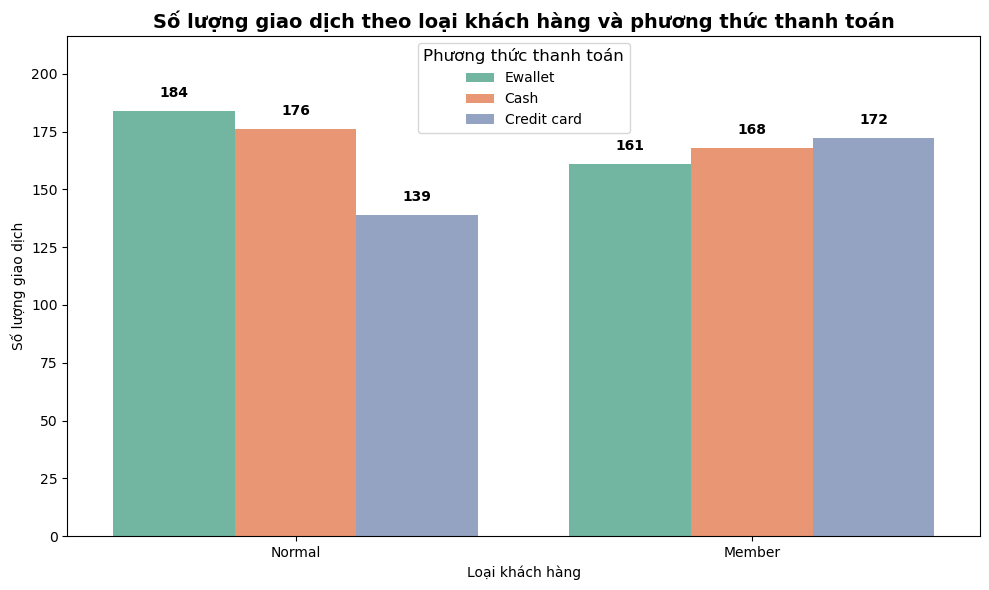

In [101]:
# Khách hàng member và non-member sử dụng phương thức thanh toán nào nhiều nhất?
customer_payment_counts = supermarket_data_coppy.groupby(['Customer type', 'Payment']).size().reset_index(name='Số lượng')
customer_payment_counts = customer_payment_counts.sort_values('Số lượng', ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=customer_payment_counts, x='Customer type', y='Số lượng', hue='Payment', palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=8, fontsize=10, fontweight='bold')
plt.xlabel('Loại khách hàng')
plt.ylabel('Số lượng giao dịch')
plt.title('Số lượng giao dịch theo loại khách hàng và phương thức thanh toán', fontsize=14, fontweight='bold')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(rotation=0)
plt.legend(title='Phương thức thanh toán', title_fontsize=12, fontsize=10)
plt.tight_layout()
plt.show()

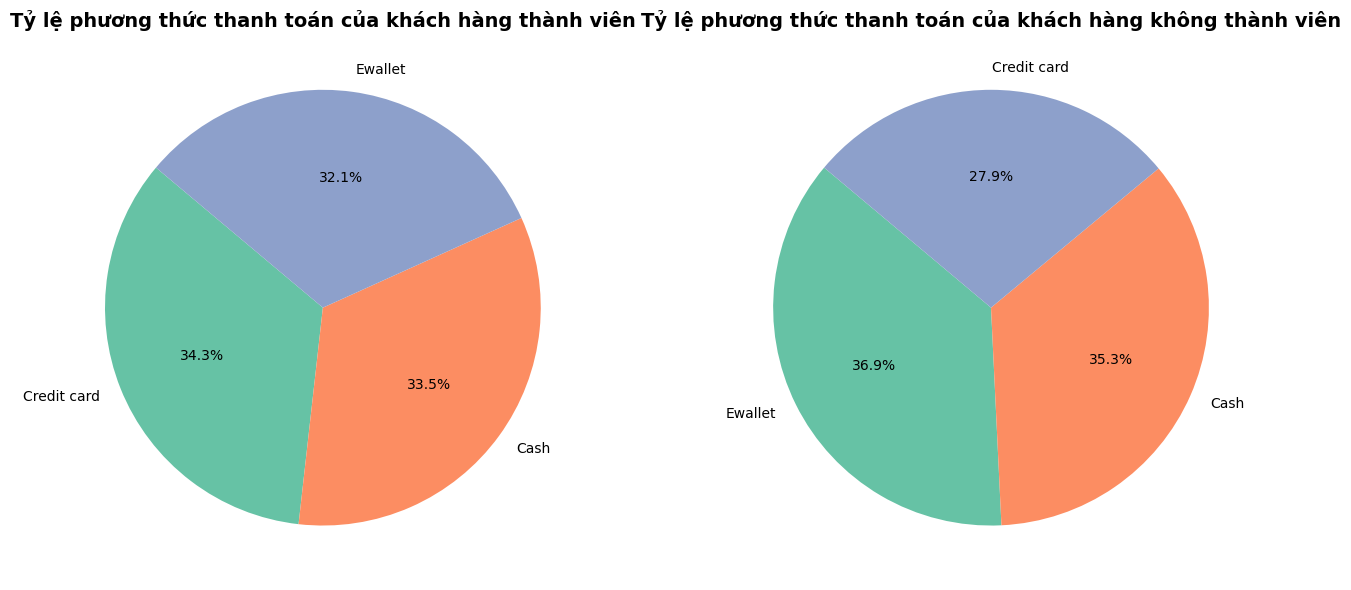

In [102]:
# Biểu đồ tròn thể hiện tỷ lệ phương thức thanh toán của khách hàng member và non-member
member_payment_counts = customer_payment_counts[customer_payment_counts['Customer type'] == 'Member']
normal_payment_counts = customer_payment_counts[customer_payment_counts['Customer type'] == 'Normal']
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.pie(member_payment_counts['Số lượng'], labels=member_payment_counts['Payment'],
         autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
plt.title('Tỷ lệ phương thức thanh toán của khách hàng thành viên', fontsize=14, fontweight='bold')
plt.subplot(1, 2, 2)    
plt.pie(normal_payment_counts['Số lượng'], labels=normal_payment_counts['Payment'],
         autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
plt.title('Tỷ lệ phương thức thanh toán của khách hàng không thành viên', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Khách hàng gender thanh toán bằng phương pháp nào nhiều nhất

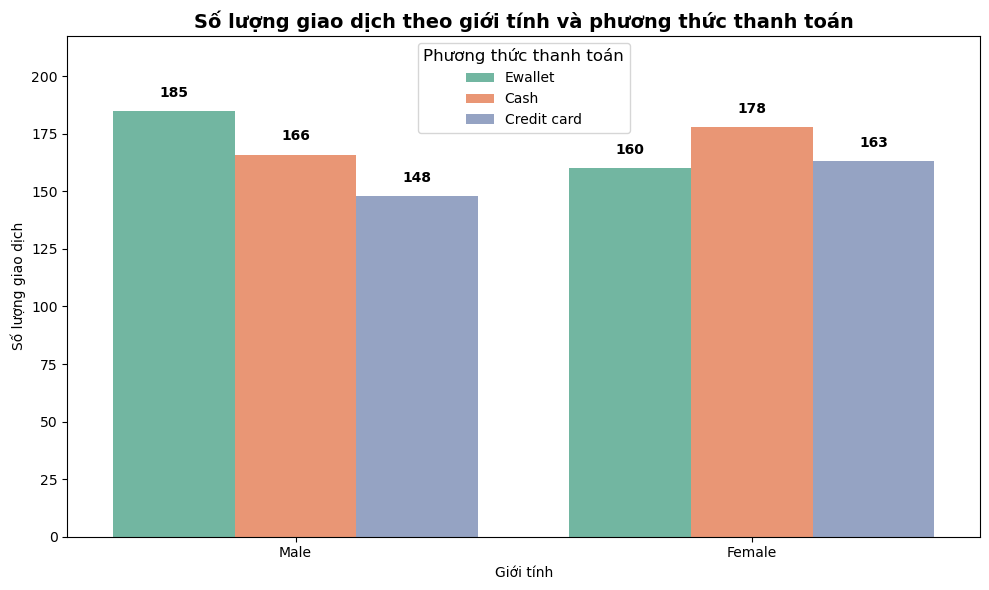

In [103]:
# Khách hàng nam và nữ sử dụng phương thức thanh toán nào nhiều nhất?
gender_payment_counts = supermarket_data_coppy.groupby(['Gender', 'Payment']).size().reset_index(name='Số lượng')
gender_payment_counts = gender_payment_counts.sort_values('Số lượng', ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=gender_payment_counts, x='Gender', y='Số lượng', hue='Payment', palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=8, fontsize=10, fontweight='bold')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng giao dịch')
plt.title('Số lượng giao dịch theo giới tính và phương thức thanh toán', fontsize=14, fontweight='bold')
plt.ylim(0, ax.get_ylim()[1] * 1.12)
plt.xticks(rotation=0)
plt.legend(title='Phương thức thanh toán', title_fontsize=12, fontsize=10)
plt.tight_layout()
plt.show()

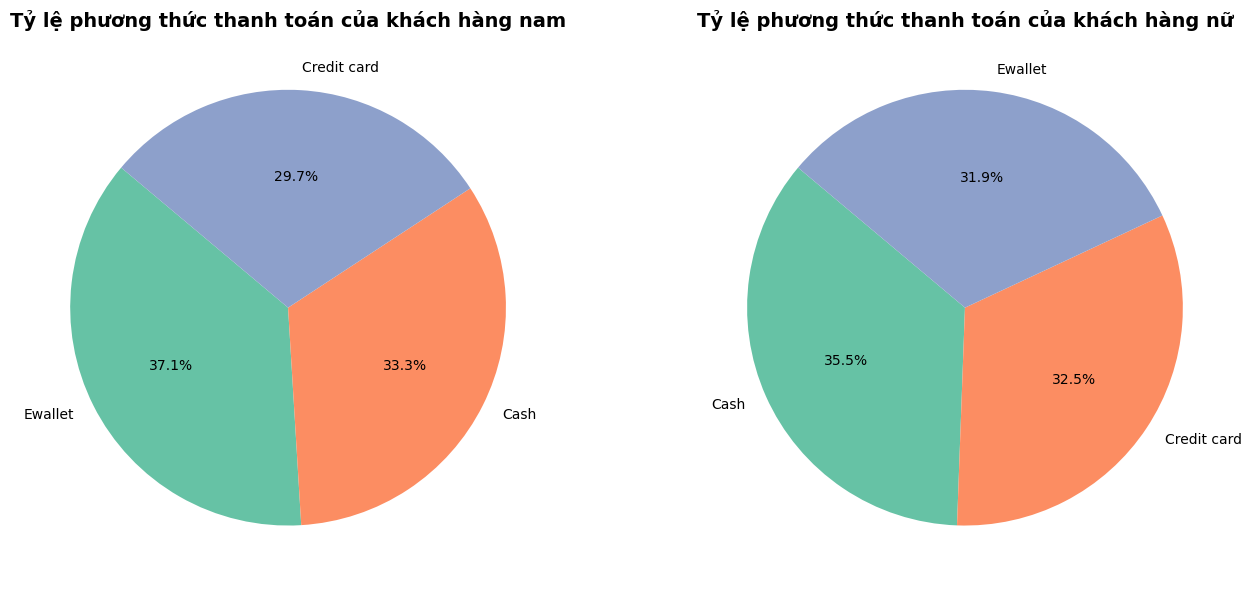

In [104]:
# Biểu đồ tròn thể hiện tỷ lệ phương thức thanh toán theo giới tính
male_payment_counts = gender_payment_counts[gender_payment_counts['Gender'] == 'Male']
female_payment_counts = gender_payment_counts[gender_payment_counts['Gender'] == 'Female']
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.pie(male_payment_counts['Số lượng'], labels=male_payment_counts['Payment'],
         autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
plt.title('Tỷ lệ phương thức thanh toán của khách hàng nam', fontsize=14, fontweight='bold')
plt.subplot(1, 2, 2)    
plt.pie(female_payment_counts['Số lượng'], labels=female_payment_counts['Payment'],
         autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
plt.title('Tỷ lệ phương thức thanh toán của khách hàng nữ', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Thành phố Yangon

In [105]:
def ve_bieu_do_ty_le_thanh_toan(
    supermarket_data,
    city='Yangon',
    customer_type=None,      # 'Member' / 'Normal' / None (tất cả)
    gender=None,             # 'Male' / 'Female' / None (tất cả)
    save_path=None           # ví dụ: 'charts/1_member_yangon.png'
):
    """
    Vẽ biểu đồ cột + biểu đồ tròn theo phương thức thanh toán.
    Hỗ trợ tất cả 3 thành phố, Member/Normal, Male/Female.
    """
    # Lọc dữ liệu
    df = supermarket_data[supermarket_data['City'] == city].copy()
    
    if customer_type is not None:
        df = df[df['Customer type'] == customer_type]
    if gender is not None:
        df = df[df['Gender'] == gender]
    
    if df.empty:
        print(f"Không có dữ liệu cho: {city} | {customer_type or 'Tất cả'} | {gender or 'Tất cả giới tính'}")
        return
    
    # Đếm và sắp xếp giảm dần (trực quan nhất)
    counts = df.groupby('Payment').size().reset_index(name='Số lượng')
    counts = counts.sort_values('Số lượng', ascending=False)
    
    # Màu sắc đồng bộ giữa 2 biểu đồ
    colors = sns.color_palette('Set2', n_colors=len(counts))
    
    # Tạo 2 biểu đồ cạnh nhau
    fig, axs = plt.subplots(1, 2, figsize=(15, 6.5))
    
    # ==================== BIỂU ĐỒ CỘT ====================
    sns.barplot(
        data=counts,
        x='Payment',
        y='Số lượng',
        palette=colors,
        order=counts['Payment'],
        ax=axs[0]
    )
    for container in axs[0].containers:
        axs[0].bar_label(container, fmt='%d', padding=8, fontsize=10, fontweight='bold')
    
    axs[0].set_xlabel('Phương thức thanh toán', fontsize=12)
    axs[0].set_ylabel('Số lượng giao dịch', fontsize=12)
    axs[0].tick_params(axis='x', labelsize=11)
    axs[0].tick_params(axis='y', labelsize=10)
    axs[0].grid(axis='y', linestyle='--', alpha=0.4)
    axs[0].set_title('Số lượng giao dịch', fontsize=13, pad=10)
    
    # ==================== BIỂU ĐỒ TRÒN ====================
    axs[1].pie(
        counts['Số lượng'],
        labels=counts['Payment'],
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        textprops={'fontsize': 11, 'fontweight': 'bold'}
    )
    axs[1].axis('equal')
    axs[1].set_title('Tỷ lệ phần trăm', fontsize=13, pad=10)
    
    # Tiêu đề chung
    parts = []
    if customer_type is not None:
        parts.append('thành viên' if customer_type == 'Member' else 'không thành viên')
    else:
        parts.append('tất cả khách hàng')
    if gender is not None:
        parts.append('nam' if gender == 'Male' else 'nữ')
    
    fig.suptitle(
        f'Số lượng & tỷ lệ giao dịch theo phương thức thanh toán\n'
        f'{city} — {" — ".join(parts)}',
        fontsize=15, fontweight='bold', y=1.02
    )
    
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

### Khách hàng member và normal sử dụng phương thức thanh toán nào nhiều nhất

# Thành phố Yangon

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


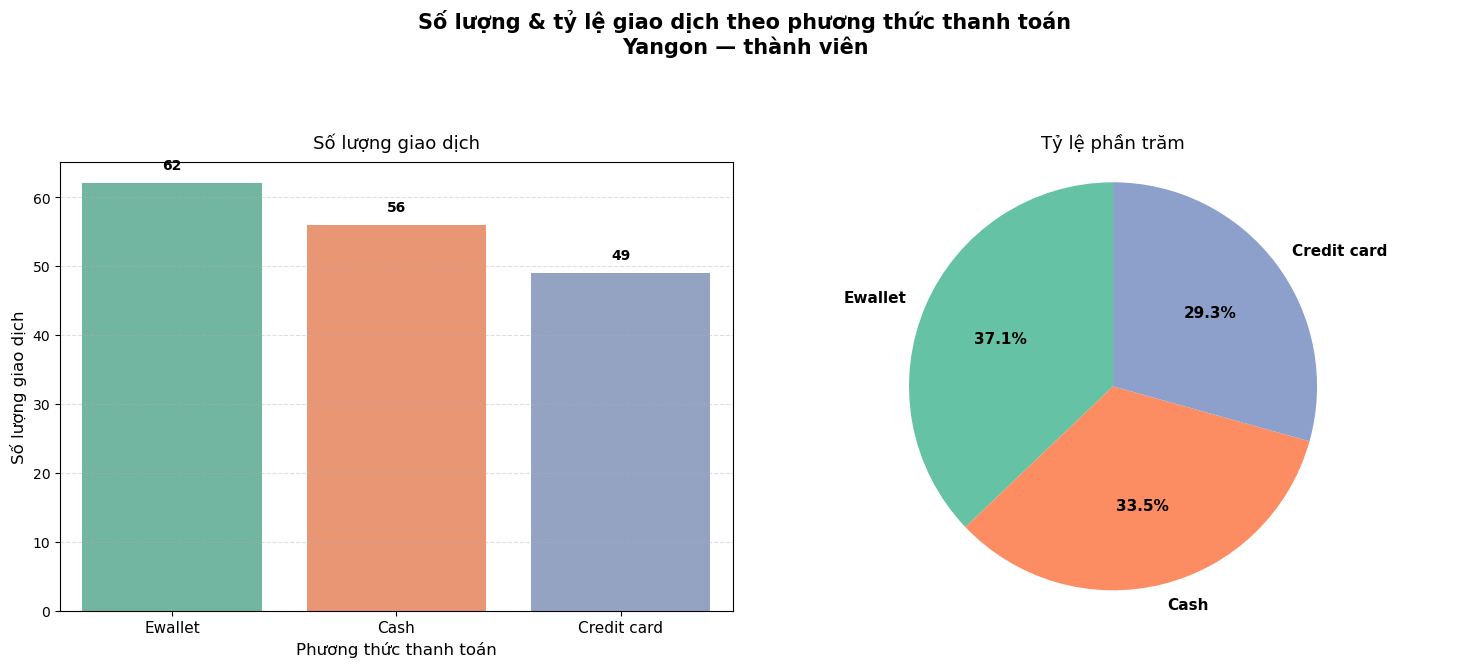

In [106]:
# Biểu đồ phương thức thanh toán của khách hàng thành viên ở Yangon
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Yangon', customer_type='Member')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


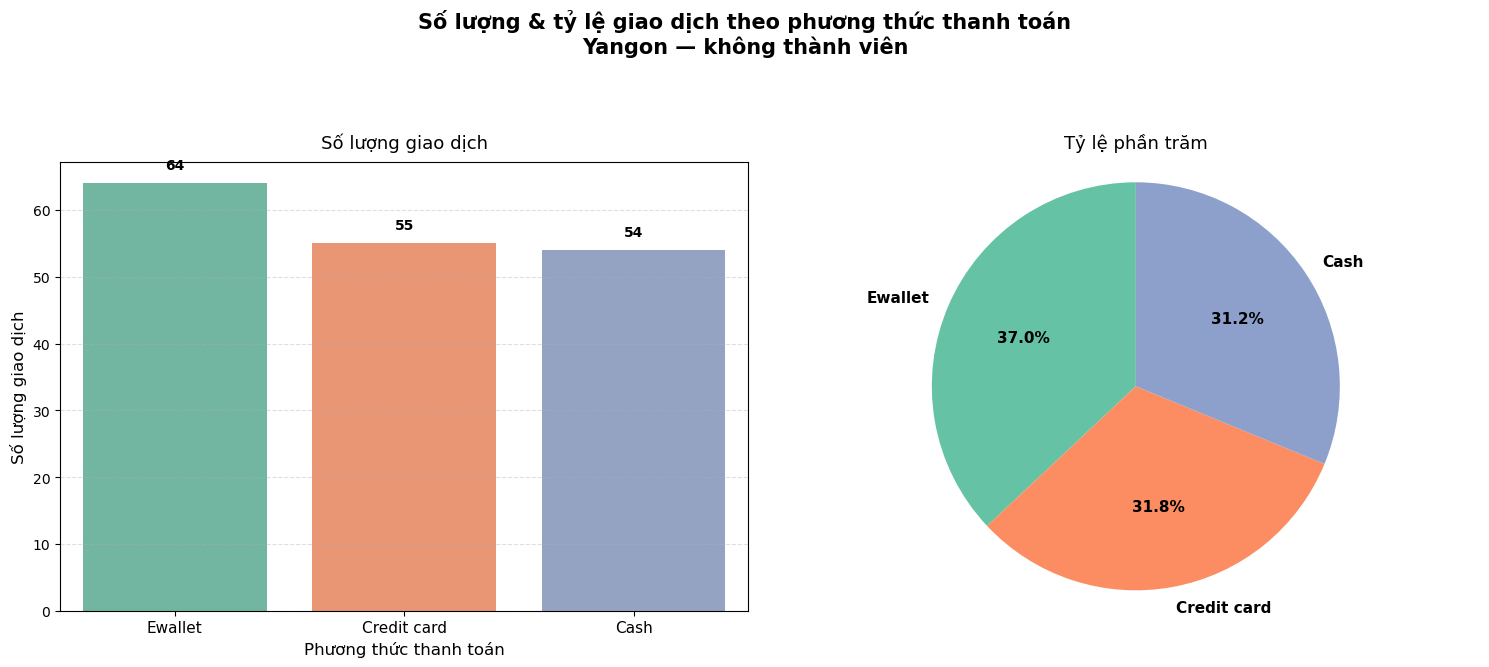

In [107]:
# Biểu đồ phương thức thanh toán của khách hàng không thành viên ở Yangon
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Yangon', customer_type='Normal')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


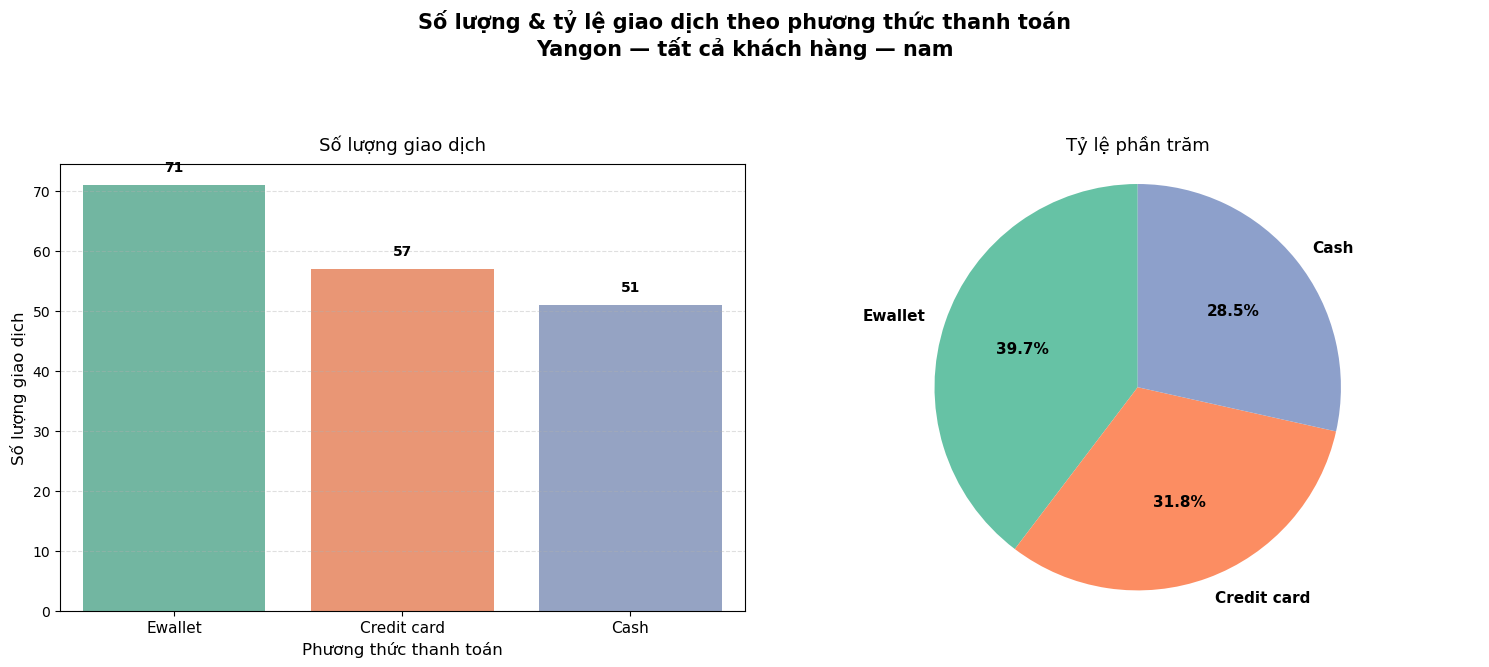

In [108]:
# Biểu đồ phương thức thanh toán của khách hàng nam ở Yangon
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Yangon', gender='Male')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


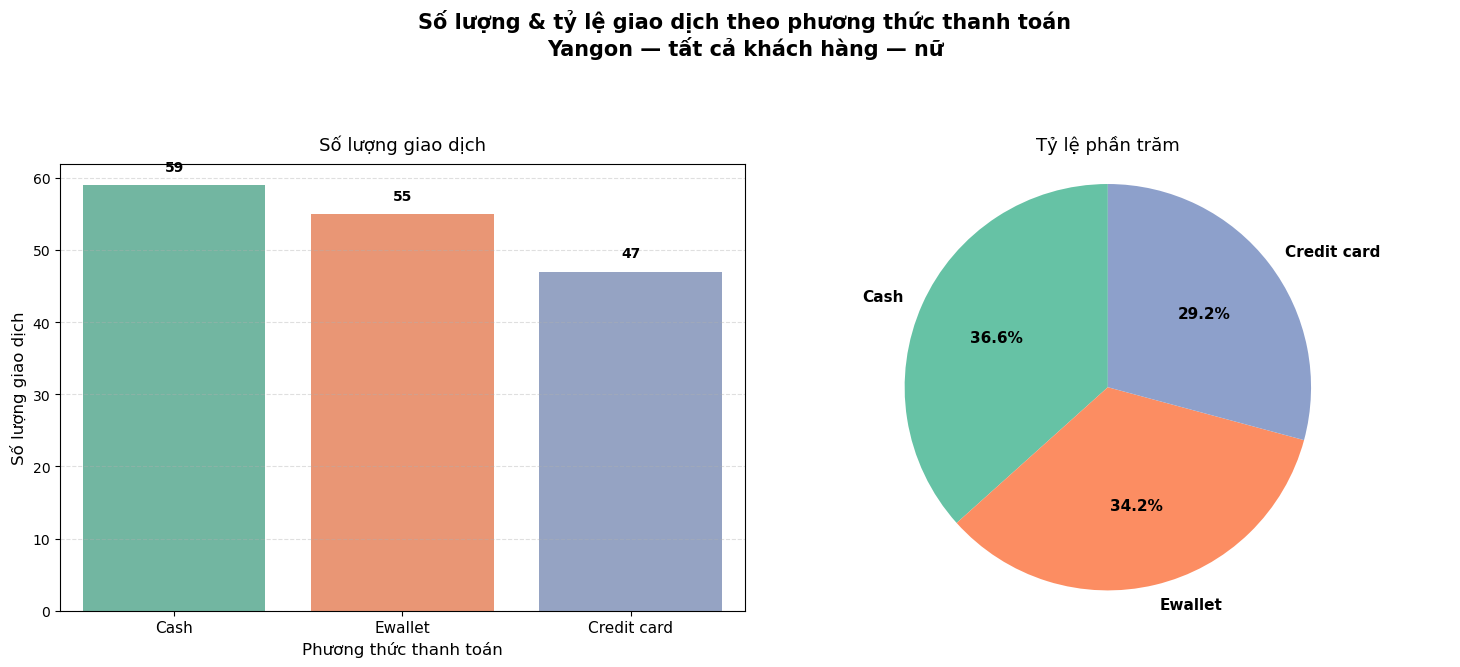

In [109]:
# Biểu đồ phương thức thanh toán của khách hàng nữ ở Yangon
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Yangon', gender='Female')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


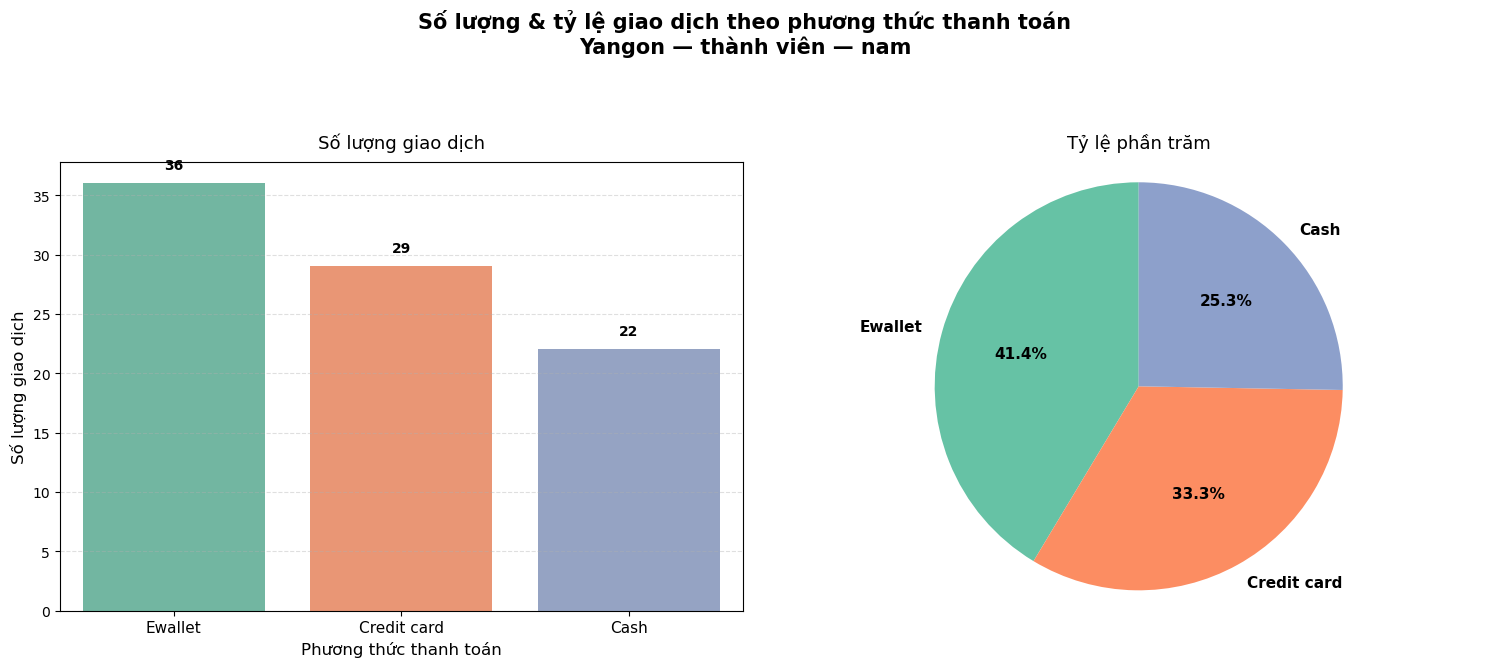

In [110]:
# Biểu đồ phương thức thanh toán của khách hàng nam là thành viên ở Yangon
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Yangon', customer_type='Member', gender='Male')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


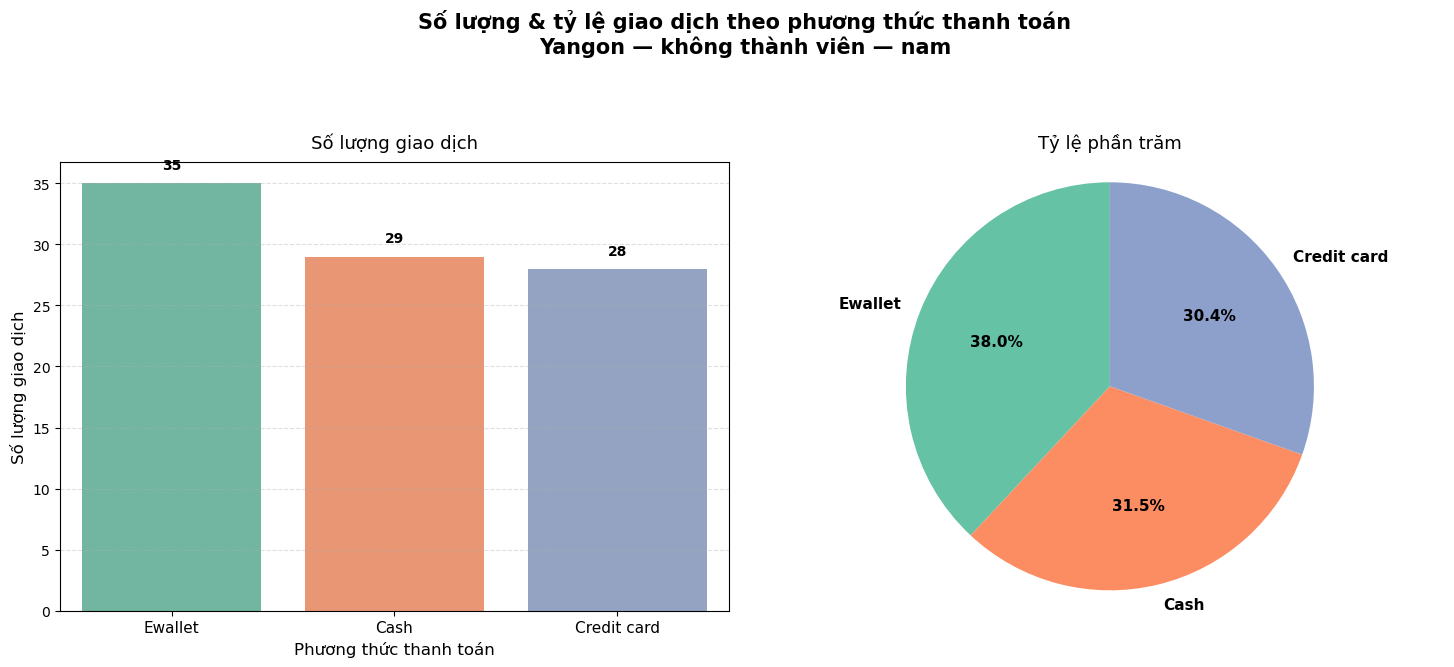

In [111]:
#Biểu đồ phương thức thanh toán của khách hàng nam không thành viên ở Yangon
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Yangon', customer_type='Normal', gender='Male')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


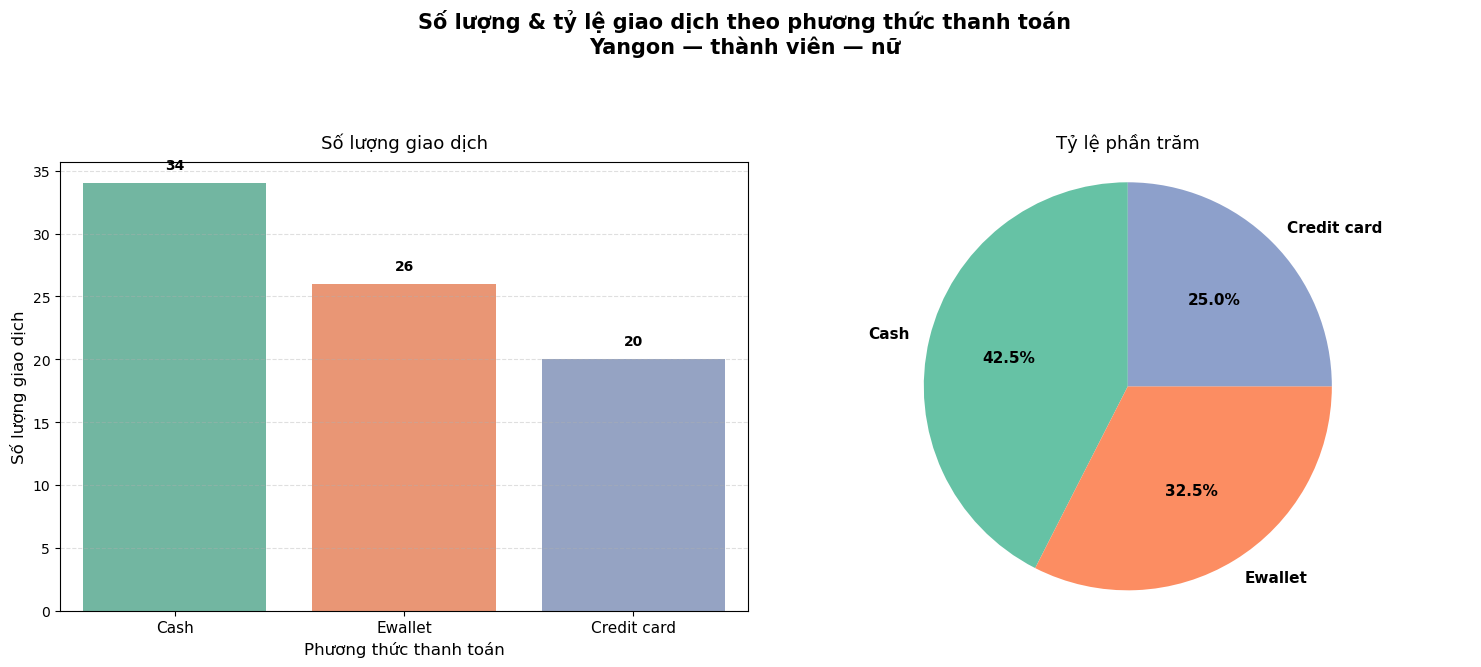

In [112]:
# Biểu đồ tỷ lệ phương thức thanh toán của khách hàng thành viên là nữ ở Yangon
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Yangon', customer_type='Member', gender='Female')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


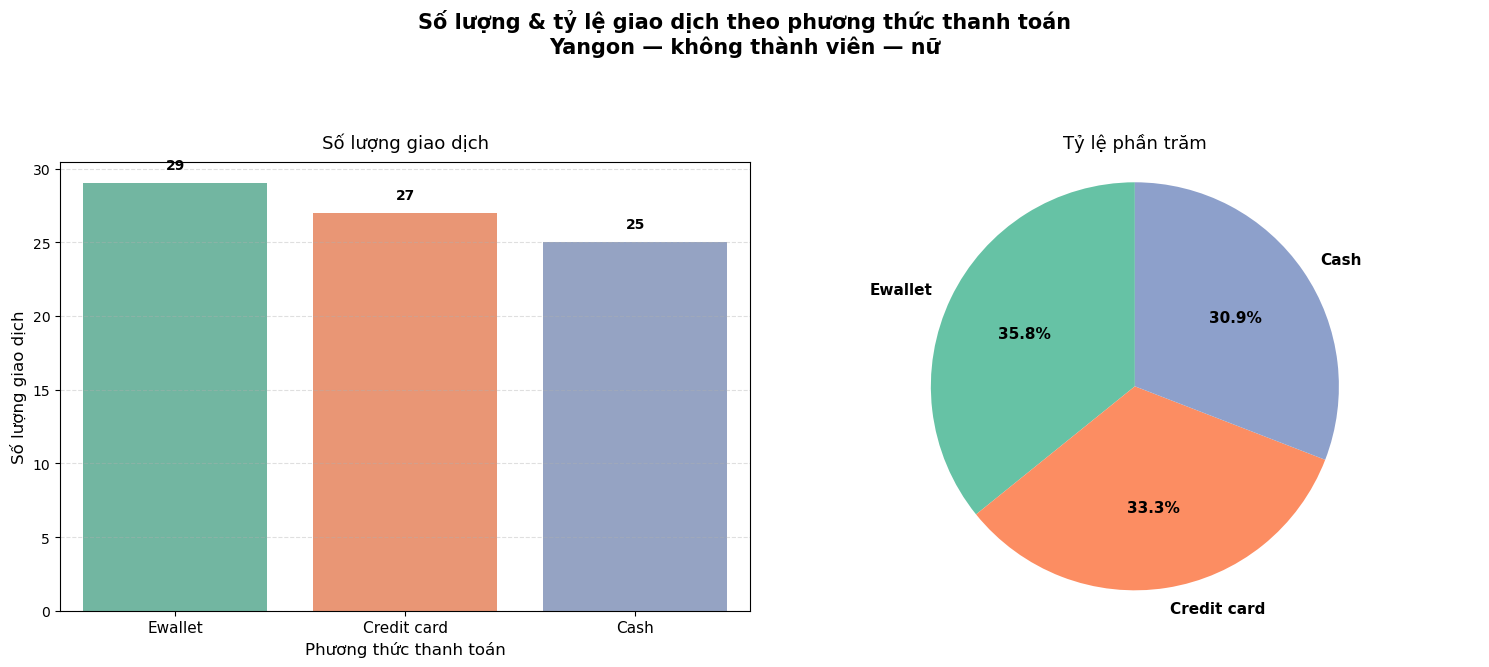

In [113]:
# biểu đồ phương thức thanh toán của khách hàng không thành viên là nữ ở Yangon
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Yangon', customer_type='Normal', gender='Female')

# Thành phố mandalay

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


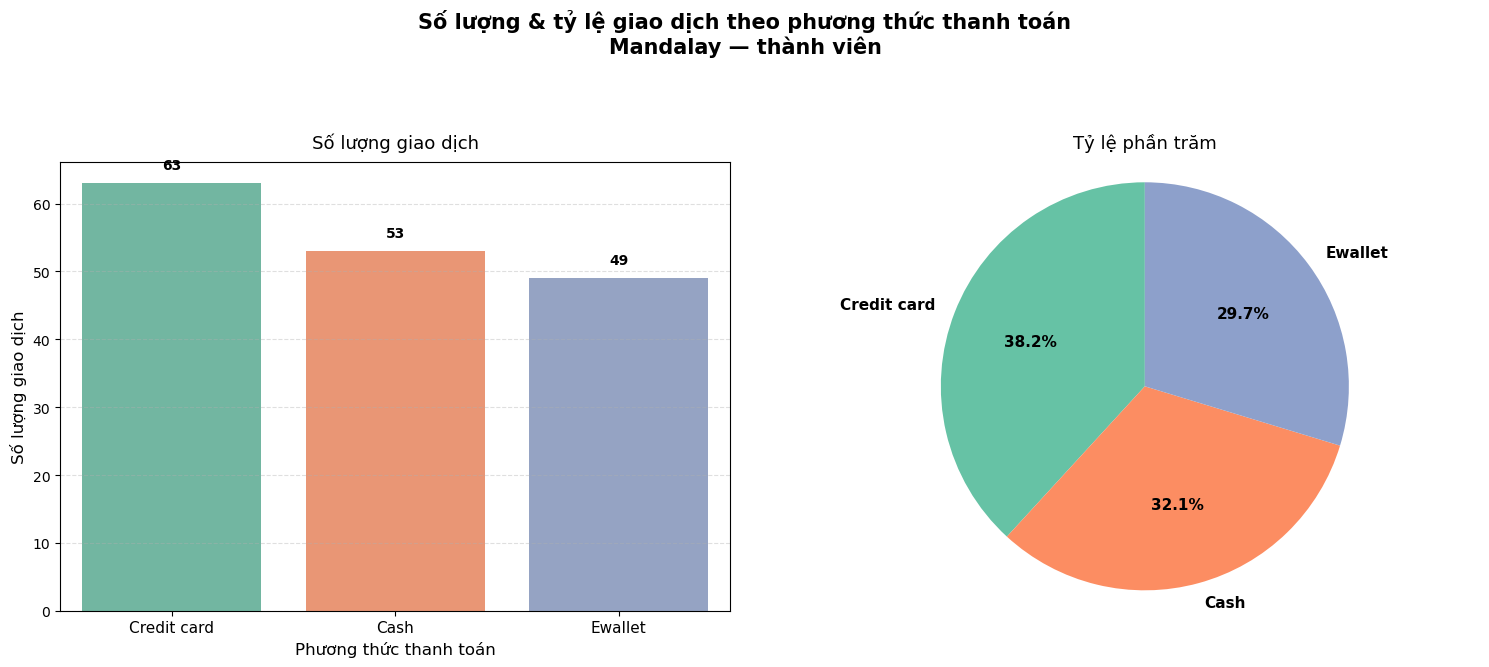

In [114]:
# Bieu đồ phương thức thanh toán của khách hàng thành viên ở Mandalay
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Mandalay', customer_type='Member')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


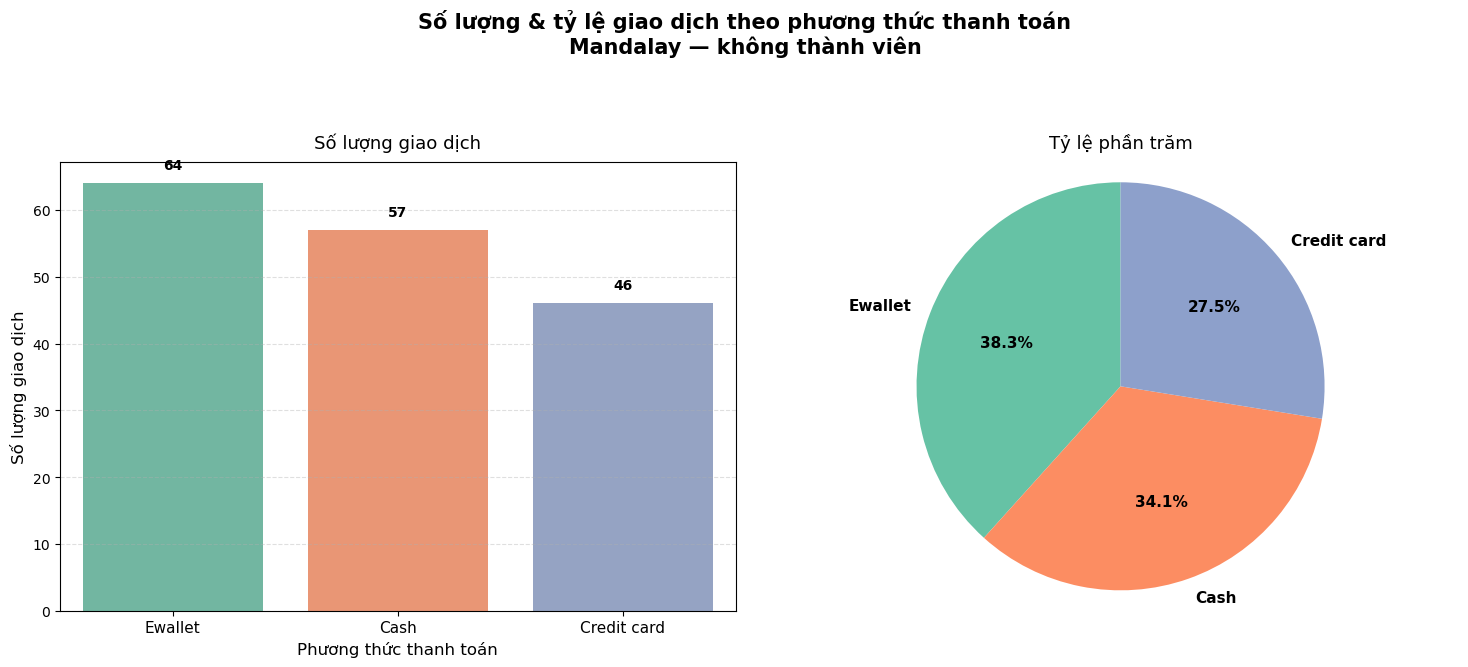

In [115]:
# Biểu đồ tỷ lệ phương thức thanh toán của khách không phải là hành viên ở Yangon
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Mandalay', customer_type='Normal')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


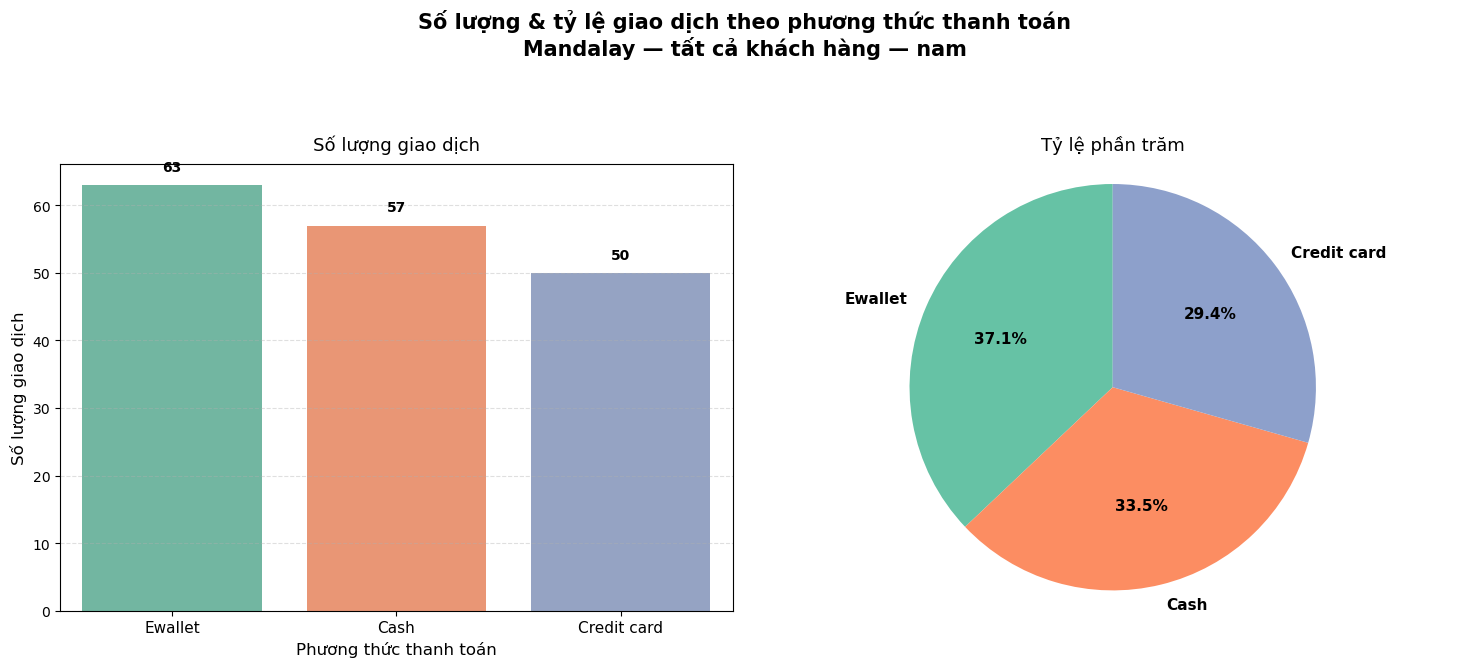

In [116]:
# Biểu đồ phương thức thanh toán của khách hàng nam ở Mandalay
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Mandalay', gender='Male')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


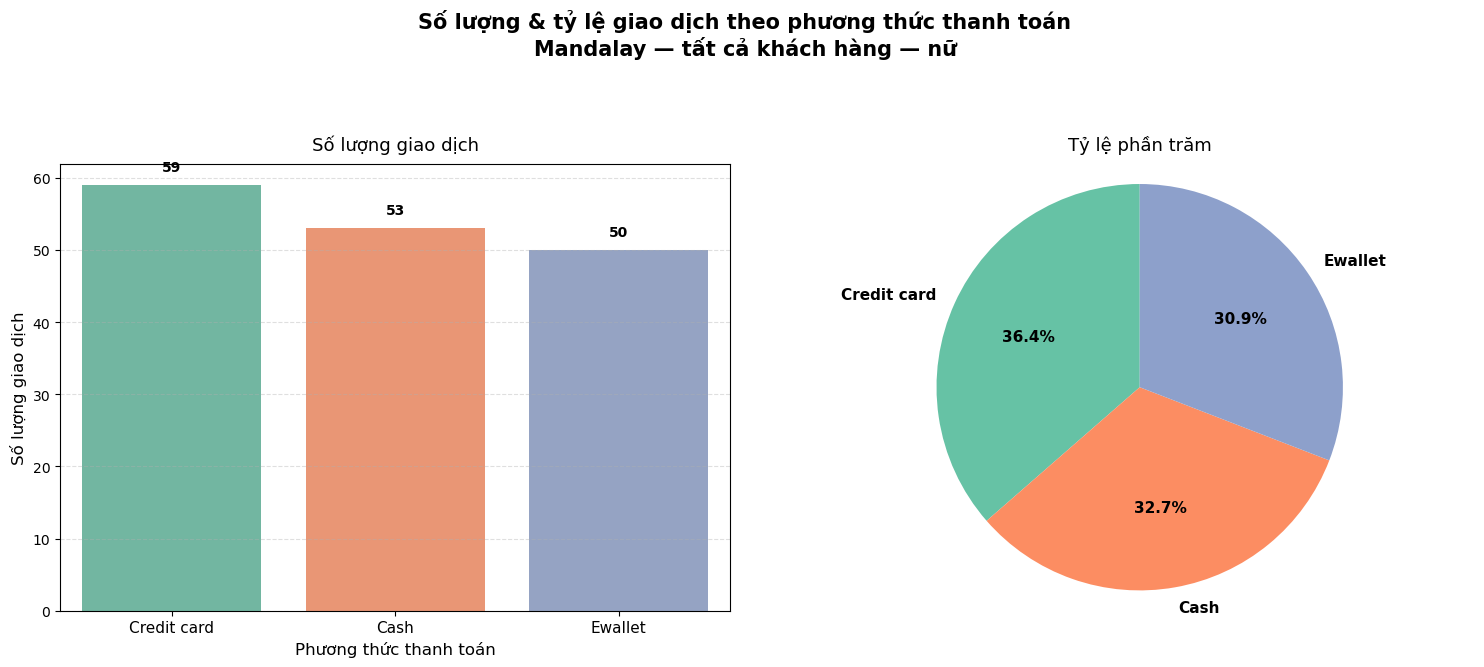

In [117]:
# Biểu đồ phương thức thanh toán của khách hàng nữ ở Mandalay
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Mandalay', gender='Female')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


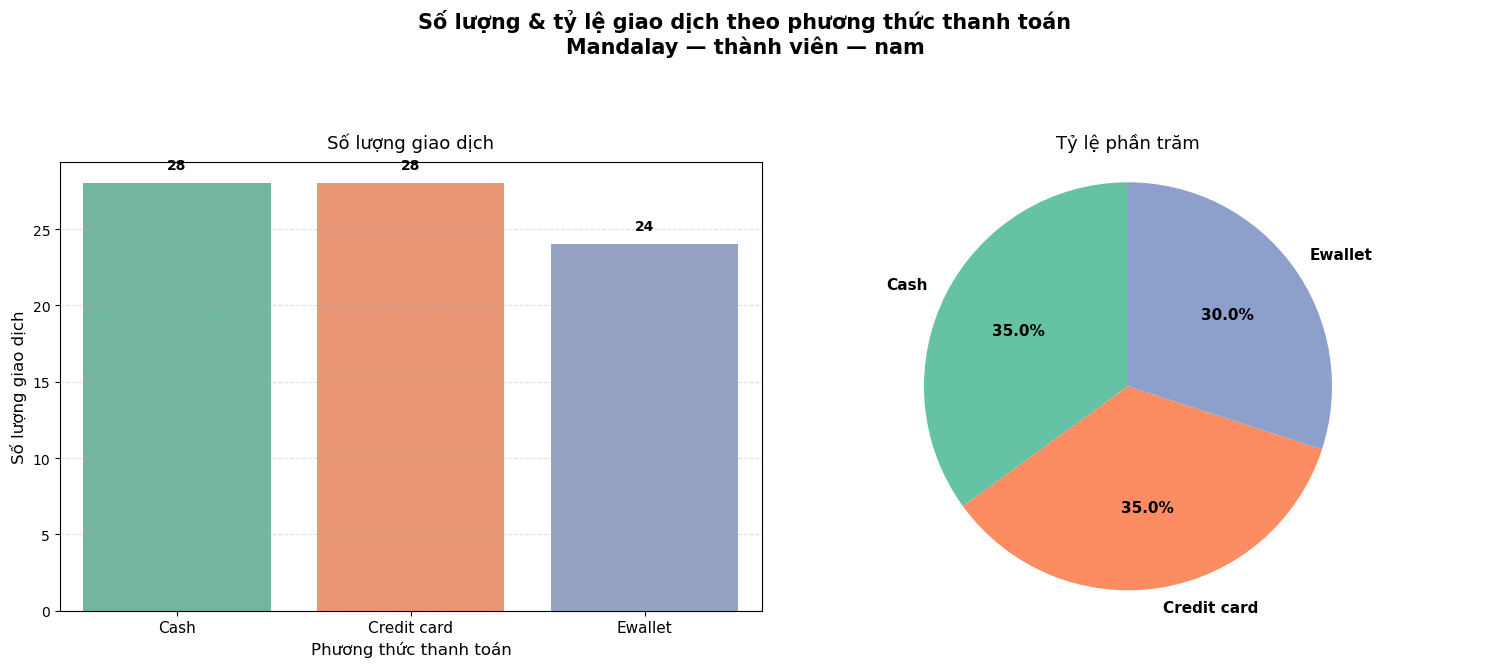

In [118]:
# Biểu đồ phương thức thanh toán của khách hàng nam là khách hàng thành viên ở Mandalay
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Mandalay', customer_type='Member', gender='Male')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


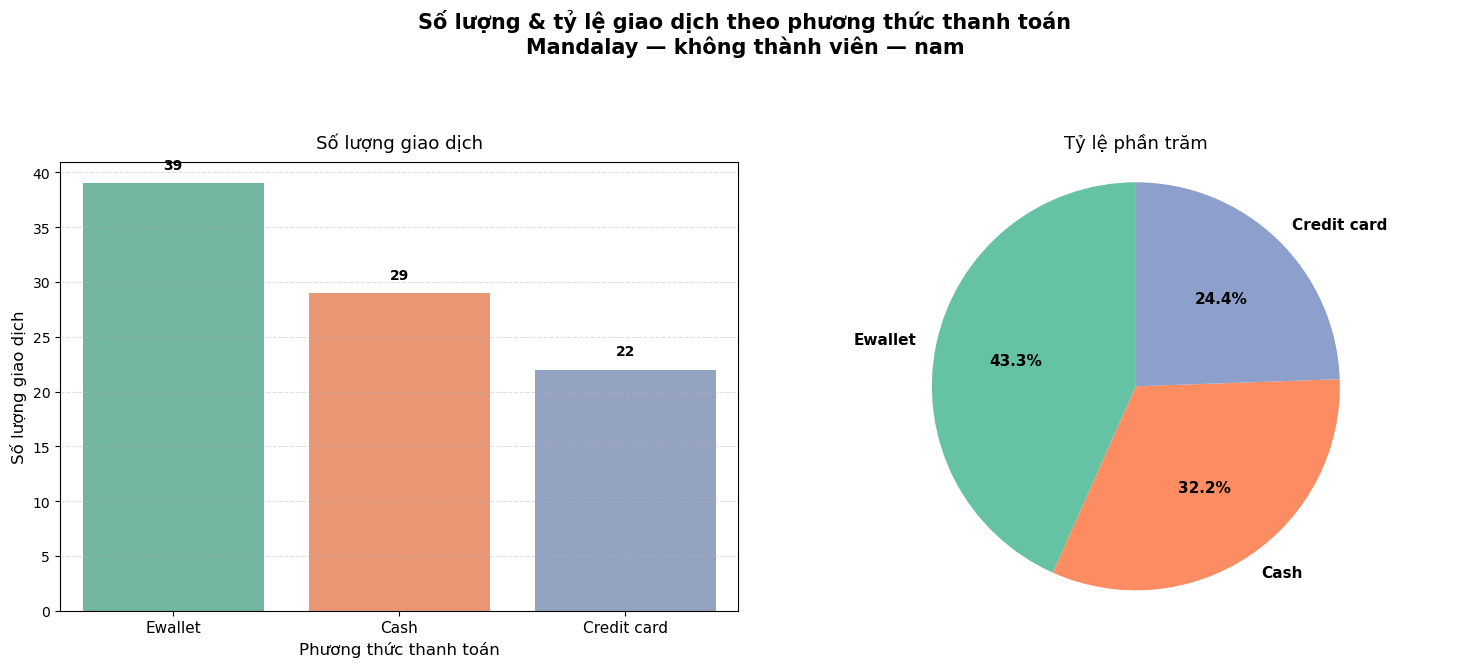

In [119]:
# Biểu đồ phương thức thanh toán của khách hàng nam là normal ở Mandalay
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Mandalay', customer_type='Normal', gender='Male')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


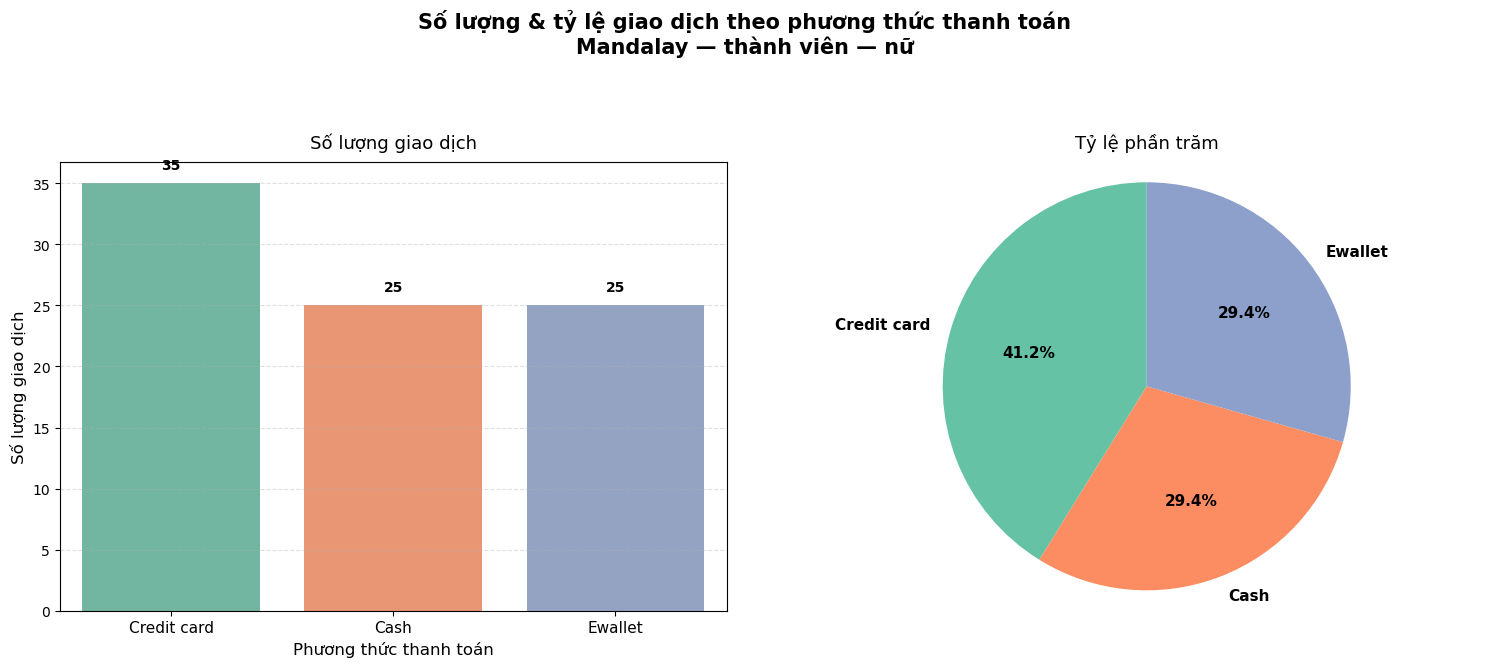

In [120]:
# Biểu đồ phương thức thanh toán của khách hàng nữ là khách hàng thành viên ở Mandalay
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Mandalay', customer_type='Member', gender='Female')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


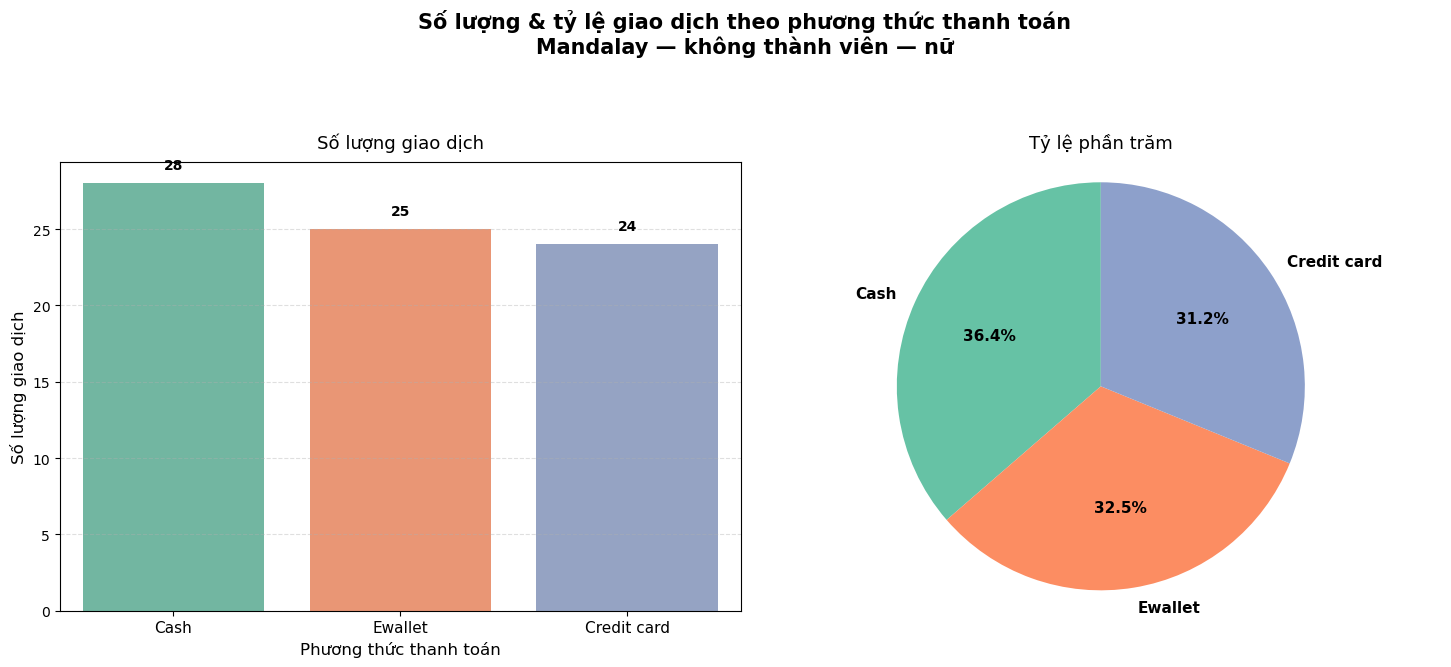

In [121]:
# Biểu đồ phương thức thanh toán của khách hàng nữ không là khách hàng thành viên ở Mandalay
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Mandalay', customer_type='Normal', gender='Female')

# Thành phố Naypyitaw

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


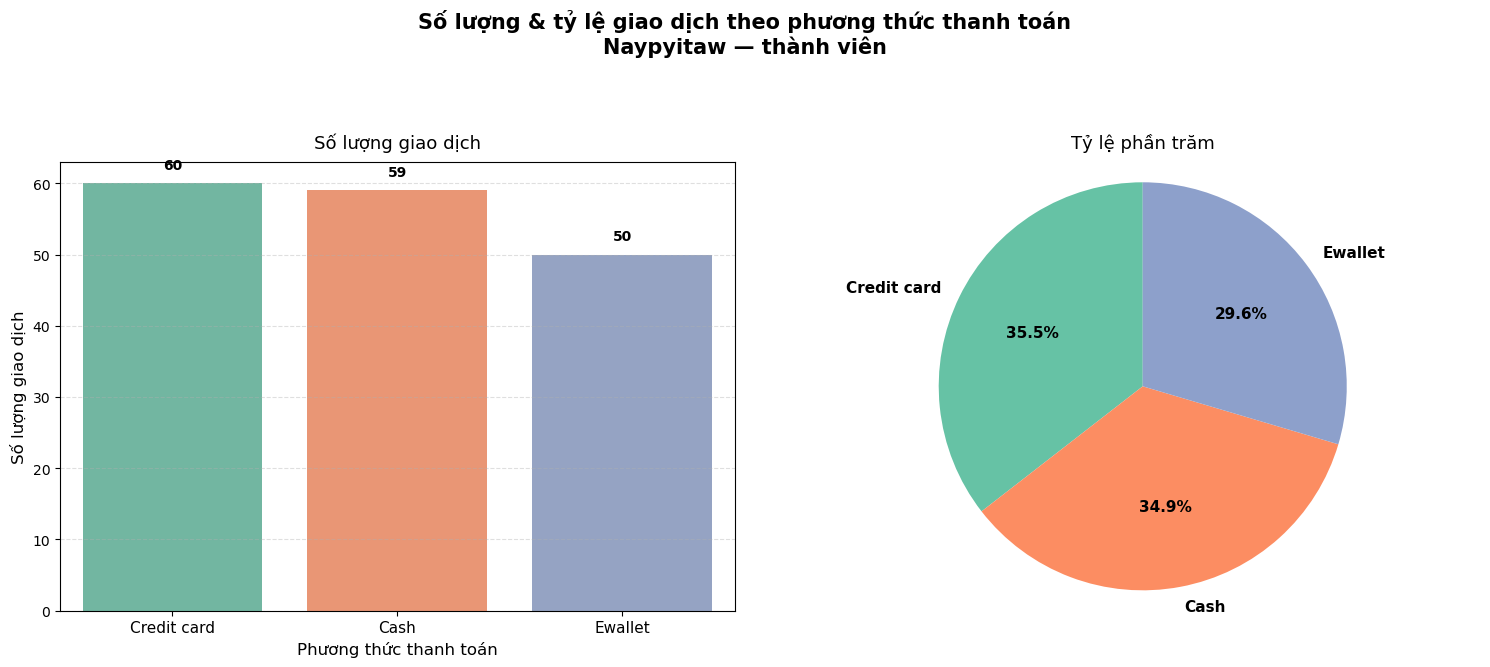

In [122]:
# Biểu đồ phương thức thanh toán của khách hàng thành viên ở Naypyitaw
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Naypyitaw', customer_type='Member')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


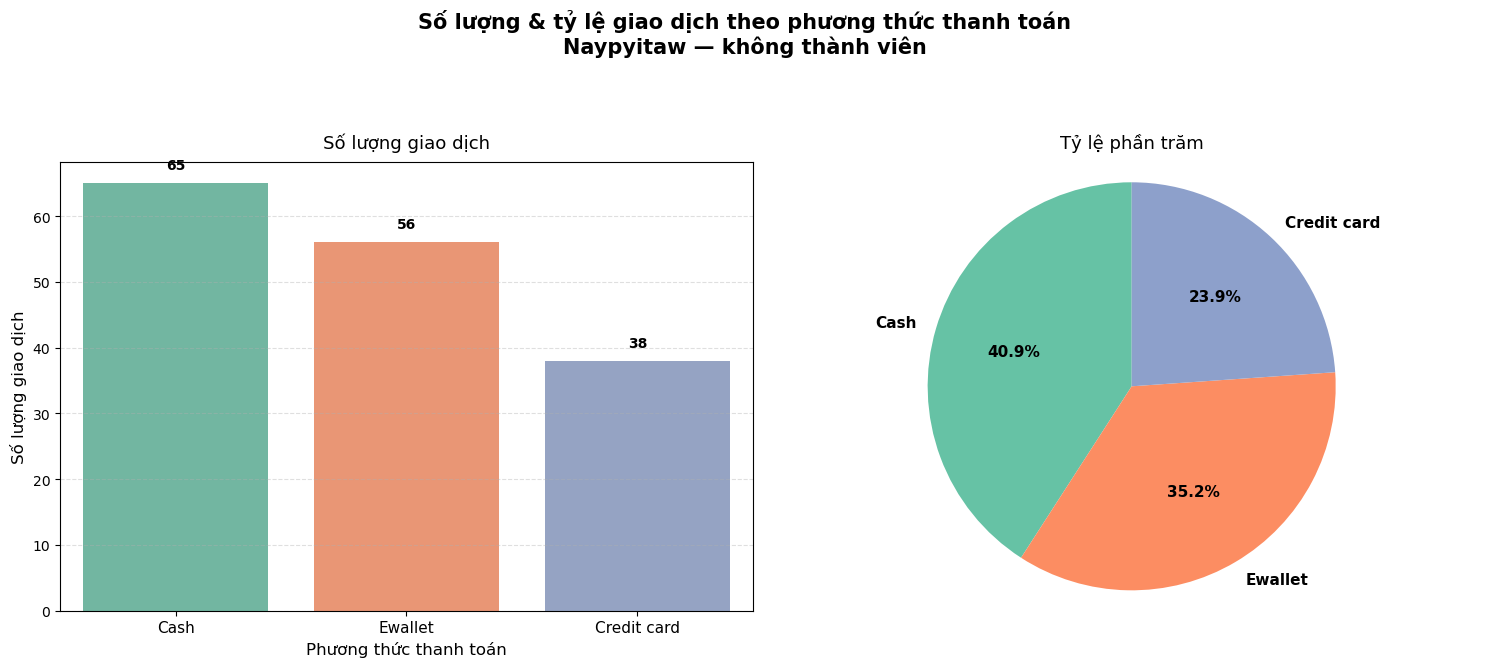

In [123]:
# Biểu đồ phương thức thanh toán của khách hàng normal ở Naypyitaw
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Naypyitaw', customer_type='Normal')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


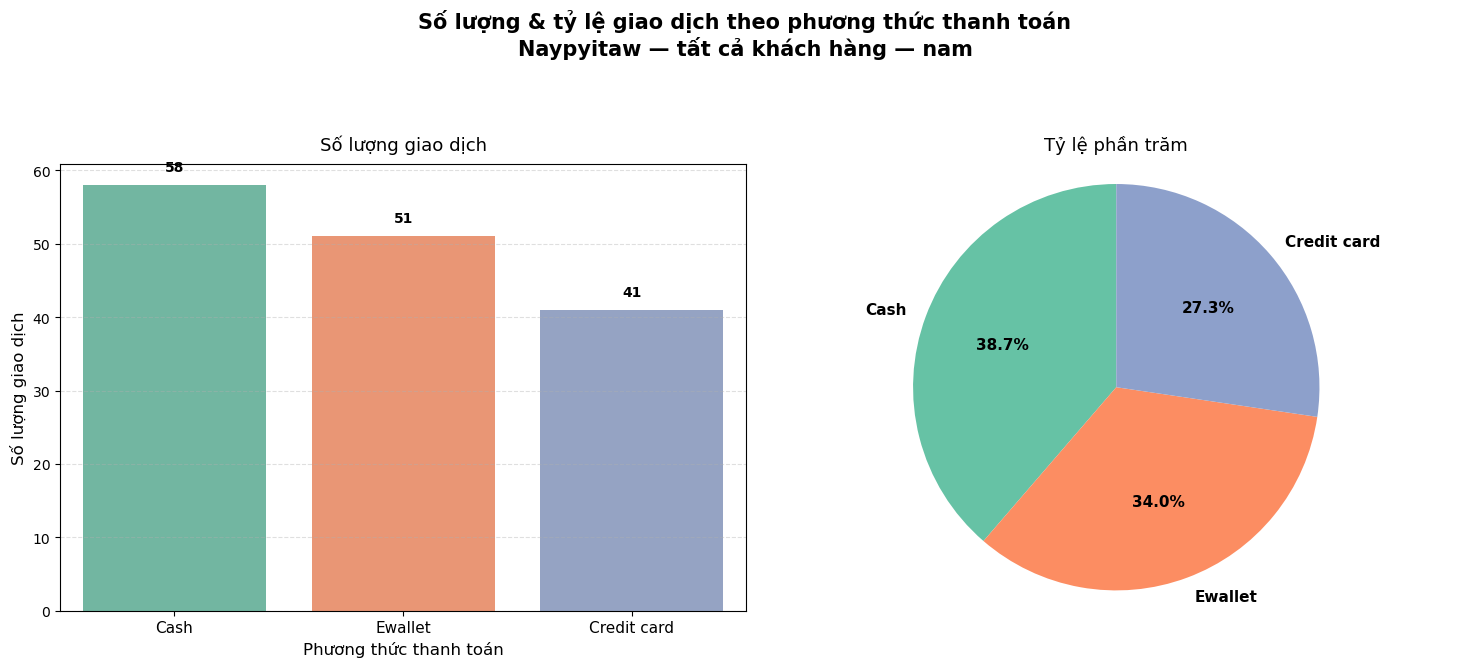

In [124]:
# Biểu đồ phương thức thanh toán của khách hàng nam ở Naypyitaw
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Naypyitaw', gender='Male')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


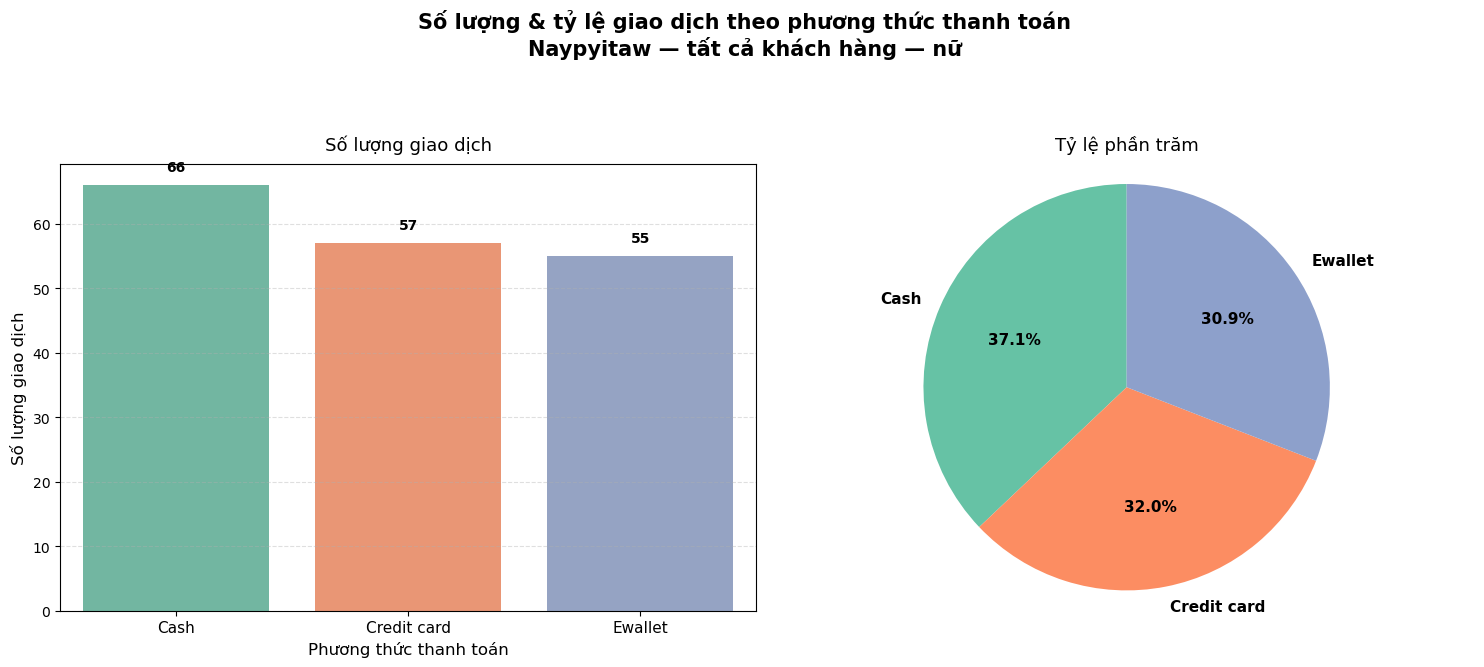

In [125]:
# Biểu đồ phương thức thanh toán của khách hàng nữ ở Naypyitaw
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Naypyitaw', gender='Female')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


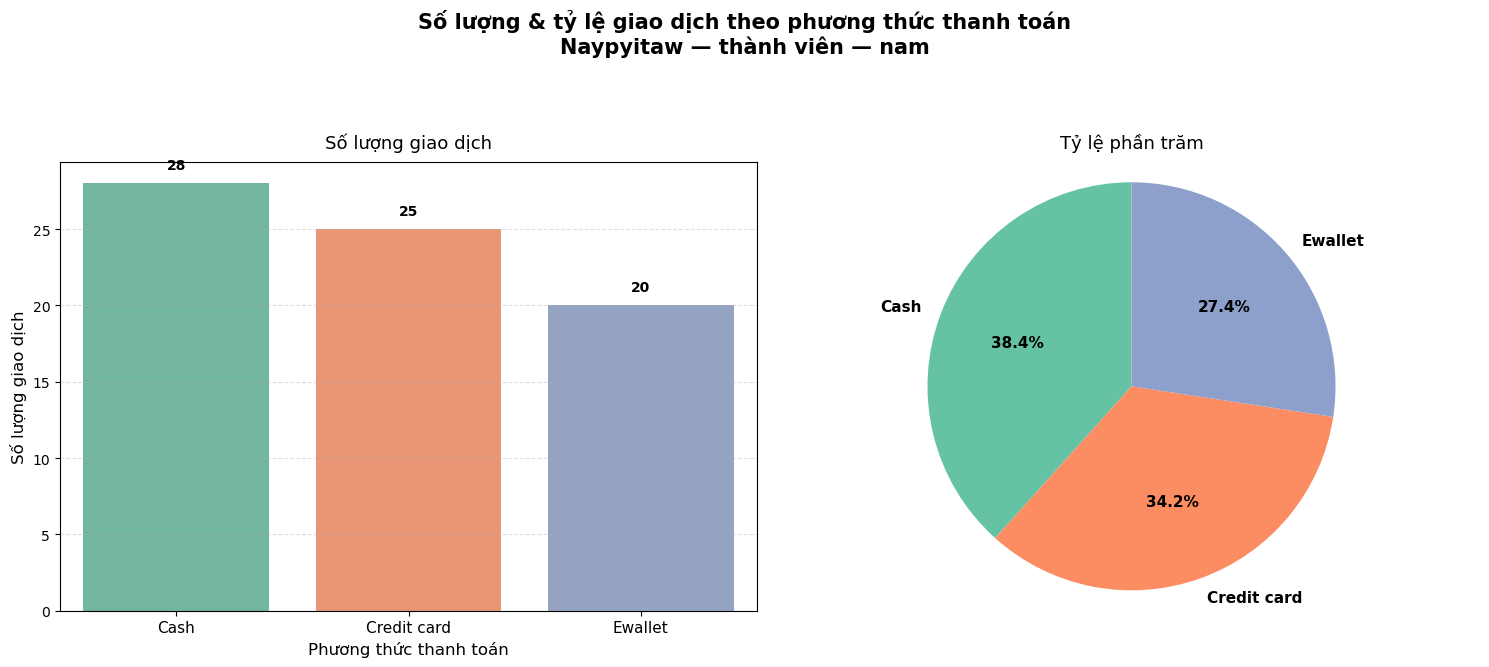

In [126]:
# biểu đồ phương thức thanh toán của khách hàng nam là thành viên ở Naypyitaw
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Naypyitaw', customer_type='Member', gender='Male')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


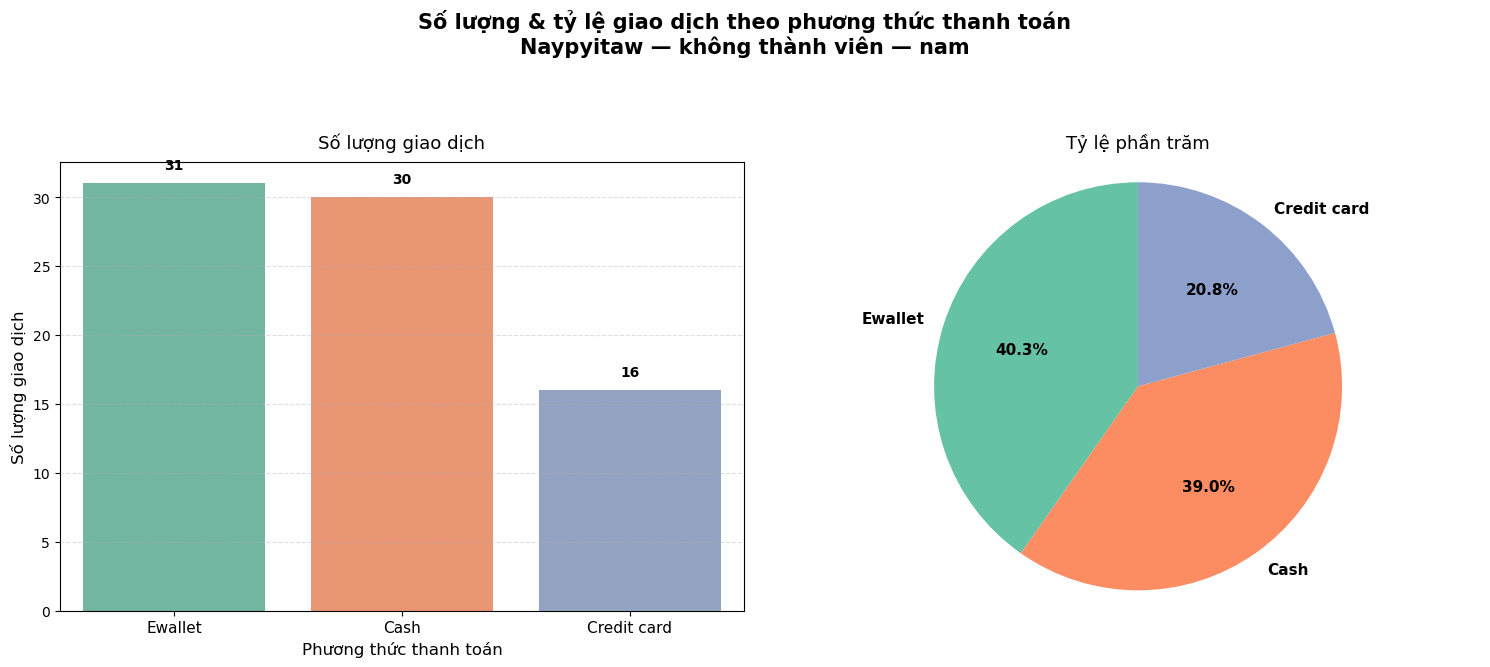

In [127]:
# Biểu đồ phương thức thanh toán của khách hàng nam không là thành viên ở Naypyitaw
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Naypyitaw', customer_type='Normal', gender='Male')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


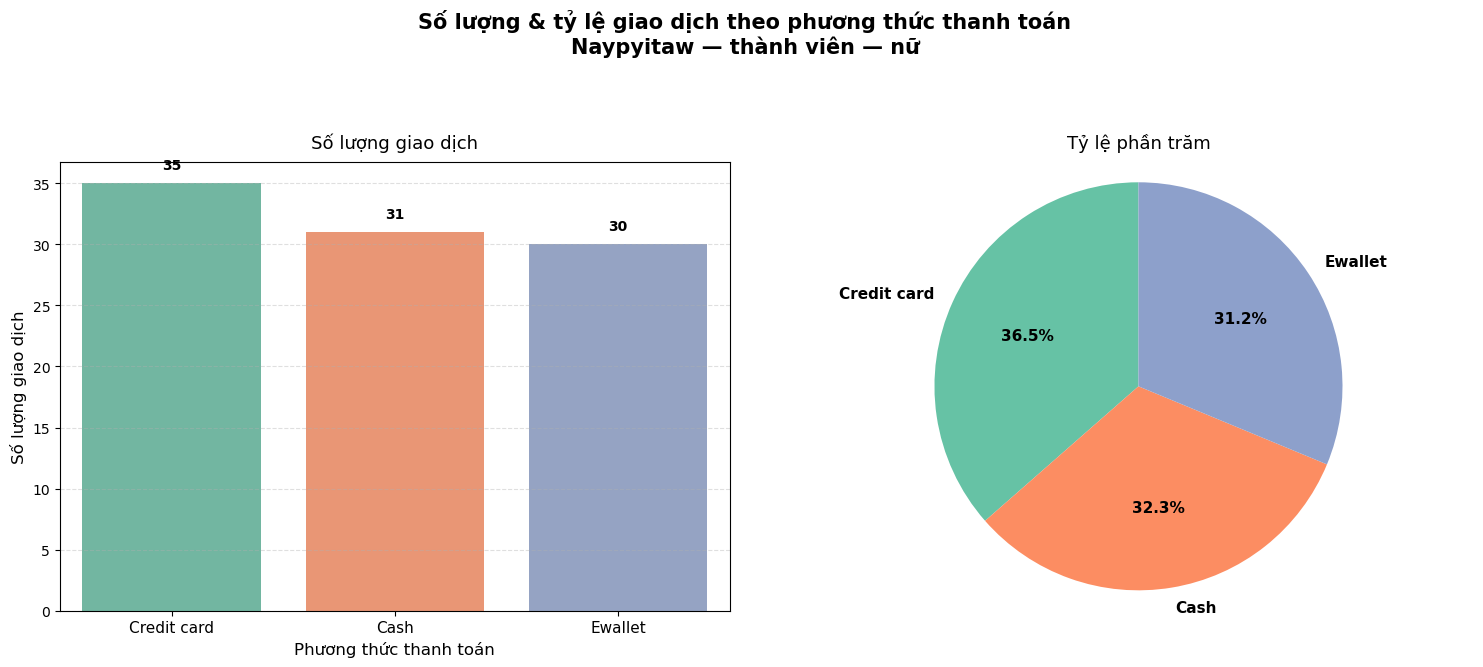

In [128]:
# Biểu đồ phương thức thanh toán của khách hàng nữ là thành viên ở Naypyitaw
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Naypyitaw', customer_type='Member', gender='Female')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3560334003.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


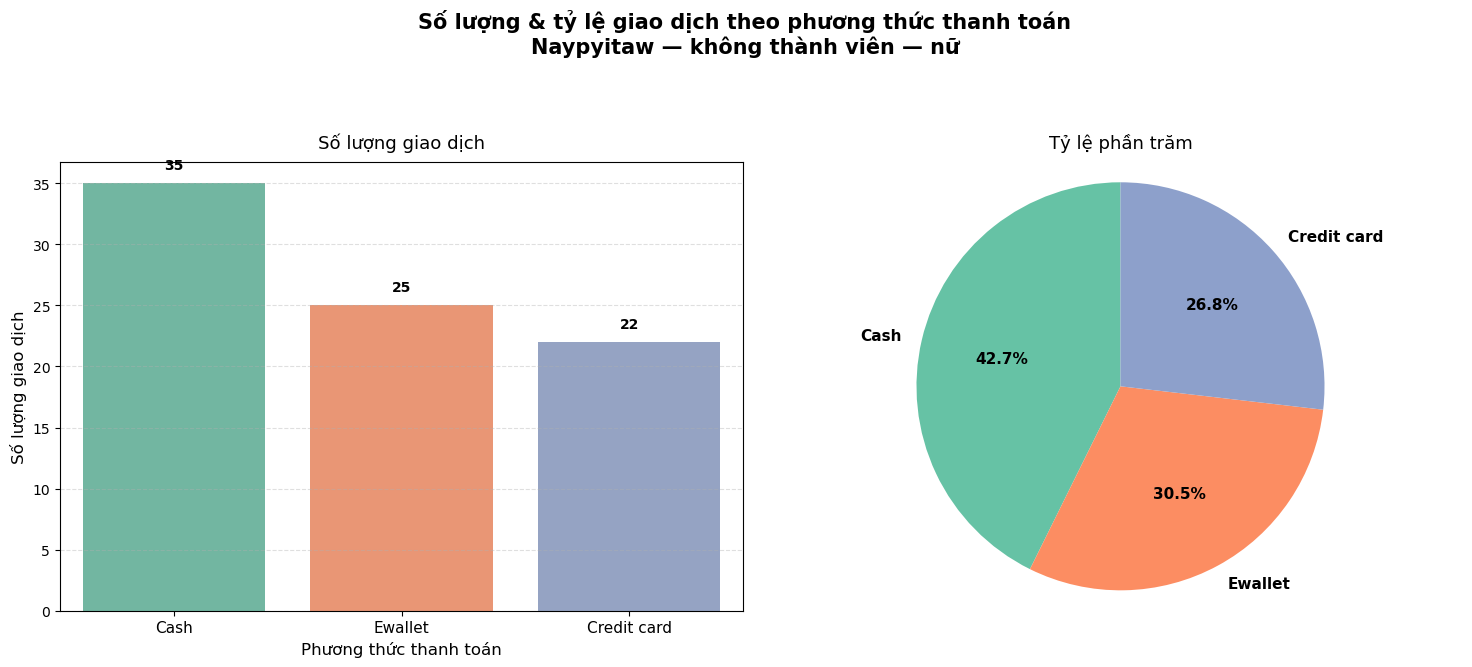

In [129]:
# Biểu đồ phương thức thanh toán của khách hàng nữ không là thành viên ở Naypyitaw
ve_bieu_do_ty_le_thanh_toan(supermarket_data_coppy, city='Naypyitaw', customer_type='Normal', gender='Female')

# Khách hàng chi tiêu trung như thế nào cho từng phương thức

In [130]:
# Đảm bảo cột Total là số
supermarket_data_coppy['Total'] = pd.to_numeric(supermarket_data_coppy['Total'], errors='coerce')

# Tạo các mask cho từng nhóm
member = supermarket_data_coppy['Customer type'] == 'Member'
normal = supermarket_data_coppy['Customer type'] == 'Normal'
male   = supermarket_data_coppy['Gender'] == 'Male'
female = supermarket_data_coppy['Gender'] == 'Female'

# Tính trung bình theo Payment cho từng nhóm
groups = {
    'Tổng quan': supermarket_data_coppy,
    '1. Member': supermarket_data_coppy[member],
    '2. Normal': supermarket_data_coppy[normal],
    '3. Nam': supermarket_data_coppy[male],
    '4. Nữ': supermarket_data_coppy[female],
    '5. Member Nam': supermarket_data_coppy[member & male],
    '6. Member Nữ': supermarket_data_coppy[member & female],
    '7. Normal Nam': supermarket_data_coppy[normal & male],
    '8. Normal Nữ': supermarket_data_coppy[normal & female]
}

# Tạo dataframe summary
summary_list = []
for name, sub_df in groups.items():
    if not sub_df.empty:
        avg = sub_df.groupby('Payment')['Total'].mean().reset_index()
        avg['Nhóm'] = name
        summary_list.append(avg)

df_summary = pd.concat(summary_list, ignore_index=True)
df_summary

,Payment,Total,Nhóm
0,Cash,326.181890,Tổng quan
1,Credit card,324.009878,Tổng quan
2,Ewallet,318.820600,Tổng quan
3,Cash,325.363187,1. Member
4,Credit card,335.880654,1. Member
5,Ewallet,321.682957,1. Member
6,Cash,326.963378,2. Normal
7,Credit card,309.320860,2. Normal
8,Ewallet,316.316038,2. Normal
9,Cash,317.423855,3. Nam


In [131]:
df_pivot = df_summary.pivot(index='Payment', columns='Nhóm', values='Total').reset_index()
df_pivot

Nhóm,Payment,1. Member,2. Normal,3. Nam,4. Nữ,5. Member Nam,6. Member Nữ,7. Normal Nam,8. Normal Nữ,Tổng quan
0,Cash,325.363187,326.963378,317.423855,334.349494,317.265173,332.381467,317.564506,336.362250,326.181890
1,Credit card,335.880654,309.320860,319.382615,328.211319,326.439238,344.482833,310.615295,308.150548,324.009878
2,Ewallet,321.682957,316.316038,297.961281,342.939188,307.022494,336.162426,291.057500,349.887513,318.820600


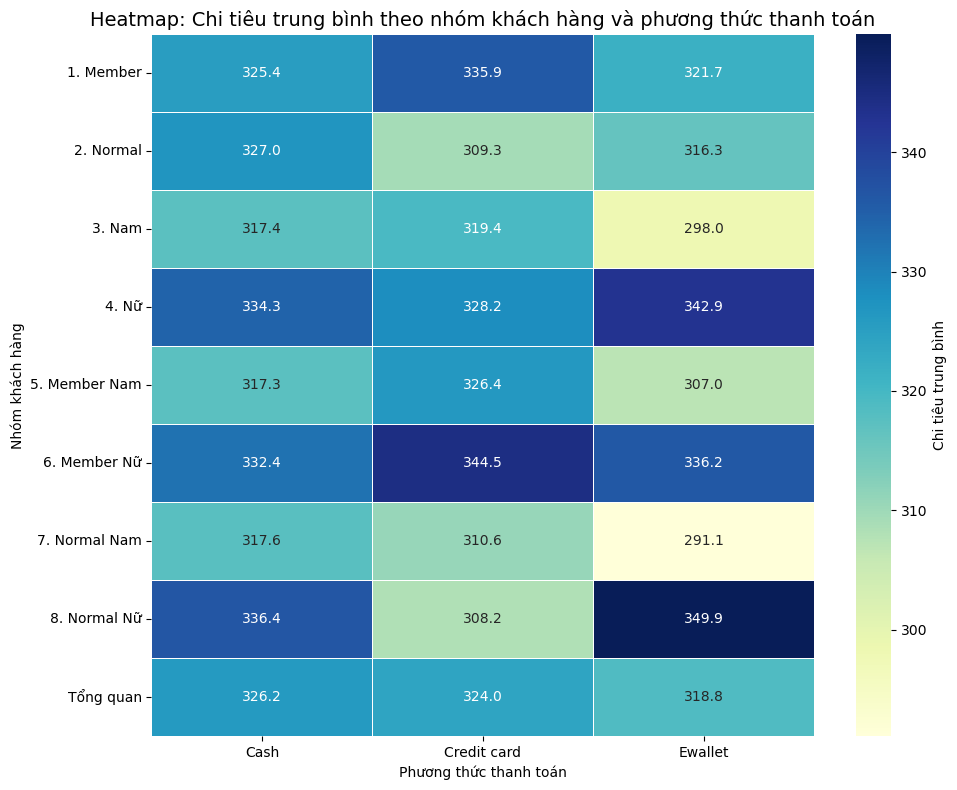

In [132]:
pivot = df_summary.pivot(index='Nhóm', columns='Payment', values='Total')

plt.figure(figsize=(10, 8))
sns.heatmap(
    pivot,
    annot=True,               # hiển thị số
    fmt='.1f',
    cmap='YlGnBu',            # hoặc 'Blues', 'viridis'
    linewidths=0.5,
    cbar_kws={'label': 'Chi tiêu trung bình'}
)

plt.title('Heatmap: Chi tiêu trung bình theo nhóm khách hàng và phương thức thanh toán', fontsize=14)
plt.xlabel('Phương thức thanh toán')
plt.ylabel('Nhóm khách hàng')
plt.tight_layout()
plt.show()

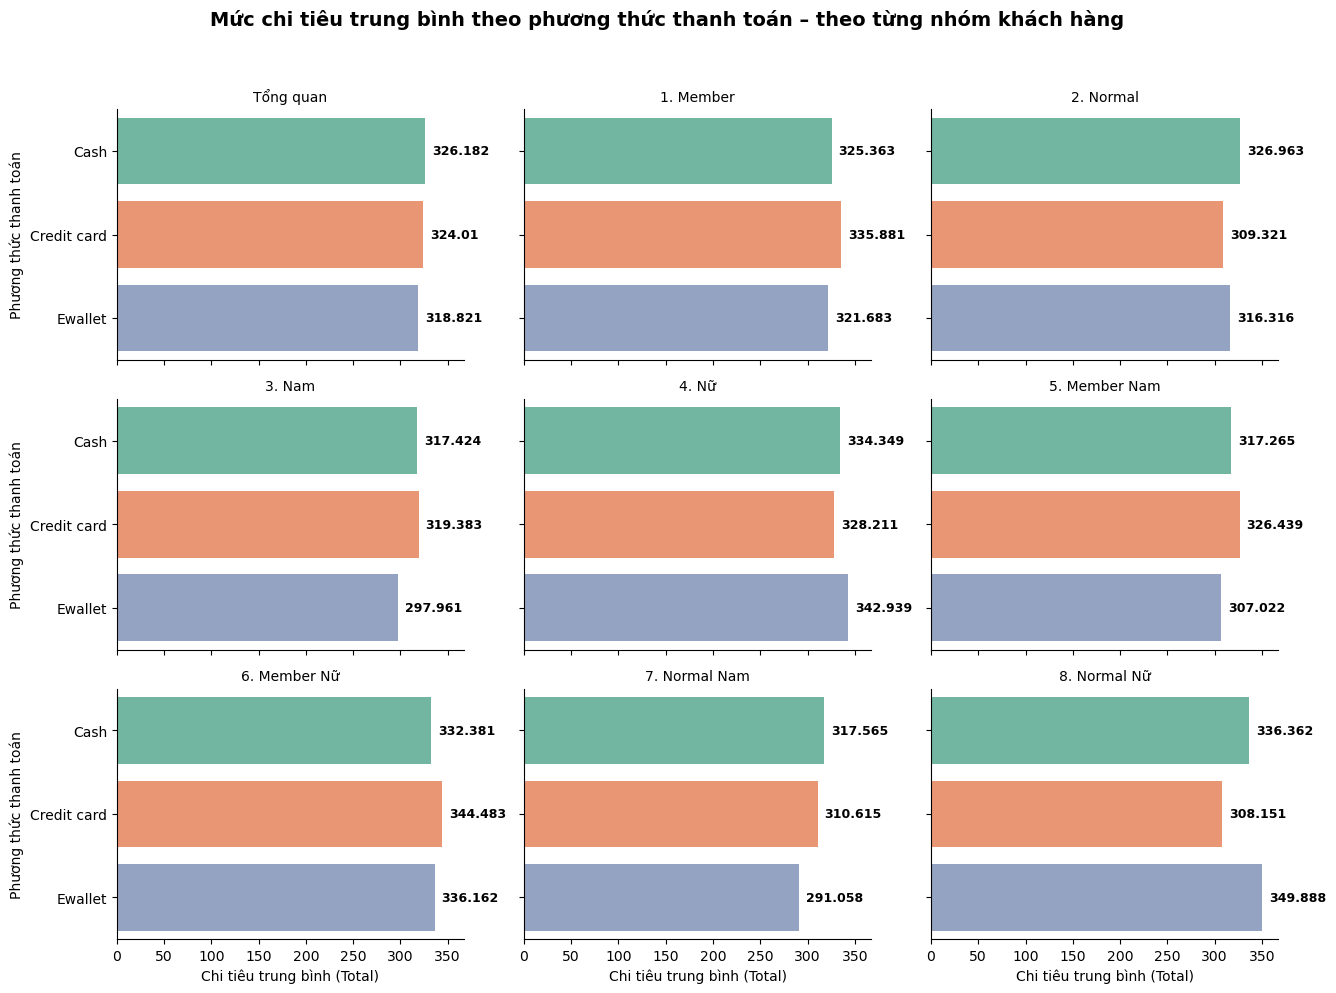

In [133]:
# Sắp xếp thứ tự nhóm (tùy ý, bạn có thể thay đổi)
group_order = [
    'Tổng quan',
    '1. Member', '2. Normal',
    '3. Nam', '4. Nữ',
    '5. Member Nam', '6. Member Nữ',
    '7. Normal Nam', '8. Normal Nữ'
]
df_summary['Nhóm'] = pd.Categorical(df_summary['Nhóm'], categories=group_order, ordered=True)
df_summary = df_summary.sort_values('Nhóm')

# Vẽ facet
g = sns.catplot(
    data=df_summary,
    kind='bar',
    x='Total',               # giá trị trung bình
    y='Payment',             # phương thức thanh toán (cột ngang)
    hue='Payment',           # màu khác nhau cho từng Payment
    col='Nhóm',              # mỗi nhóm một subplot
    col_wrap=3,              # sắp xếp 3 cột (có thể đổi thành 2 hoặc 4)
    height=3.2,              # chiều cao mỗi subplot
    aspect=1.4,              # tỷ lệ chiều rộng / cao
    palette='Set2',
    dodge=False,             # không cần dodge vì hue trùng y
    sharex=True              # cùng tỷ lệ trục x để dễ so sánh
)

# Tùy chỉnh
g.set_titles("{col_name}")
g.set_axis_labels("Chi tiêu trung bình (Total)", "Phương thức thanh toán")
g.fig.suptitle("Mức chi tiêu trung bình theo phương thức thanh toán – theo từng nhóm khách hàng",
               y=1.03, fontsize=14, fontweight='bold')

# Thêm giá trị số lên thanh
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, padding=5, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Khách hàng chi tiêu như thế nào theo khung thời gian

## 1. Tổng quan (Overall)

In [134]:
# Tổng chi tiêu, trung bình hóa đơn và số giao dịch theo giờ trong ngày là bao nhiêu?
supermarket_data_coppy['Hour'] = supermarket_data_coppy['Time'].dt.hour
hourly_summary = supermarket_data_coppy.groupby('Hour').agg(
    Total_Spent=('Total', 'sum'),
    Avg_Bill=('Total', 'mean'),
    Transaction_Count=('Total', 'count')
).reset_index()
hourly_summary

,Hour,Total_Spent,Avg_Bill,Transaction_Count
0,10,31421.4810,311.103772,101
1,11,30377.3295,337.525883,90
2,12,26065.8825,292.875084,89
3,13,34723.2270,337.118709,103
4,14,30828.3990,371.426494,83
5,15,31179.5085,305.681456,102
6,16,25226.3235,327.614591,77
7,17,24445.2180,330.340784,74
8,18,26030.3400,279.896129,93
9,19,39699.5130,351.323124,113


C:\Users\Admin\AppData\Local\Temp\ipykernel_23988\3300667347.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hourly_summary, x='Hour', y='Total_Spent', palette='Blues_d')


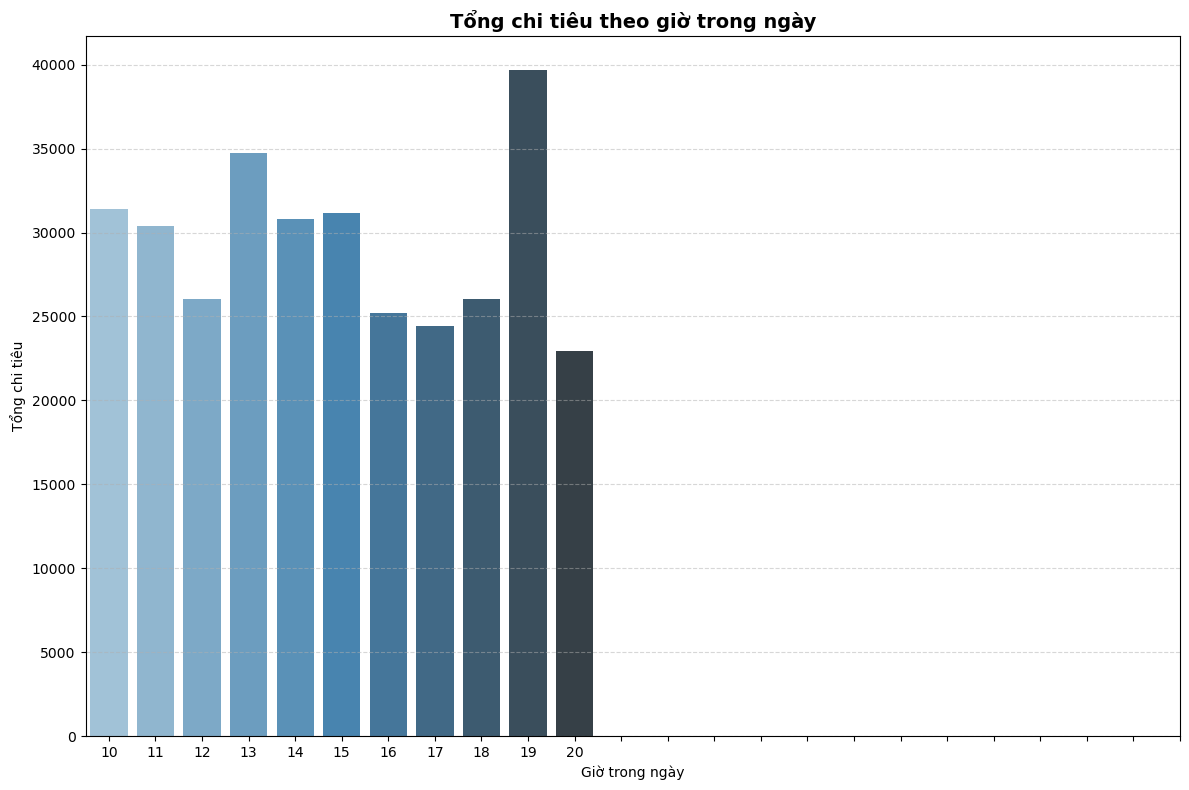

In [135]:
# Vẽ biểu đồ cột cho từng nhóm khách hàng
plt.figure(figsize=(12, 8))
sns.barplot(data=hourly_summary, x='Hour', y='Total_Spent', palette='Blues_d')
plt.title('Tổng chi tiêu theo giờ trong ngày', fontsize=14, fontweight='bold')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Tổng chi tiêu')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [136]:
#Khung giờ nào và ngày nào trong tuần khách hàng chi tiêu nhiều nhất?
supermarket_data_coppy['DayOfWeek'] = supermarket_data_coppy['Date'].dt.day_name()
supermarket_data_coppy['Hour'] = supermarket_data_coppy['Time'].dt.hour
peak_summary = supermarket_data_coppy.groupby(['DayOfWeek', 'Hour']).agg(
    Total_Spent=('Total', 'sum'),
    Avg_Bill=('Total', 'mean'),
    Transaction_Count=('Total', 'count')
).reset_index()
# Sắp xếp thứ tự ngày trong tuần
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
peak_summary['DayOfWeek'] = pd.Categorical(peak_summary['DayOfWeek'], categories=days_order, ordered=True)
peak_summary = peak_summary.sort_values(['DayOfWeek', 'Hour'])
peak_summary

,DayOfWeek,Hour,Total_Spent,Avg_Bill,Transaction_Count
11,Monday,10,2066.7045,187.882227,11
12,Monday,11,2566.2105,285.134500,9
13,Monday,12,4235.6055,385.055045,11
14,Monday,13,3803.0370,292.541308,13
15,Monday,14,3069.3180,383.664750,8
...,...,...,...,...,...
39,Sunday,16,4666.6515,358.973192,13
40,Sunday,17,5090.2215,391.555500,13
41,Sunday,18,4214.1540,247.891412,17
42,Sunday,19,6816.5055,340.825275,20


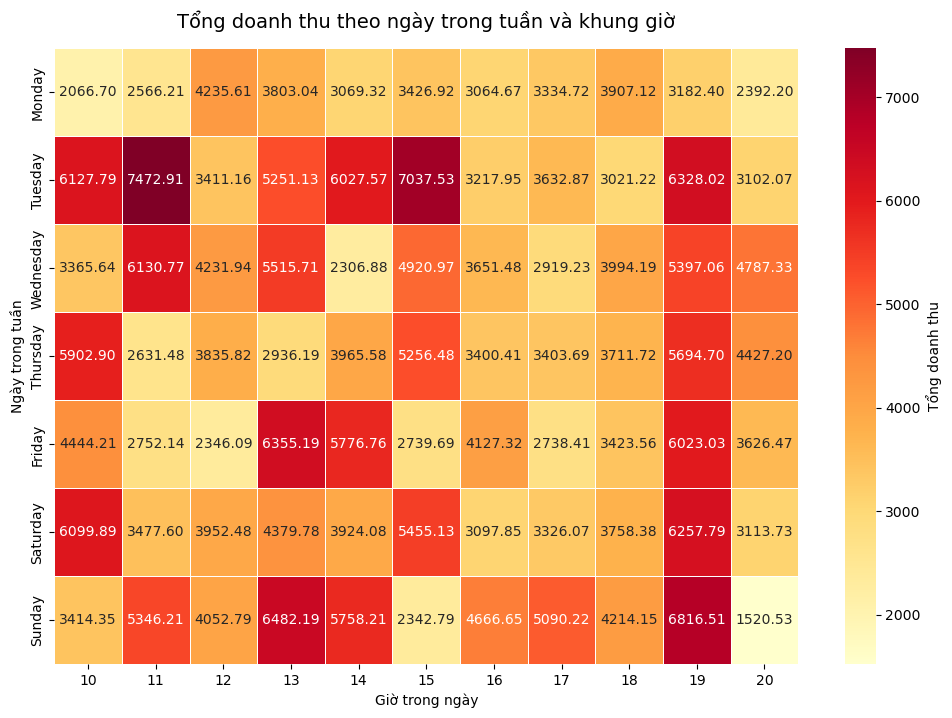

In [137]:
plt.figure(figsize=(12, 8))
pivot_table = peak_summary.pivot(index='DayOfWeek', columns='Hour', values='Total_Spent')

sns.heatmap(
    pivot_table,
    cmap='YlOrRd',          # hoặc 'Reds', 'viridis', 'magma'
    annot=True,             # hiển thị số
    fmt=".2f",              # không thập phân
    linewidths=0.5,
    cbar_kws={'label': 'Tổng doanh thu'}
)

plt.title('Tổng doanh thu theo ngày trong tuần và khung giờ', fontsize=14, pad=15)
plt.xlabel('Giờ trong ngày')
plt.ylabel('Ngày trong tuần')
plt.show()

## Khách hàng Nam

In [138]:
def plot_spending_by_group(df, group_name, condition):
    # Lọc dữ liệu theo nhóm
    subgroup = df.query(condition)
    
    # Tính tổng chi tiêu theo giờ cho biểu đồ cột ngang top 5
    hour_summary = subgroup.groupby('Hour')['Total'].sum().reset_index(name='Total_Spent')
    hour_summary = hour_summary.sort_values('Total_Spent', ascending=False).reset_index(drop=True)
    top5 = hour_summary.head(5)
    
    # Lấy danh sách giờ cho top 5
    hours_present = top5['Hour'].astype(int).tolist()
    labels = [f'{h:02d}h' for h in hours_present]
    
    # Tính max và offset cho text
    max_spent = top5['Total_Spent'].max()
    offset = max_spent * 0.015
    
    # Vẽ biểu đồ cột ngang
    plt.figure(figsize=(12, 6))
    bars = plt.barh(
        y=range(len(hours_present)),
        width=top5['Total_Spent'],
        color='skyblue',
        edgecolor='navy',
        height=0.7,
        tick_label=labels
    )
    
    # Thêm số lên cuối mỗi cột
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width + offset,
            bar.get_y() + bar.get_height()/2,
            f'{width:,.0f}',
            ha='left',
            va='center',
            fontsize=9,
            fontweight='bold'
        )
    
    plt.title(f'Các khung giờ chi tiêu cao nhất của {group_name}',
              fontsize=14, fontweight='bold')
    plt.ylabel('Giờ trong ngày')
    plt.xlabel('Tổng chi tiêu')
    plt.yticks(rotation=0)
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.xlim(0, max_spent * 1.12)
    plt.tight_layout()
    plt.show()
    
    # Tính tổng chi tiêu theo ngày trong tuần và giờ cho heatmap
    pivot_table = subgroup.groupby(['DayOfWeek', 'Hour'])['Total'].sum().reset_index(name='Total_Spent')
    pivot_table = pivot_table.pivot(index='DayOfWeek', columns='Hour', values='Total_Spent')
    
    # Vẽ heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(
        pivot_table,
        cmap='YlGnBu',
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        cbar_kws={'label': f'Tổng chi tiêu của {group_name}'}
    )
    plt.title(f'Tổng chi tiêu của {group_name} theo ngày trong tuần và khung giờ', fontsize=14, pad=15)
    plt.xlabel('Giờ trong ngày')
    plt.ylabel('Ngày trong tuần')
    plt.show()

In [139]:
# Nam giới chi tiêu nhiều nhất vào khung giờ nào trong ngày?
male_data = supermarket_data_coppy[supermarket_data_coppy['Gender'] == 'Male'] 
male_peak_summary = male_data.groupby(['DayOfWeek', 'Hour']).agg(
    Total_Spent=('Total', 'sum'),
    Avg_Bill=('Total', 'mean'),
    Transaction_Count=('Total', 'count')
).reset_index()
male_peak_summary['DayOfWeek'] = pd.Categorical(male_peak_summary['DayOfWeek'], categories=days_order, ordered=True)
male_peak_summary = male_peak_summary.sort_values(['DayOfWeek', 'Hour'])
male_peak_summary

,DayOfWeek,Hour,Total_Spent,Avg_Bill,Transaction_Count
11,Monday,10,1538.5440,307.708800,5
12,Monday,11,1285.8300,321.457500,4
13,Monday,12,2758.6440,394.092000,7
14,Monday,13,1076.5755,153.796500,7
15,Monday,14,491.0220,245.511000,2
...,...,...,...,...,...
39,Sunday,16,2030.8050,406.161000,5
40,Sunday,17,976.3635,244.090875,4
41,Sunday,18,2057.3910,342.898500,6
42,Sunday,19,3504.4275,350.442750,10


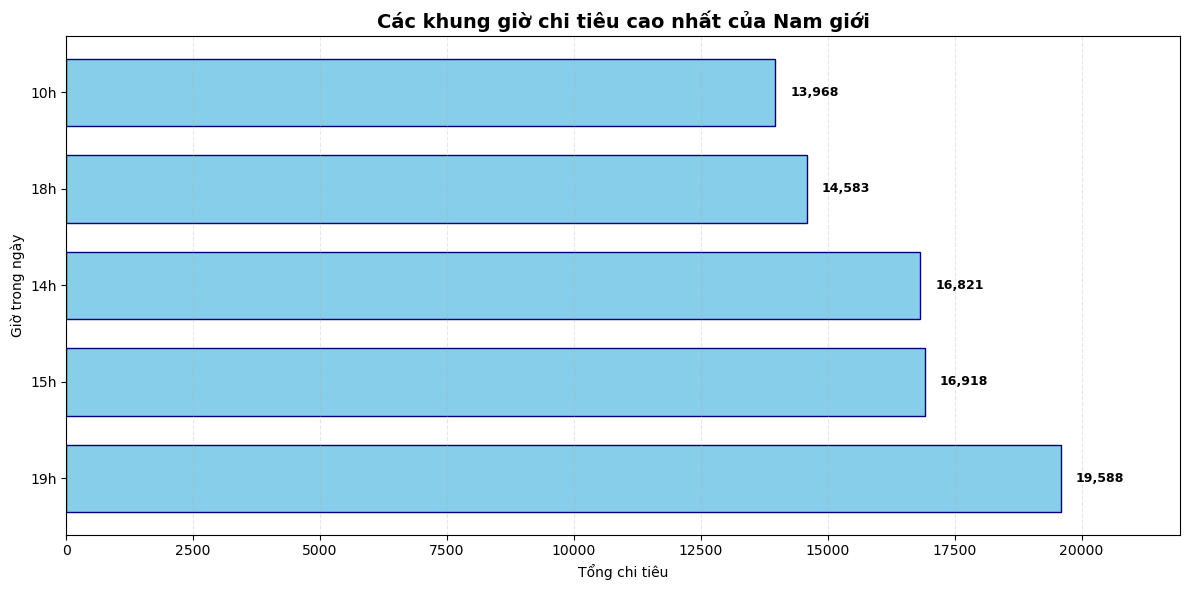

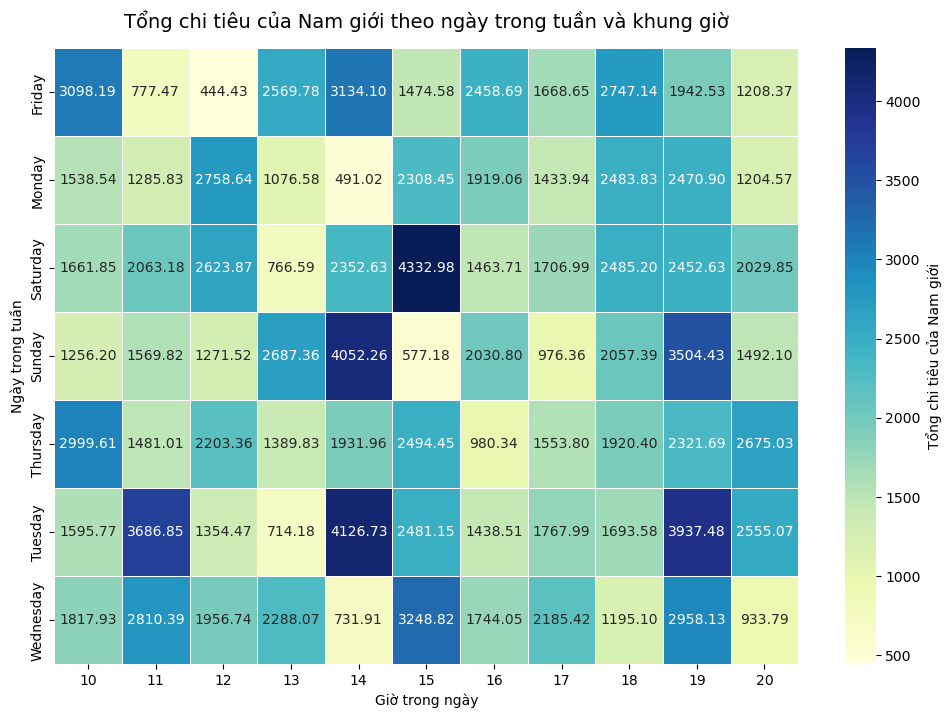

In [140]:
plot_spending_by_group(male_data, 'Nam giới', 'Gender == "Male"')

## Khách hàng nữ

In [141]:
# Nữ giới chi tiêu nhiều nhất vào khung giờ nào trong ngày?
female_data = supermarket_data_coppy[supermarket_data_coppy['Gender'] == 'Female'] 
female_peak_summary = male_data.groupby(['DayOfWeek', 'Hour']).agg(
    Total_Spent=('Total', 'sum'),
    Avg_Bill=('Total', 'mean'),
    Transaction_Count=('Total', 'count')
).reset_index()
female_peak_summary['DayOfWeek'] = pd.Categorical(female_peak_summary['DayOfWeek'], categories=days_order, ordered=True)
female_peak_summary = female_peak_summary.sort_values(['DayOfWeek', 'Hour'])
female_peak_summary

,DayOfWeek,Hour,Total_Spent,Avg_Bill,Transaction_Count
11,Monday,10,1538.5440,307.708800,5
12,Monday,11,1285.8300,321.457500,4
13,Monday,12,2758.6440,394.092000,7
14,Monday,13,1076.5755,153.796500,7
15,Monday,14,491.0220,245.511000,2
...,...,...,...,...,...
39,Sunday,16,2030.8050,406.161000,5
40,Sunday,17,976.3635,244.090875,4
41,Sunday,18,2057.3910,342.898500,6
42,Sunday,19,3504.4275,350.442750,10


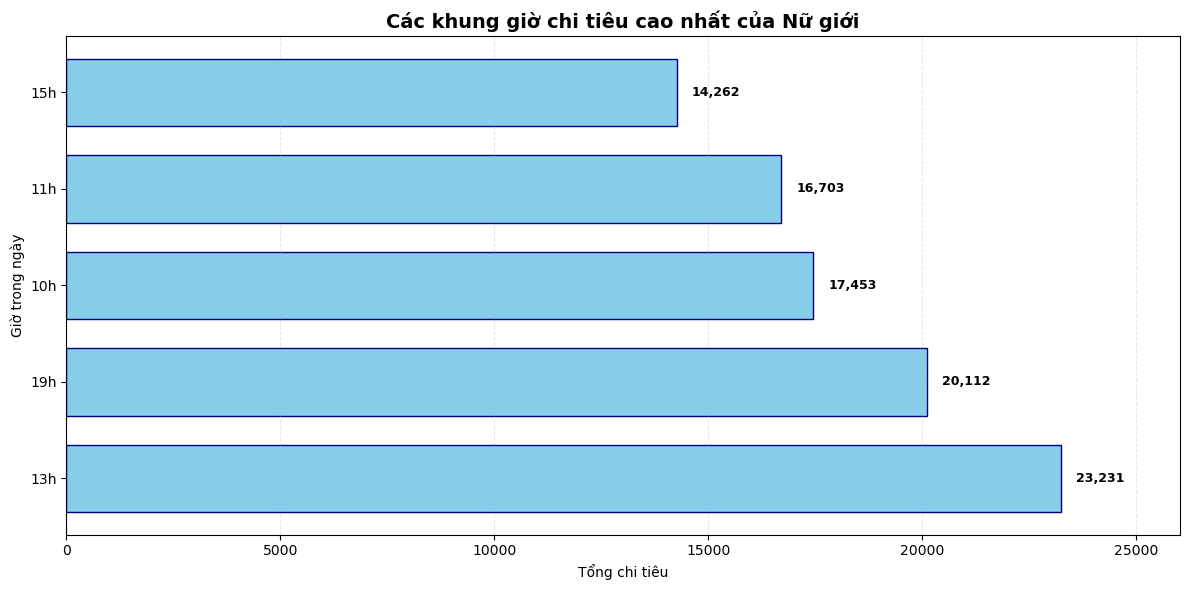

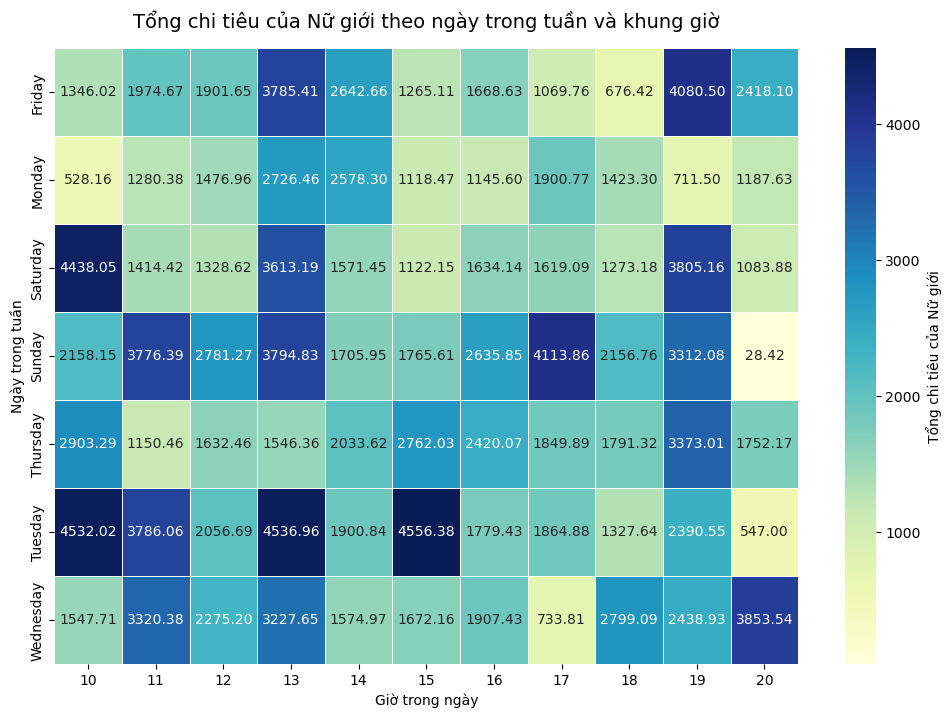

In [142]:
plot_spending_by_group(female_data, 'Nữ giới', 'Gender == "Female"')

## Khách hàng thành viên

In [143]:
# Khách hàng thành viên chi tiêu nhiều nhất vào khung giờ nào trong ngày?
member_data = supermarket_data_coppy[supermarket_data_coppy['Customer type'] == 'Member'] 
member_data_summary = male_data.groupby(['DayOfWeek', 'Hour']).agg(
    Total_Spent=('Total', 'sum'),
    Avg_Bill=('Total', 'mean'),
    Transaction_Count=('Total', 'count')
).reset_index()
member_data_summary['DayOfWeek'] = pd.Categorical(member_data_summary['DayOfWeek'], categories=days_order, ordered=True)
member_data_summary = member_data_summary.sort_values(['DayOfWeek', 'Hour'])
member_data_summary

,DayOfWeek,Hour,Total_Spent,Avg_Bill,Transaction_Count
11,Monday,10,1538.5440,307.708800,5
12,Monday,11,1285.8300,321.457500,4
13,Monday,12,2758.6440,394.092000,7
14,Monday,13,1076.5755,153.796500,7
15,Monday,14,491.0220,245.511000,2
...,...,...,...,...,...
39,Sunday,16,2030.8050,406.161000,5
40,Sunday,17,976.3635,244.090875,4
41,Sunday,18,2057.3910,342.898500,6
42,Sunday,19,3504.4275,350.442750,10


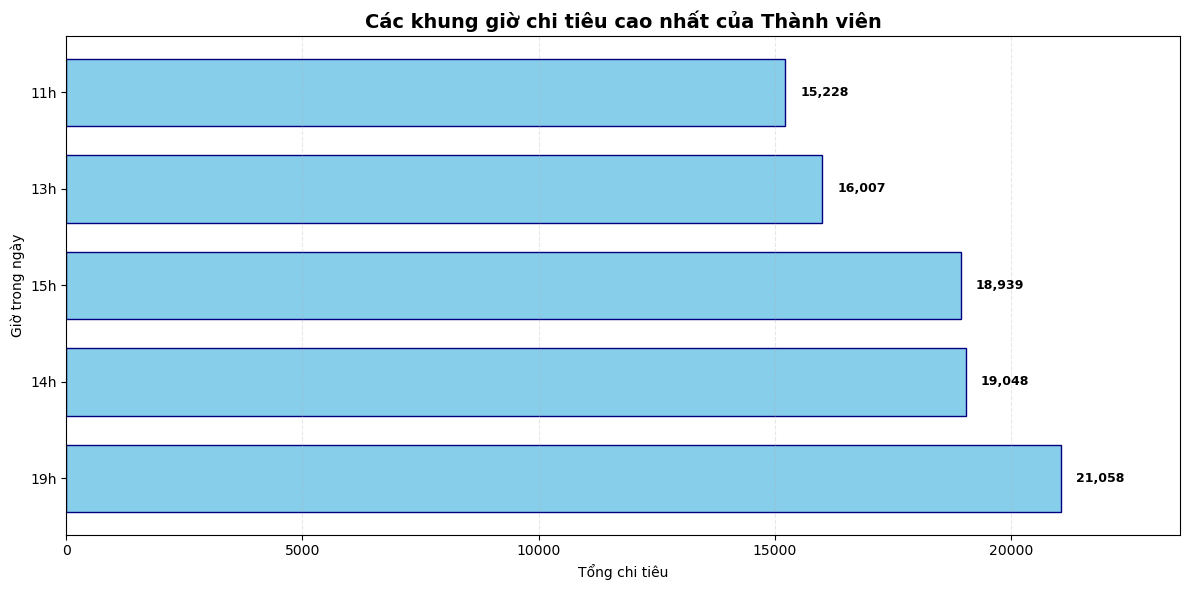

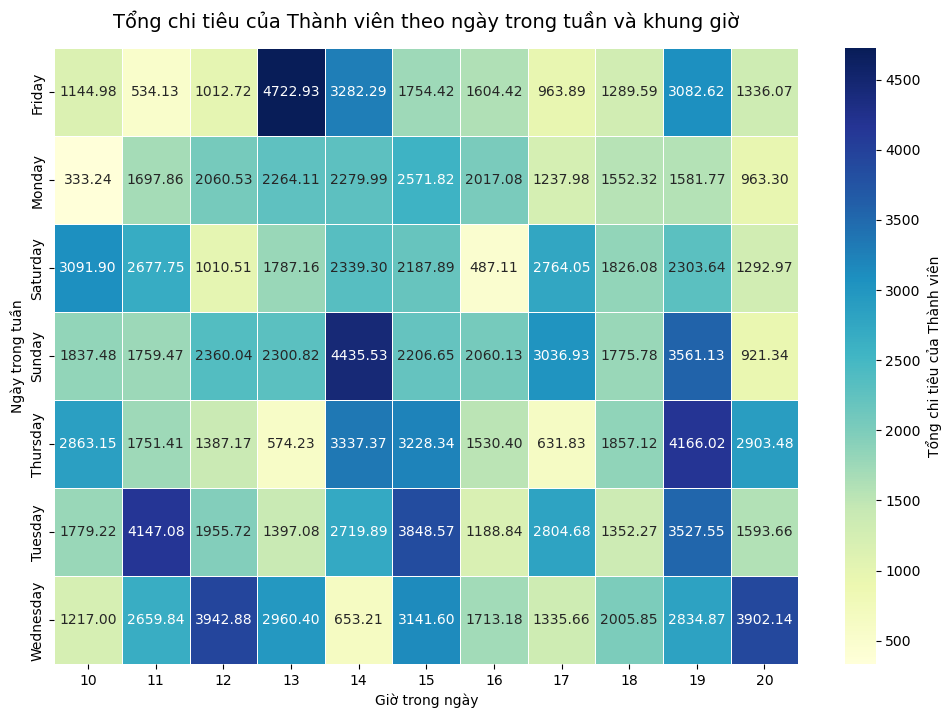

In [144]:
plot_spending_by_group(member_data, 'Thành viên', "`Customer type` == 'Member'")

## Khách hàng thành bình thường

In [145]:
# Khách hàng thành viên chi tiêu nhiều nhất vào khung giờ nào trong ngày?
normal_data = supermarket_data_coppy[supermarket_data_coppy['Customer type'] == 'Normal'] 
normal_data_summary = normal_data.groupby(['DayOfWeek', 'Hour']).agg(
    Total_Spent=('Total', 'sum'),
    Avg_Bill=('Total', 'mean'),
    Transaction_Count=('Total', 'count')
).reset_index()
normal_data_summary['DayOfWeek'] = pd.Categorical(normal_data_summary['DayOfWeek'], categories=days_order, ordered=True)
normal_data_summary = normal_data_summary.sort_values(['DayOfWeek', 'Hour'])
normal_data_summary

,DayOfWeek,Hour,Total_Spent,Avg_Bill,Transaction_Count
11,Monday,10,1733.4660,216.683250,8
12,Monday,11,868.3500,434.175000,2
13,Monday,12,2175.0750,435.015000,5
14,Monday,13,1538.9220,256.487000,6
15,Monday,14,789.3270,263.109000,3
...,...,...,...,...,...
39,Sunday,16,2606.5200,434.420000,6
40,Sunday,17,2053.2960,410.659200,5
41,Sunday,18,2438.3730,270.930333,9
42,Sunday,19,3255.3780,325.537800,10


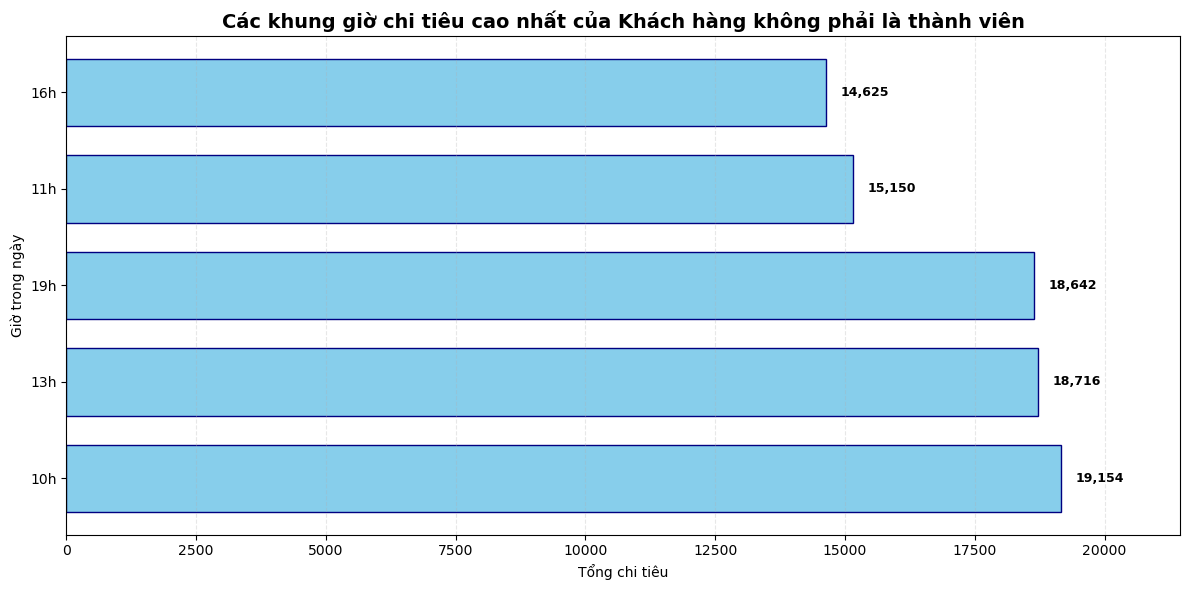

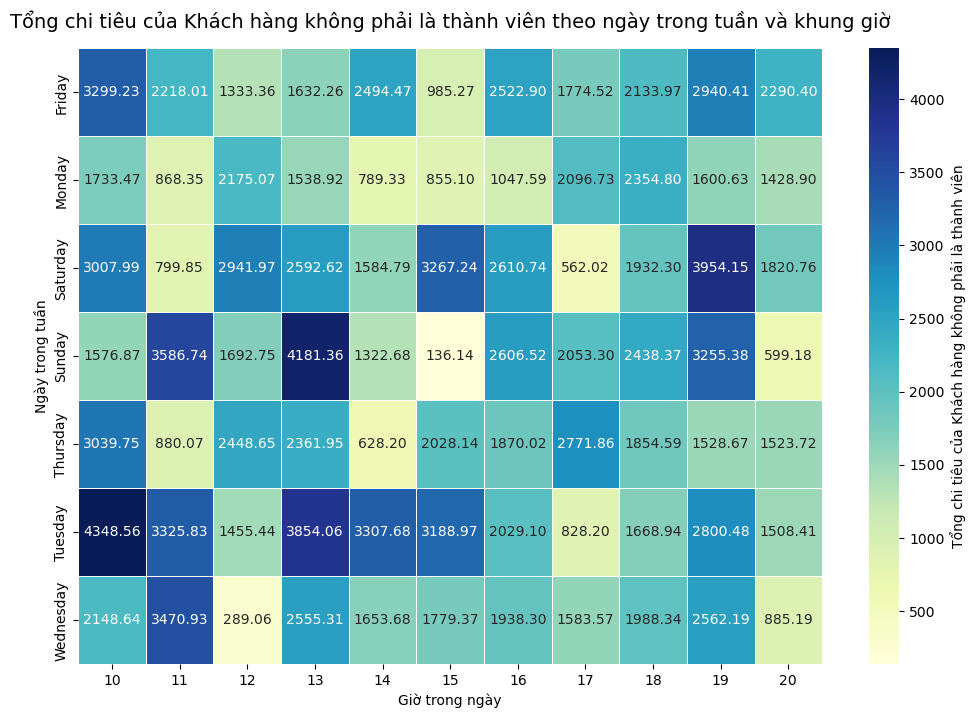

In [146]:
# Khách hàng không là thành viên
plot_spending_by_group(normal_data, 'Khách hàng không phải là thành viên', "`Customer type` == 'Normal'")


## Khách hàng nam là thành viên

In [147]:
# Khách hàng nam là thành viên chi tiêu nhiều nhất vào khung giờ nào trong ngày?
male_member_data = supermarket_data_coppy[
    (supermarket_data_coppy['Customer type'] == 'Member') &
    (supermarket_data_coppy['Gender'] == 'Male')
]

male_member_data_summary = male_data.groupby(['DayOfWeek', 'Hour']).agg(
    Total_Spent=('Total', 'sum'),
    Avg_Bill=('Total', 'mean'),
    Transaction_Count=('Total', 'count')
).reset_index()
male_member_data_summary['DayOfWeek'] = pd.Categorical(male_member_data_summary['DayOfWeek'], categories=days_order, ordered=True)
male_member_data_summary = male_member_data_summary.sort_values(['DayOfWeek', 'Hour'])
male_member_data_summary

,DayOfWeek,Hour,Total_Spent,Avg_Bill,Transaction_Count
11,Monday,10,1538.5440,307.708800,5
12,Monday,11,1285.8300,321.457500,4
13,Monday,12,2758.6440,394.092000,7
14,Monday,13,1076.5755,153.796500,7
15,Monday,14,491.0220,245.511000,2
...,...,...,...,...,...
39,Sunday,16,2030.8050,406.161000,5
40,Sunday,17,976.3635,244.090875,4
41,Sunday,18,2057.3910,342.898500,6
42,Sunday,19,3504.4275,350.442750,10


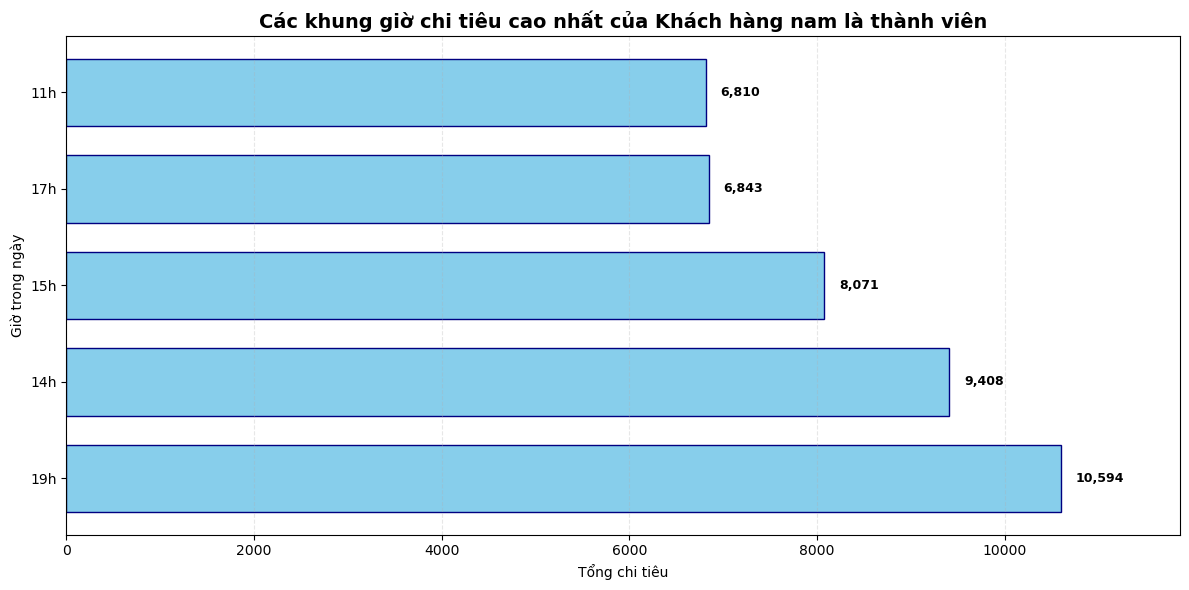

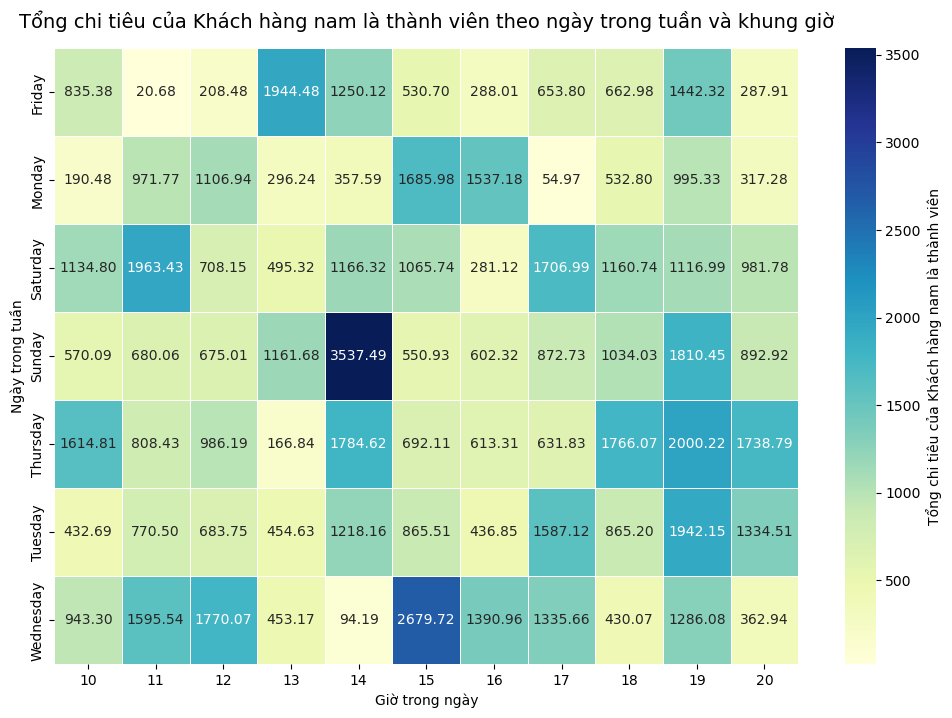

In [148]:
plot_spending_by_group(male_member_data, 'Khách hàng nam là thành viên', "`Customer type` == 'Member'")

## Khách hàng nam không là thành viên

In [149]:
# Khách hàng nam là thành viên chi tiêu nhiều nhất vào khung giờ nào trong ngày?
male_normal_data = supermarket_data_coppy[
    (supermarket_data_coppy['Customer type'] == 'Normal') &
    (supermarket_data_coppy['Gender'] == 'Male')
]

male_normal_data_summary = male_normal_data.groupby(['DayOfWeek', 'Hour']).agg(
    Total_Spent=('Total', 'sum'),
    Avg_Bill=('Total', 'mean'),
    Transaction_Count=('Total', 'count')
).reset_index()
male_normal_data_summary['DayOfWeek'] = pd.Categorical(male_normal_data_summary['DayOfWeek'], categories=days_order, ordered=True)
male_normal_data_summary = male_normal_data_summary.sort_values(['DayOfWeek', 'Hour'])
male_normal_data_summary

,DayOfWeek,Hour,Total_Spent,Avg_Bill,Transaction_Count
11,Monday,10,1348.0635,337.015875,4
12,Monday,11,314.0550,314.055000,1
13,Monday,12,1651.7025,412.925625,4
14,Monday,13,780.3390,195.084750,4
15,Monday,14,133.4340,133.434000,1
...,...,...,...,...,...
38,Sunday,16,1428.4830,476.161000,3
39,Sunday,17,103.6350,103.635000,1
40,Sunday,18,1023.3615,341.120500,3
41,Sunday,19,1693.9755,282.329250,6


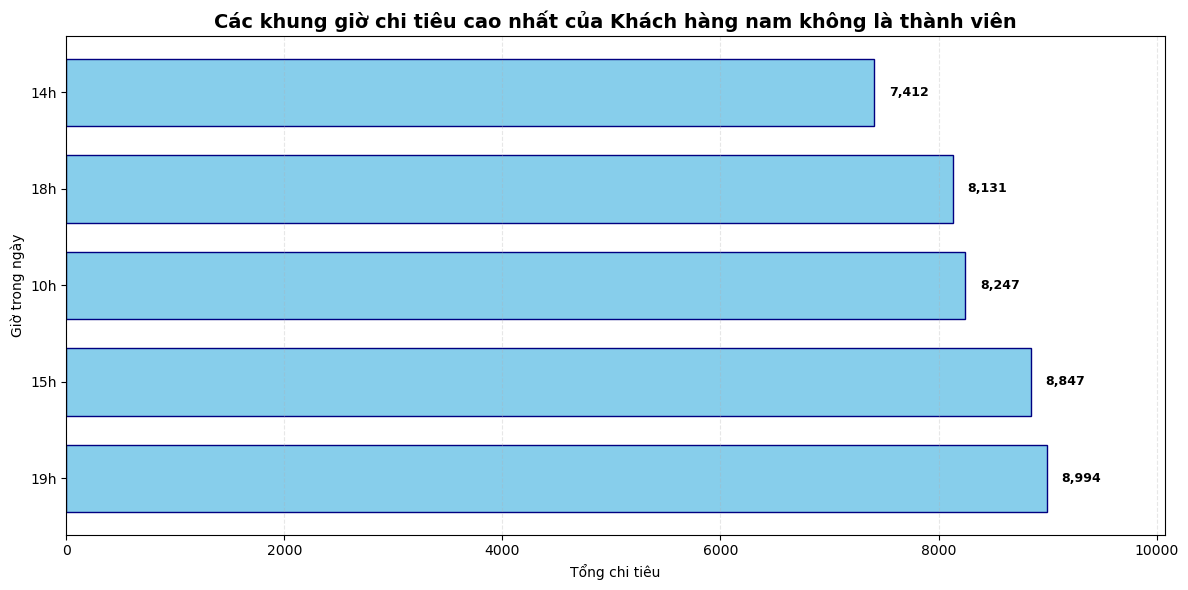

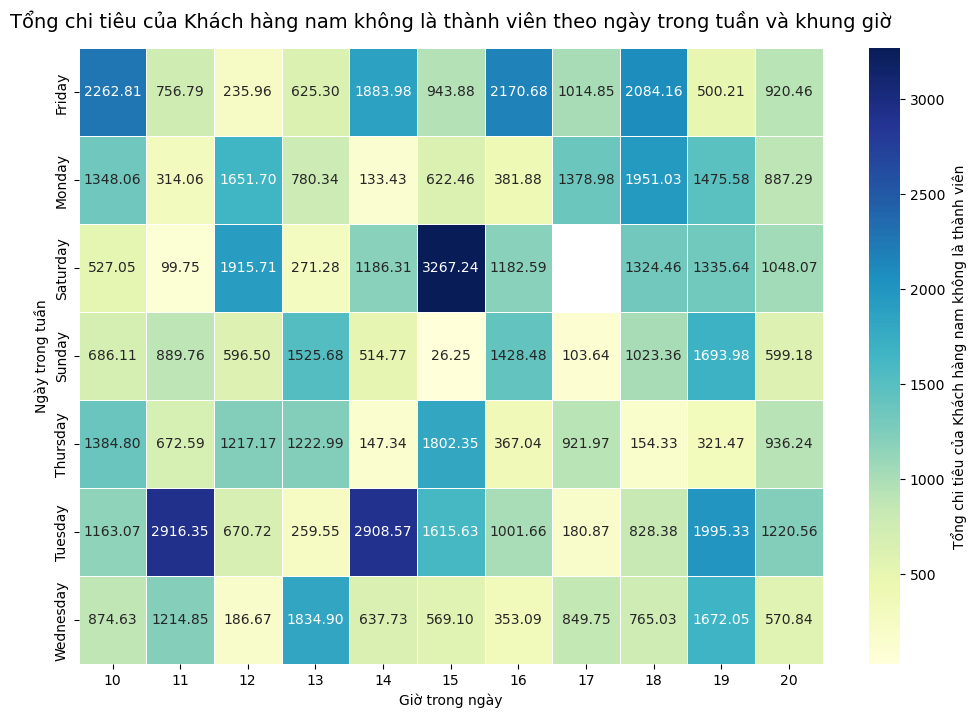

In [150]:
plot_spending_by_group(male_normal_data, 'Khách hàng nam không là thành viên', "`Customer type` == 'Normal'")

## Khách hàng nữ là thành viên

In [151]:
# Khách hàng nam là thành viên chi tiêu nhiều nhất vào khung giờ nào trong ngày?
female_member_data = supermarket_data_coppy[
    (supermarket_data_coppy['Customer type'] == 'Member') &
    (supermarket_data_coppy['Gender'] == 'Female')
]

female_member_data_summary = female_member_data.groupby(['DayOfWeek', 'Hour']).agg(
    Total_Spent=('Total', 'sum'),
    Avg_Bill=('Total', 'mean'),
    Transaction_Count=('Total', 'count')
).reset_index()
female_member_data_summary['DayOfWeek'] = pd.Categorical(female_member_data_summary['DayOfWeek'], categories=days_order, ordered=True)
female_member_data_summary = female_member_data_summary.sort_values(['DayOfWeek', 'Hour'])
female_member_data_summary

,DayOfWeek,Hour,Total_Spent,Avg_Bill,Transaction_Count
11,Monday,10,142.7580,71.379000,2
12,Monday,11,726.0855,181.521375,4
13,Monday,12,953.5890,317.863000,3
14,Monday,13,1967.8785,491.969625,4
15,Monday,14,1922.4030,480.600750,4
...,...,...,...,...,...
39,Sunday,16,1457.8095,291.561900,5
40,Sunday,17,2164.1970,432.839400,5
41,Sunday,18,741.7515,148.350300,5
42,Sunday,19,1750.6755,291.779250,6


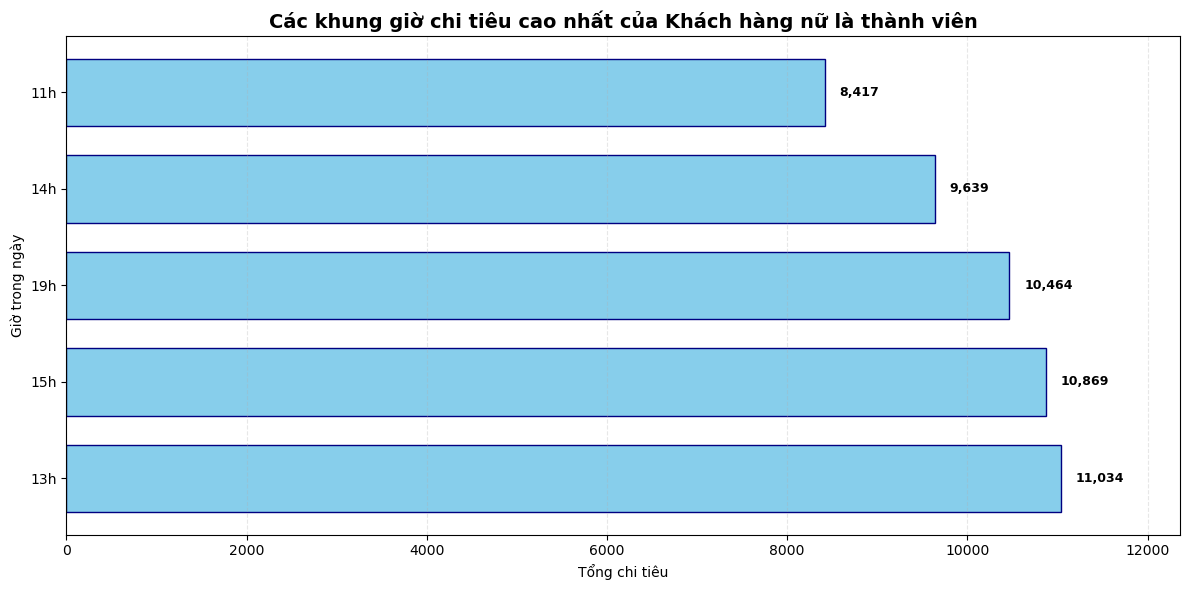

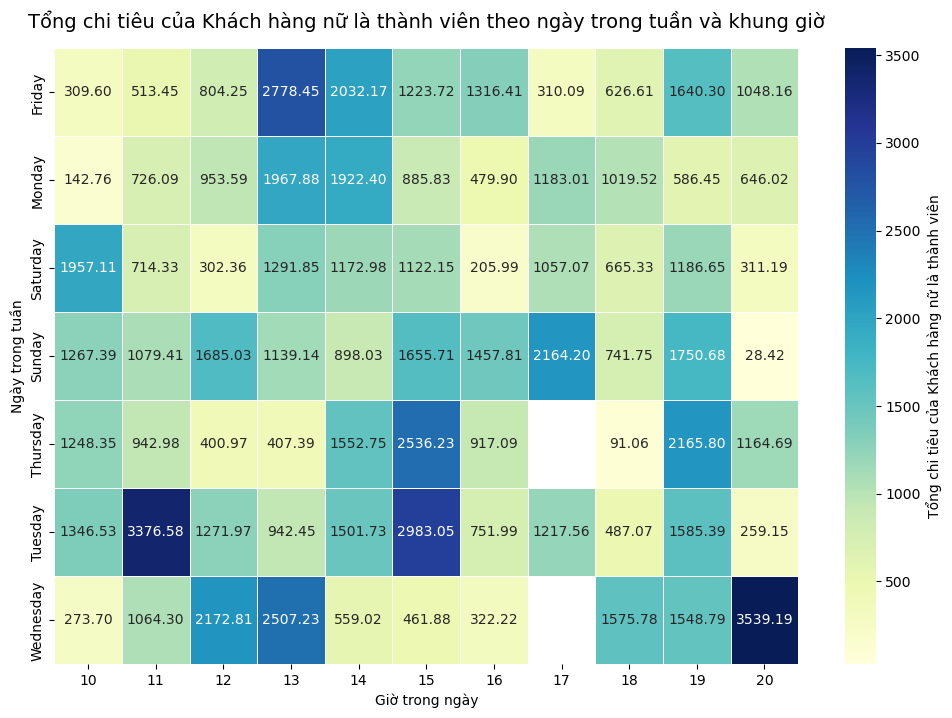

In [152]:
plot_spending_by_group(female_member_data, 'Khách hàng nữ là thành viên', "`Customer type` == 'Member'")

## Khách hàng nữ không là thành viên

In [153]:
# Khách hàng nam là thành viên chi tiêu nhiều nhất vào khung giờ nào trong ngày?
female_normal_data = supermarket_data_coppy[
    (supermarket_data_coppy['Customer type'] == 'Normal') &
    (supermarket_data_coppy['Gender'] == 'Female')
]

female_normal_data_summary = female_normal_data .groupby(['DayOfWeek', 'Hour']).agg(
    Total_Spent=('Total', 'sum'),
    Avg_Bill=('Total', 'mean'),
    Transaction_Count=('Total', 'count')
).reset_index()
female_normal_data_summary['DayOfWeek'] = pd.Categorical(female_normal_data_summary['DayOfWeek'], categories=days_order, ordered=True)
female_normal_data_summary = female_normal_data_summary.sort_values(['DayOfWeek', 'Hour'])
female_normal_data_summary

,DayOfWeek,Hour,Total_Spent,Avg_Bill,Transaction_Count
11,Monday,10,385.4025,96.350625,4
12,Monday,11,554.2950,554.295000,1
13,Monday,12,523.3725,523.372500,1
14,Monday,13,758.5830,379.291500,2
15,Monday,14,655.8930,327.946500,2
...,...,...,...,...,...
37,Sunday,15,109.8930,54.946500,2
38,Sunday,16,1178.0370,392.679000,3
39,Sunday,17,1949.6610,487.415250,4
40,Sunday,18,1415.0115,235.835250,6


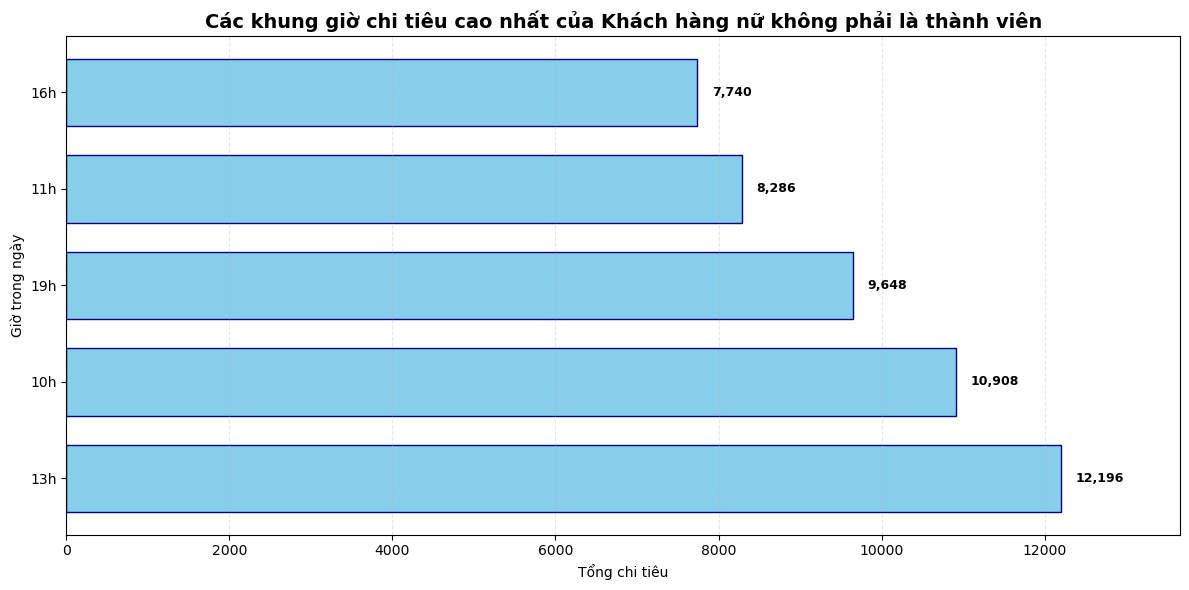

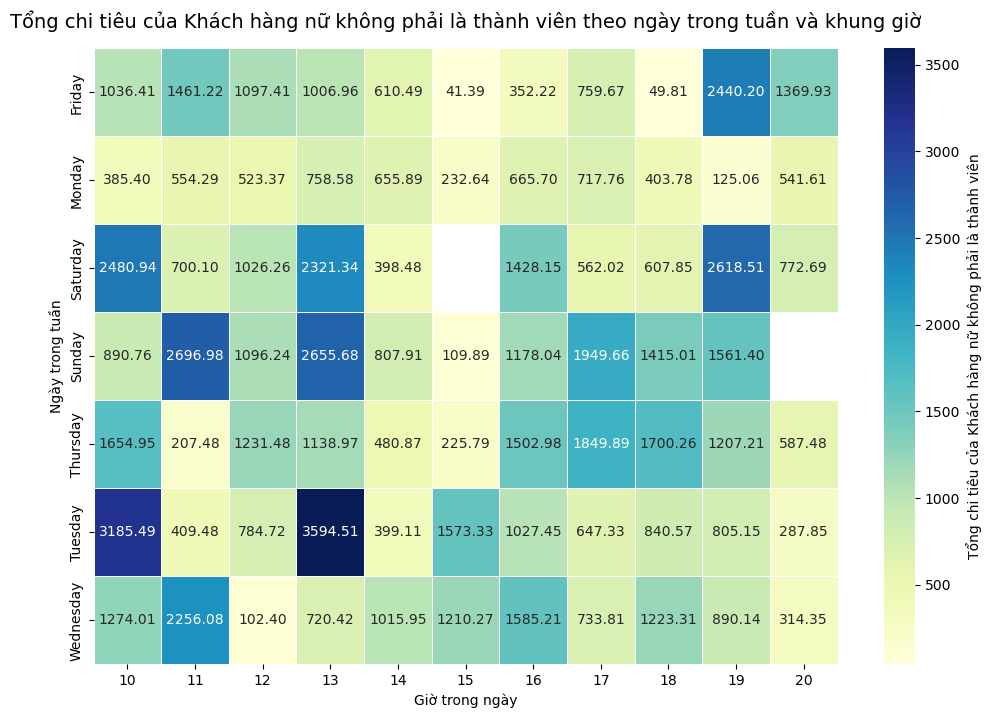

In [154]:
plot_spending_by_group(female_normal_data, 'Khách hàng nữ không phải là thành viên', "`Customer type` == 'Normal'")